# PLA-ChAT scientific analysis: measurements to biological follow-up

This notebook is a scientist-facing walkthrough of eight HALO Object Colocalization FL exports: four original box selections and four paired tissue-outline reruns for the same four named regions. The two runs are alternative analyses of the same material, not eight independent biological samples.

The notebook follows a measurement-to-inference sequence: define the observation unit, audit the exports, describe quantity and location, test robustness, and then decide what additional evidence is required for biological interpretation.

## Scientific workflow and interpretation boundary

1. **Define the observation unit.** Each row is one HALO-detected object, not a cell, animal, or independent replicate. PLA and ChAT rows remain separate populations.
2. **Audit the export.** Check schema, missing values, IDs, marker flags, coordinate bounds, overlap arithmetic, and the relationship between box and outline reruns.
3. **Describe the signal.** Report object counts, ChAT-associated PLA fractions, overlap distributions, size, intensity, and coordinate patterns with denominators visible.
4. **Test robustness.** Compare selection procedures, inspect low-support bins and geometry features, and examine area sensitivity without silently filtering rows.
5. **Separate evidence from interpretation.** These files support statements about detected objects and exported overlap. They do not establish tissue-normalized density, cell identity, direct protein binding, glycolytic function, or an age/disease effect.
6. **Choose the next action.** Use the action guide near the end to identify whether the next need is image review, ROI geometry, calibration, cell assignment, assay controls, or replicate-level analysis.

The spatial figures are object-coordinate reconstructions from bounding-box midpoints. They are not recovered microscopy images, tissue masks, or pixelwise fluorescence overlays.

## Research basis

The analysis design follows established guidance and methods: in situ PLA is proximity-assay evidence rather than automatic proof of binding ([Söderberg et al.](https://pubmed.ncbi.nlm.nih.gov/17072308/)); object-based spatial statistics depend on the observation window and boundary correction ([Lagache et al.](https://www.nature.com/articles/s41467-018-03053-x)); fluorescence microscopy results require acquisition and analysis provenance ([Montero Llopis et al.](https://www.nature.com/articles/s41592-021-01156-w)); object-level variation must be separated from biological replication ([Lord et al., SuperPlots](https://rupress.org/jcb/article/219/6/e202001064/151717/SuperPlots-Communicating-reproducibility-and)); and visual encodings should avoid misleading color boundaries ([Crameri et al.](https://www.nature.com/articles/s41467-020-19160-7)).

These sources support the workflow and reporting choices. They do not establish a biological effect in this dataset.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
REPO = next((p for p in [HERE, *HERE.parents] if (p / 'bio_visuals').is_dir() and (p / 'abstract.txt').is_file()), HERE)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from bio_visuals.data import load_data, summarize, quality_control, top_objects
from bio_visuals.plots import (setup_style, overview, ecdf_figures, overlap_composition, size_overlap, area_sensitivity, measurement_qc, area_concentration)
from bio_visuals.spatial import coordinate_overview, spatial_atlas, region_heatmap, bounding_box_zoom
from bio_visuals.reporting import save_figure, export_tables, write_run_metadata
from bio_visuals.comparison import comparison_summary, roi_summary_figure, paired_grid_data, paired_spatial_figure, exact_signature_comparison

setup_style()
print(f'Repository: {REPO}')

Repository: /Users/adambrewer/Desktop/Coding/Bio_Data_Analysis


In [2]:
DATA_ROOT = REPO
OUTPUT_ROOT = REPO / 'outputs' / 'scientific_notebook'
ROI_MODE = 'outline'
COUNT_BIN_WIDTH = 250
FRACTION_BIN_WIDTH = 1000
MIN_PLA_SUPPORT = 10
SPATIAL_SMOOTHING = 0
FOCUS_JOB = '5000' if ROI_MODE == 'outline' else '4595'
FOCUS_WINDOW = 150

objects, manifest = load_data(DATA_ROOT, roi_mode=ROI_MODE, verify_hashes=True)
print(f'Loaded {len(objects):,} objects from {len(manifest)} {ROI_MODE} exports')
display(manifest[['job', 'roi_mode', 'region', 'rows', 'sha256']])

Loaded 1,067,281 objects from 4 outline exports


,job,roi_mode,region,rows,sha256
0,4999,outline,22M_TDP43-Pfkp_tight,184684,9f77bd5d8f148edd95e8035445d2c22d46218ed9e5bc6f...
1,5000,outline,24M_TDP43-Pfkp_tight,295677,4a05d72249ab4b9f5a55ae90173078664f39fc8287c24f...
2,5001,outline,22M_TDP43-Hk1_tight,237144,2e4e329f0623bd2bb3407cf4a1cee8d28460d76308fe89...
3,5002,outline,24M_TDP43-Hk1_tight,349776,1ba6bbfc4ca4a37ac075783b31255795a0c2d6ebc708ca...


## 1. Measurement validity: audit before interpretation

The object type is the primary denominator decision. A PLA-present flag can occur on a ChAT row, so counting the flag alone mixes object populations.

Read the QC table as review gates: missing/nonfinite values, duplicate IDs, overlap-formula mismatches, and presence-flag mismatches should stop interpretation. Zero diameters, zero-span boxes, and nonzero inner areas are retained review features, not automatic errors. A passed audit means the table is structurally coherent; it does not prove correct staining or segmentation.

**Action:** if structural checks fail, stop and inspect the export. If geometry features are nonzero, review representative objects against the original image and HALO settings before selecting a filter.

In [3]:
summary = summarize(objects)
qc = quality_control(objects)
pla_summary = summary[summary.object_type == 'PLA'].copy()
display(pla_summary[['job', 'region', 'n_objects', 'other_marker_count', 'other_marker_pct', 'mean_object_overlap_pct', 'area_weighted_overlap_pct']])
display(qc[['job', 'n_objects', 'overlap_pct_formula_mismatch', 'overlap_presence_mismatch', 'any_zero_diameter', 'zero_bbox_width_or_height']])

,job,region,n_objects,other_marker_count,other_marker_pct,mean_object_overlap_pct,area_weighted_overlap_pct
1,4999,22M_TDP43-Pfkp_tight,8412,4893,58.166904,44.528091,44.183562
3,5000,24M_TDP43-Pfkp_tight,7733,5470,70.735808,57.399379,50.671891
5,5001,22M_TDP43-Hk1_tight,14984,6402,42.725574,30.859149,37.408429
7,5002,24M_TDP43-Hk1_tight,41237,22710,55.071901,44.974086,43.153573


,job,n_objects,overlap_pct_formula_mismatch,overlap_presence_mismatch,any_zero_diameter,zero_bbox_width_or_height
0,4999,184684,0,0,2291,2136
1,5000,295677,0,0,2360,1926
2,5001,237144,0,0,4143,4007
3,5002,349776,0,0,13493,12222


## 2. Selection robustness: box versus tissue outline

This is a paired reanalysis of the same four regions. All deltas are **outline minus box**. Count changes are relative changes from the box count; overlap changes are percentage-point differences. They are not the same unit and are not biological effects.

The outline rerun is useful because a rectangle can include non-tissue space, but these CSVs still do not contain the polygon, binary tissue mask, or measured tissue area. Therefore this comparison tests sensitivity to exported selection, not tissue-normalized enrichment.

**Action:** conclusions that persist in both modes are more robust to this selection change. Mode-sensitive patterns should trigger image review, ROI export, or a prespecified tissue-area analysis.

,pair_id,box_job,outline_job,object_type,box_count,outline_count,count_delta,count_delta_pct,box_association,outline_association,...,mean_overlap_delta,box_weighted_overlap,outline_weighted_overlap,weighted_overlap_delta,box_median_area,outline_median_area,median_area_delta,box_median_intensity,outline_median_intensity,median_intensity_delta
0,22M_Pfkp-TDP43,4594,4999,PLA,9112,8412,-700,-7.682177,59.043020,58.166904,...,-1.735201,43.077723,44.183562,1.105839,0.094080,0.100352,0.006272,0.056515,0.056675,0.000159
2,24M_Pfkp-TDP43,4595,5000,PLA,7999,7733,-266,-3.325416,68.908614,70.735808,...,1.561244,45.243235,50.671891,5.428655,0.112896,0.109760,-0.003136,0.057180,0.057133,-0.000047
4,22M_Hk1-TDP43,4596,5001,PLA,15282,14984,-298,-1.950007,42.435545,42.725574,...,0.215107,38.020494,37.408429,-0.612065,0.090944,0.090944,0.000000,0.056352,0.056313,-0.000039
6,24M_Hk1-TDP43,4597,5002,PLA,43918,41237,-2681,-6.104558,55.455622,55.071901,...,-0.176599,43.509257,43.153573,-0.355685,0.062720,0.065856,0.003136,0.055385,0.055401,0.000016


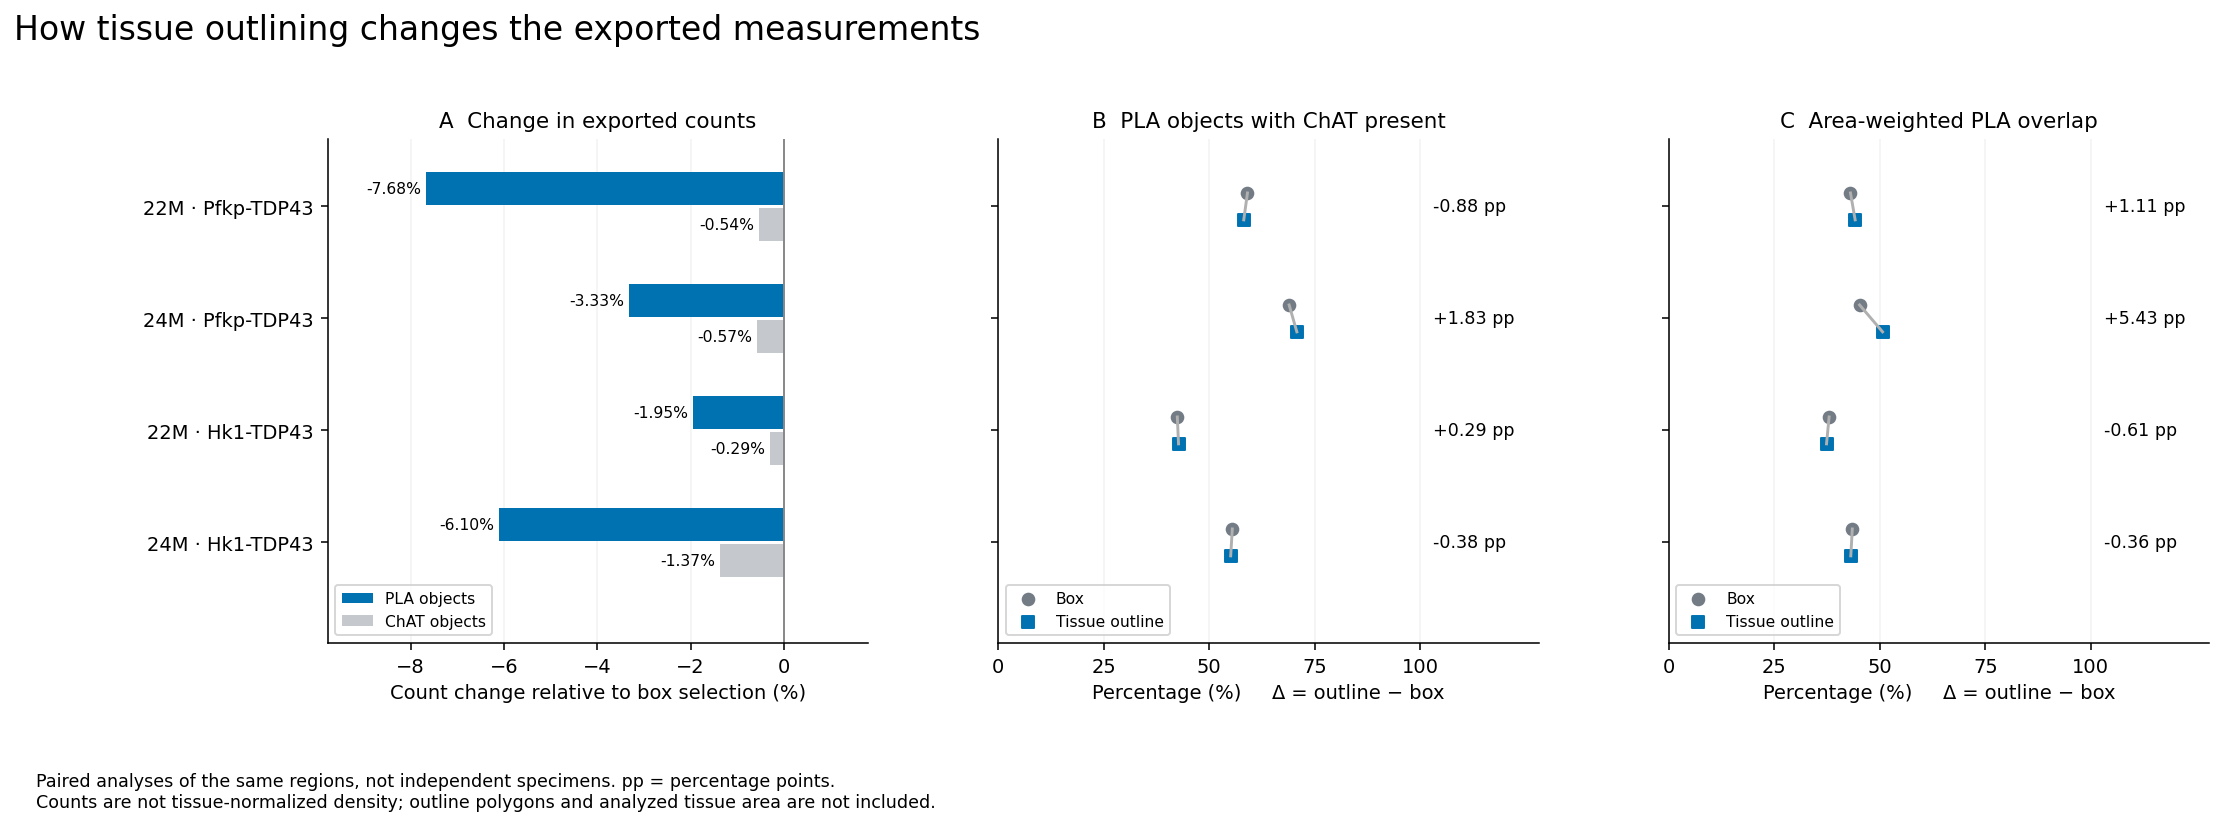

[PosixPath('/Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/scientific_notebook/roi_comparison/figures/01_box_vs_outline_summary.png'),
 PosixPath('/Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/scientific_notebook/roi_comparison/figures/01_box_vs_outline_summary.pdf')]

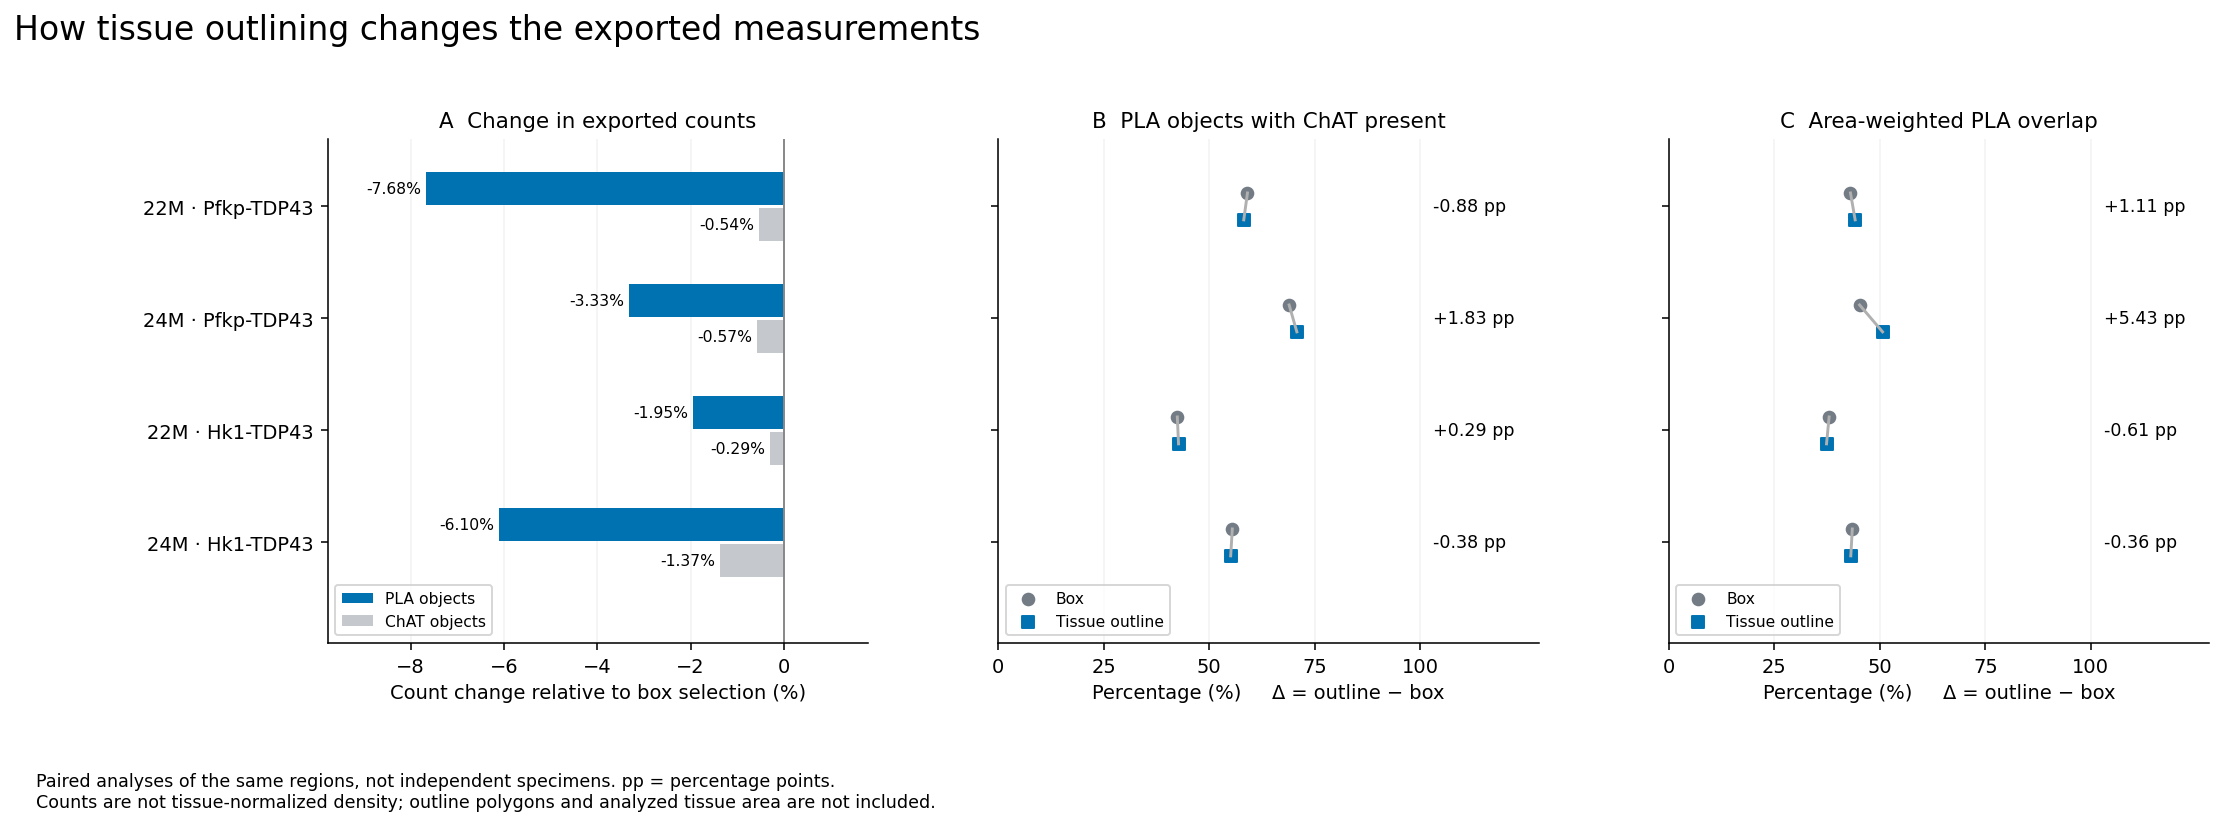

In [4]:
all_objects, all_manifest = load_data(DATA_ROOT, roi_mode='all', verify_hashes=True)
comparison_table = comparison_summary(all_objects)
display(comparison_table[comparison_table.object_type == 'PLA'])
fig_roi, roi_table = roi_summary_figure(all_objects)
display(fig_roi)
save_figure(fig_roi, '01_box_vs_outline_summary', OUTPUT_ROOT / 'roi_comparison')

### Where do the two selections differ?

Paired spatial maps use identical coordinate bins and shared count scales. Blue difference bins have fewer outline detections; red bins have more. These maps locate selection-sensitive measurements, not an inferred tissue boundary. A zero net change does not prove the same objects were detected because IDs restart and no cross-run object correspondence is available.

**Action:** prioritize large positive/negative difference bins, suspected boundaries, and fields with changed overlap summaries for image review. Request the original annotation polygon or mask before calculating objects per area or applying boundary-corrected spatial inference.

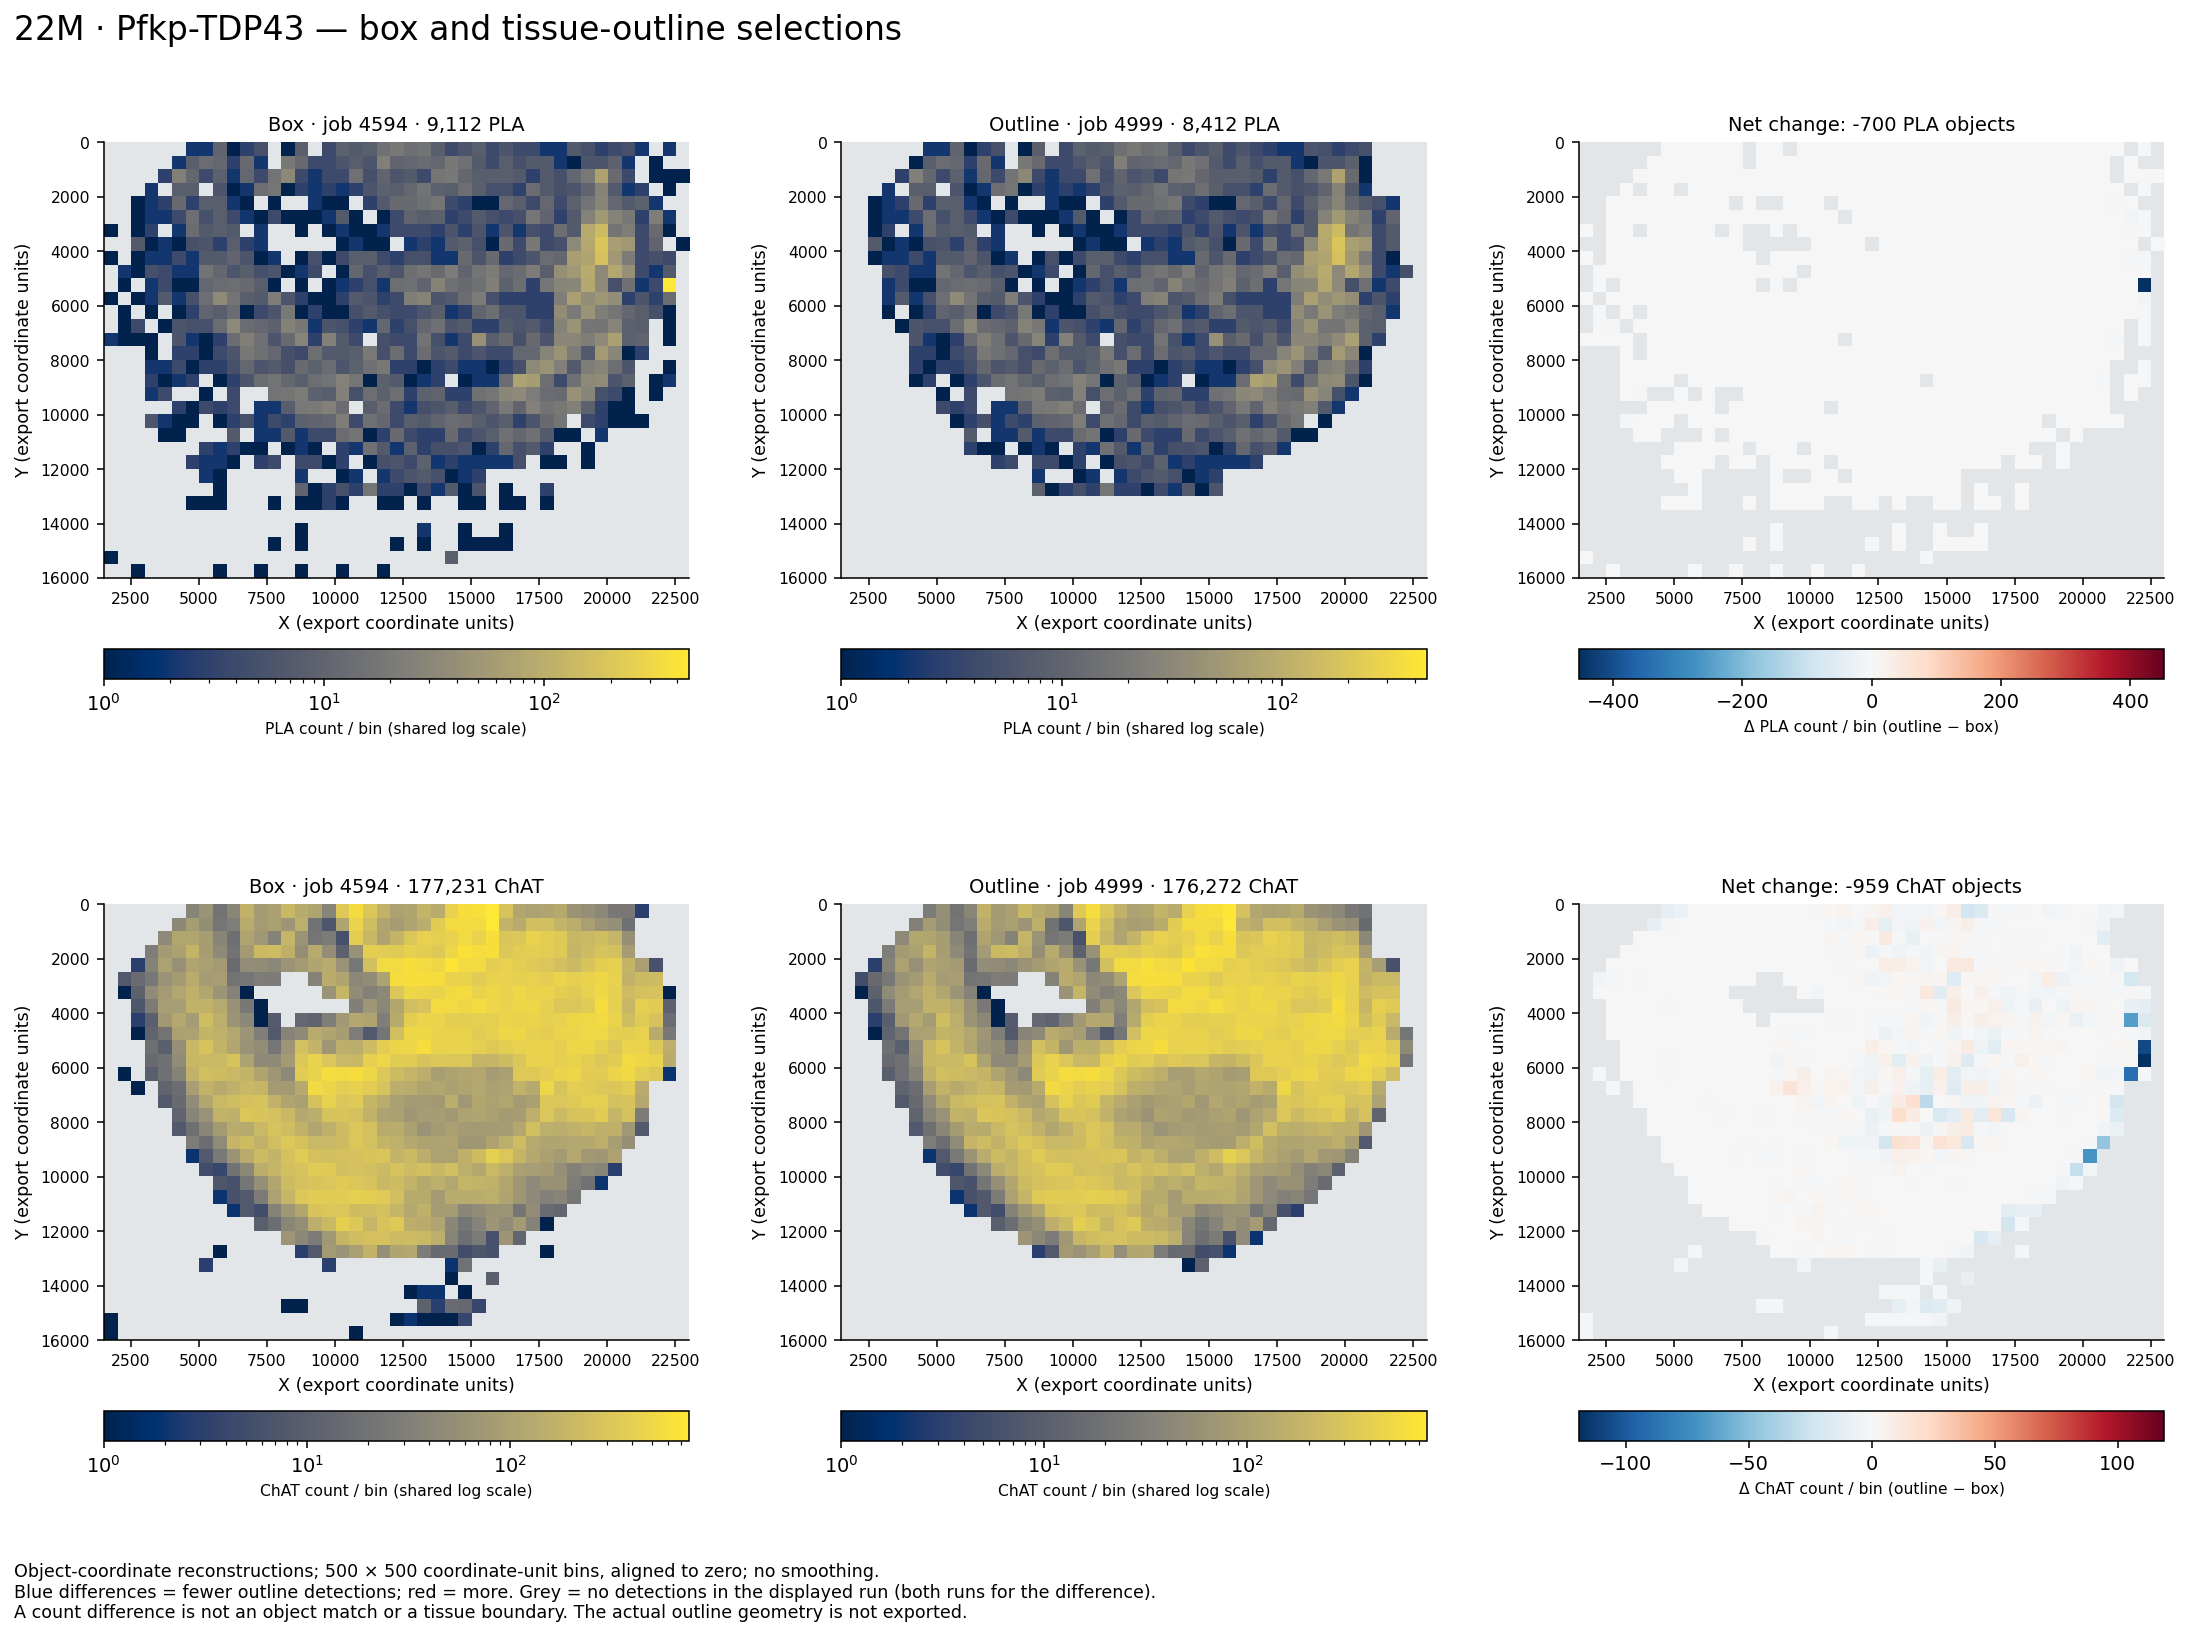

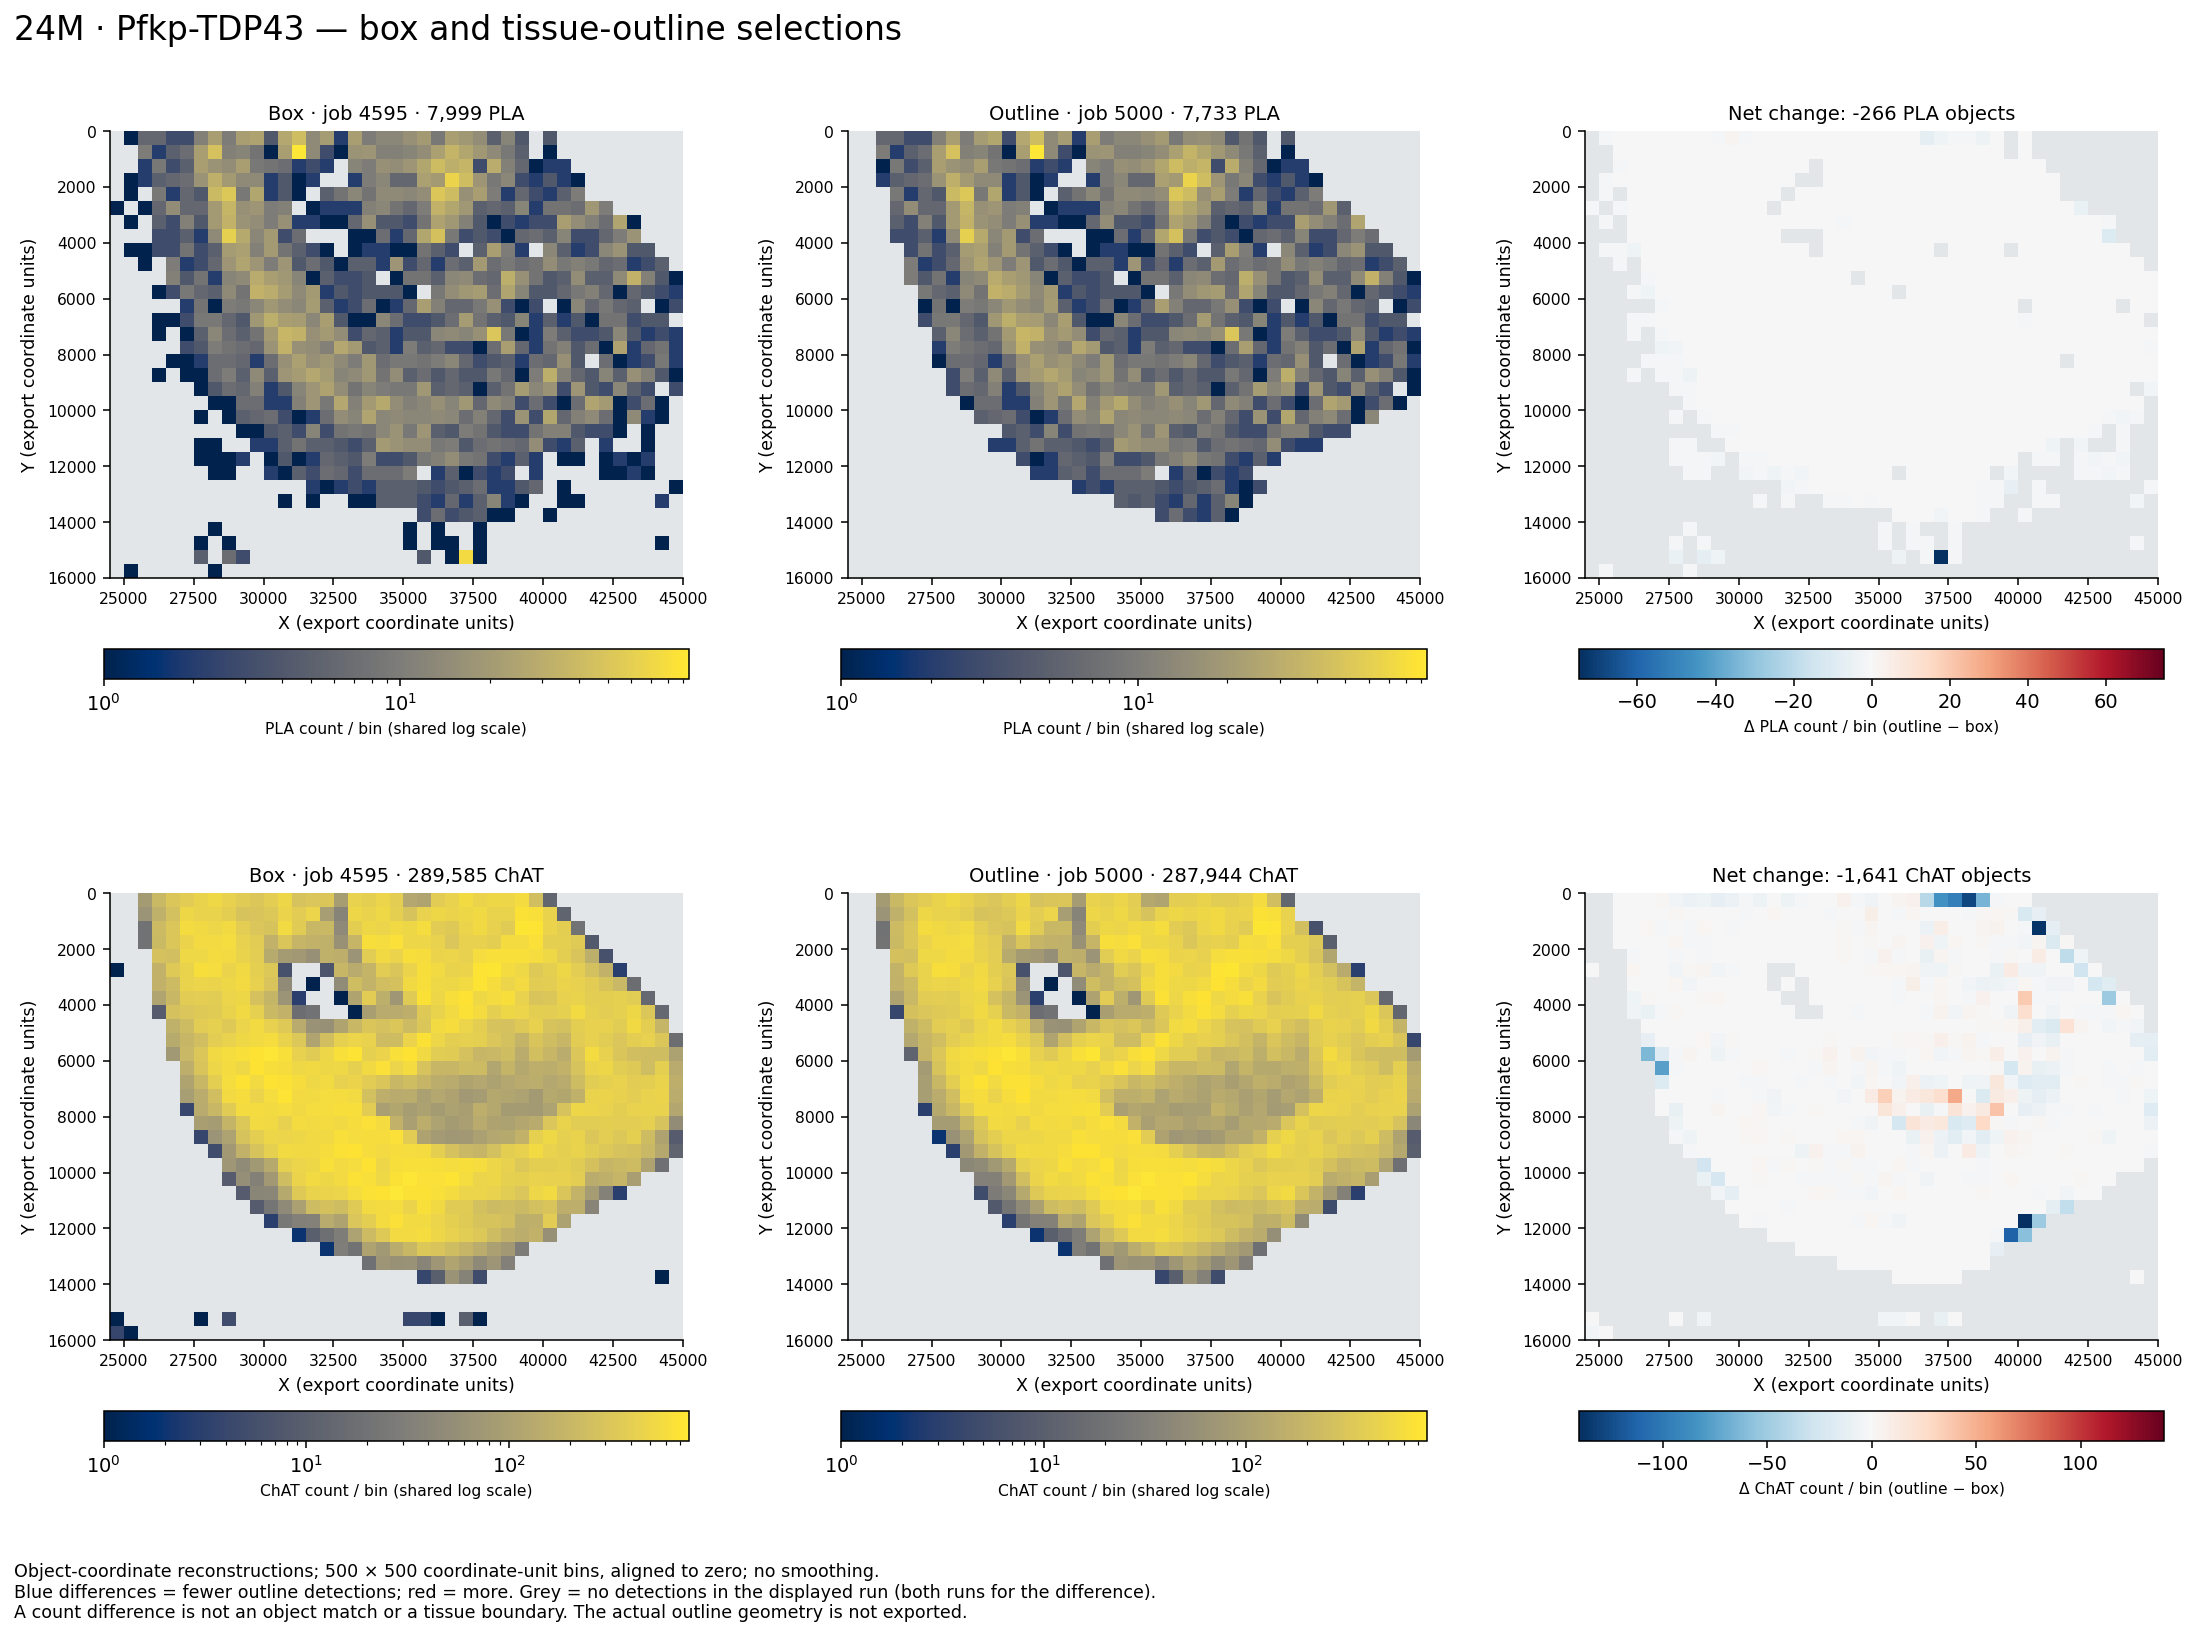

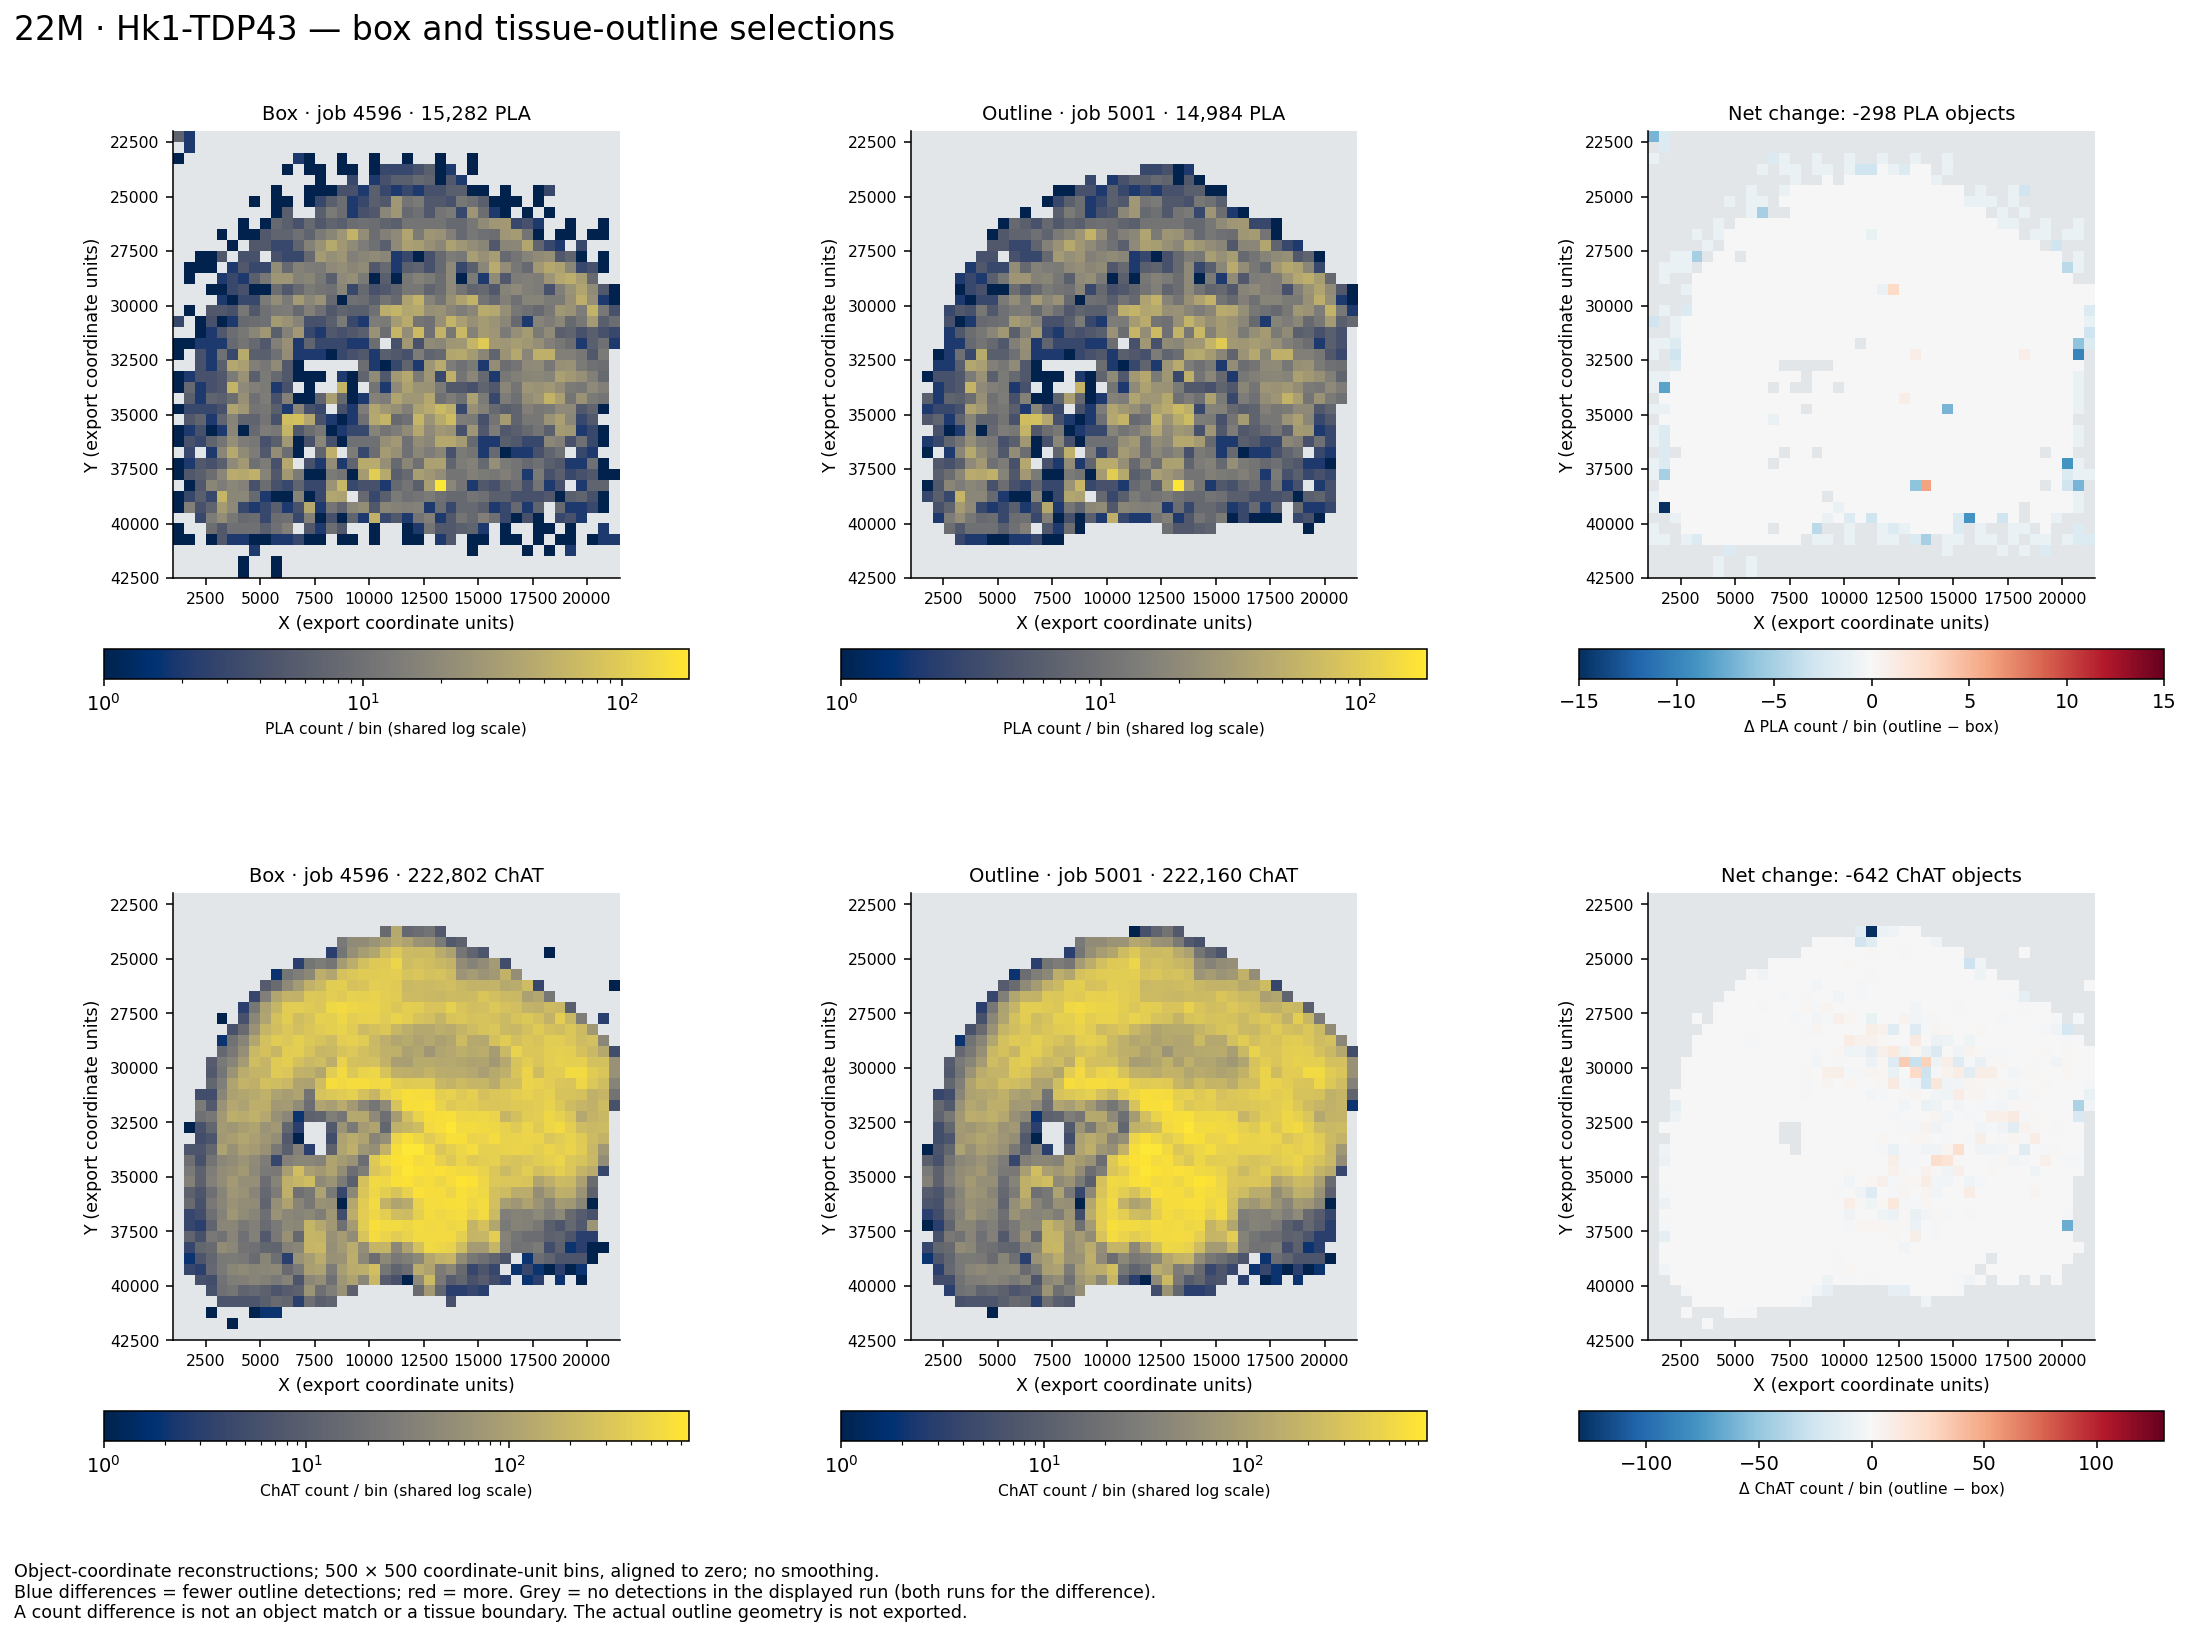

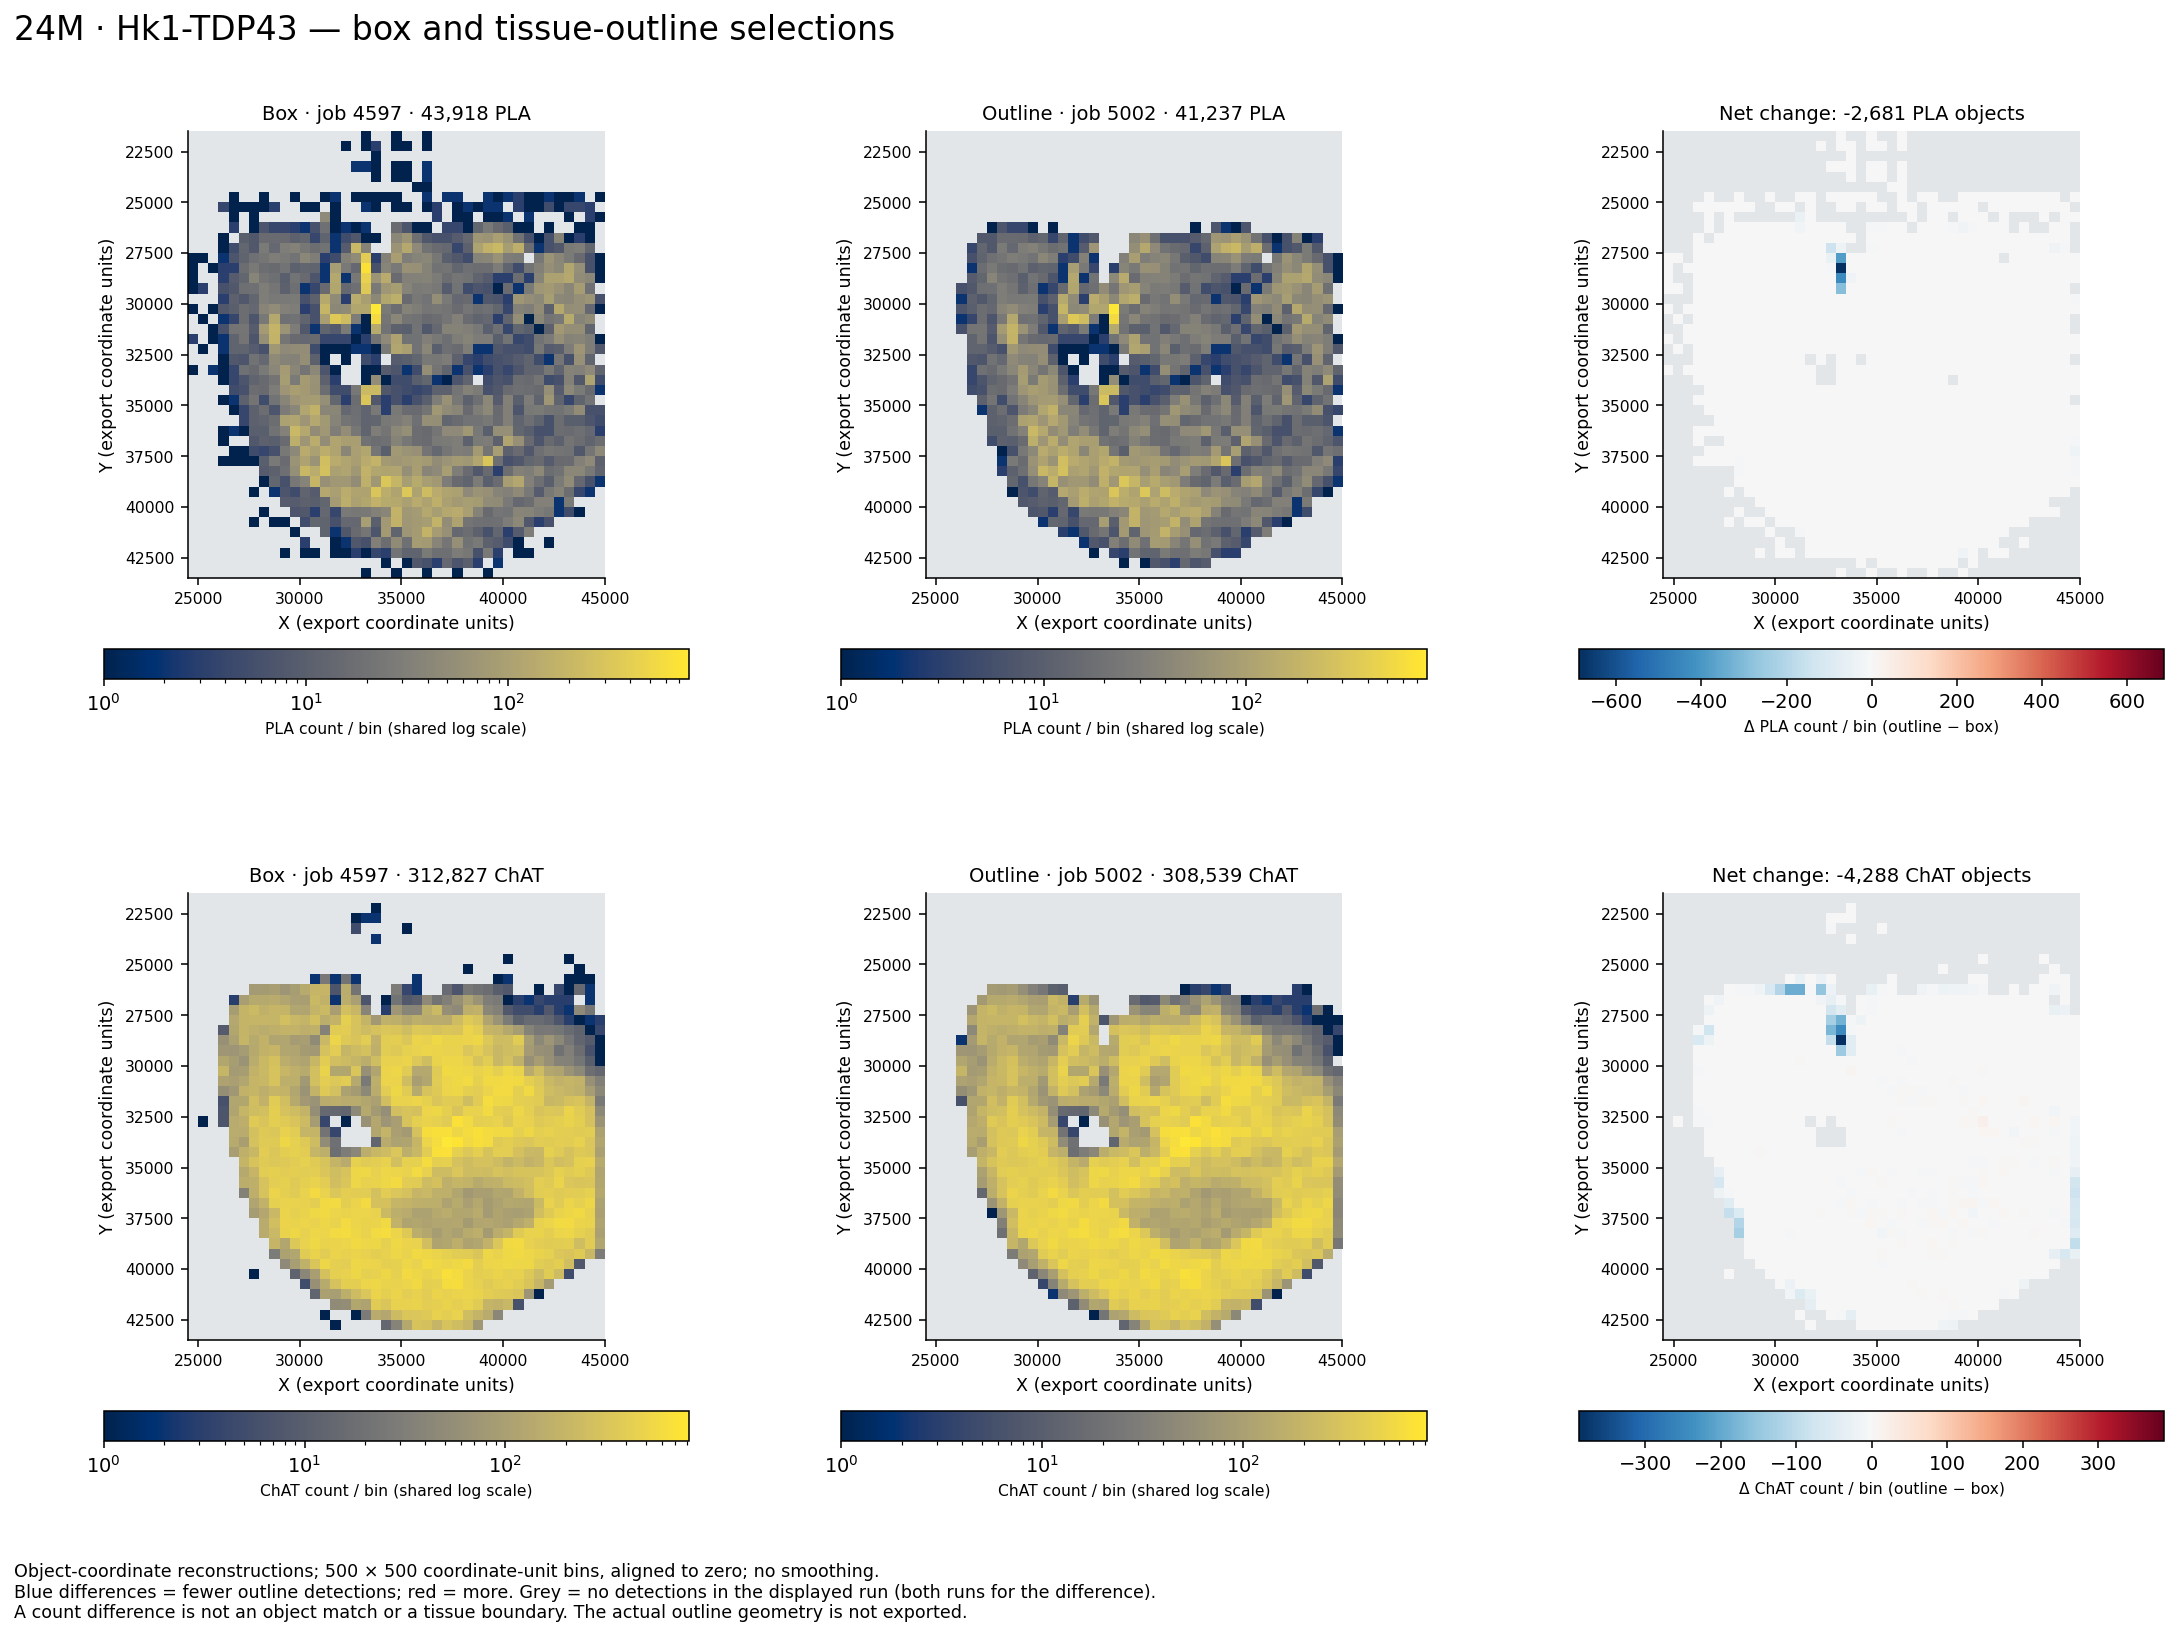

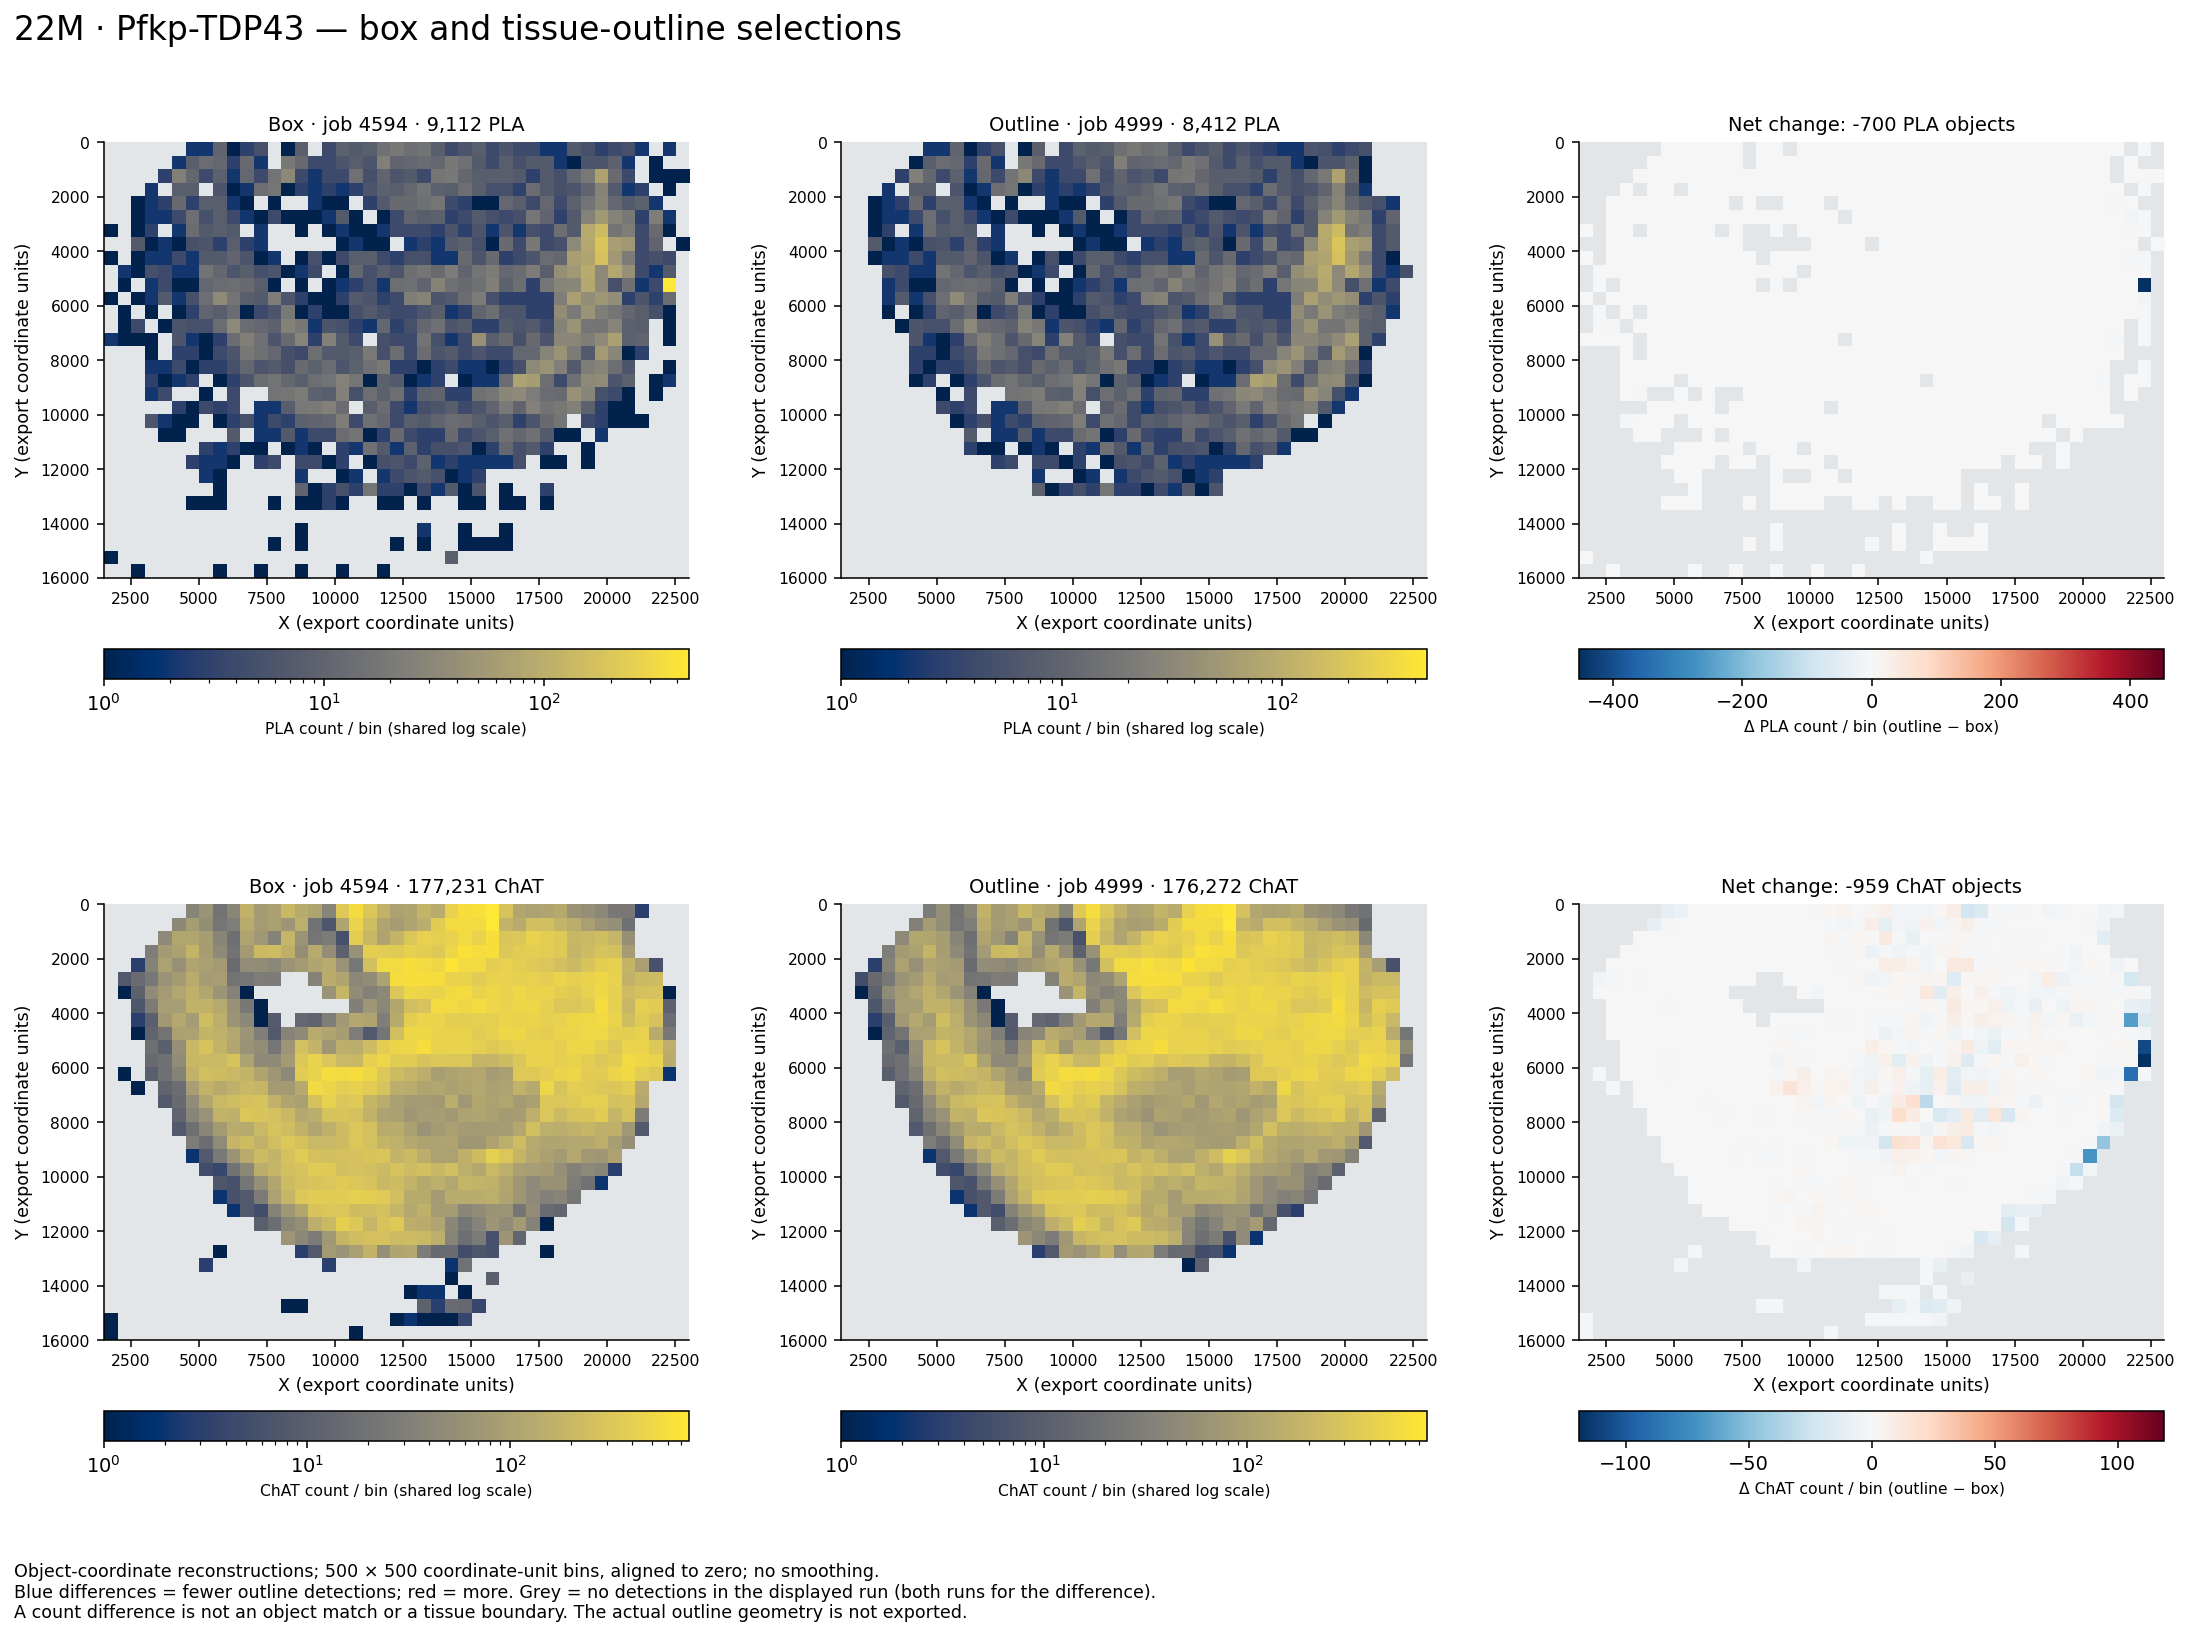

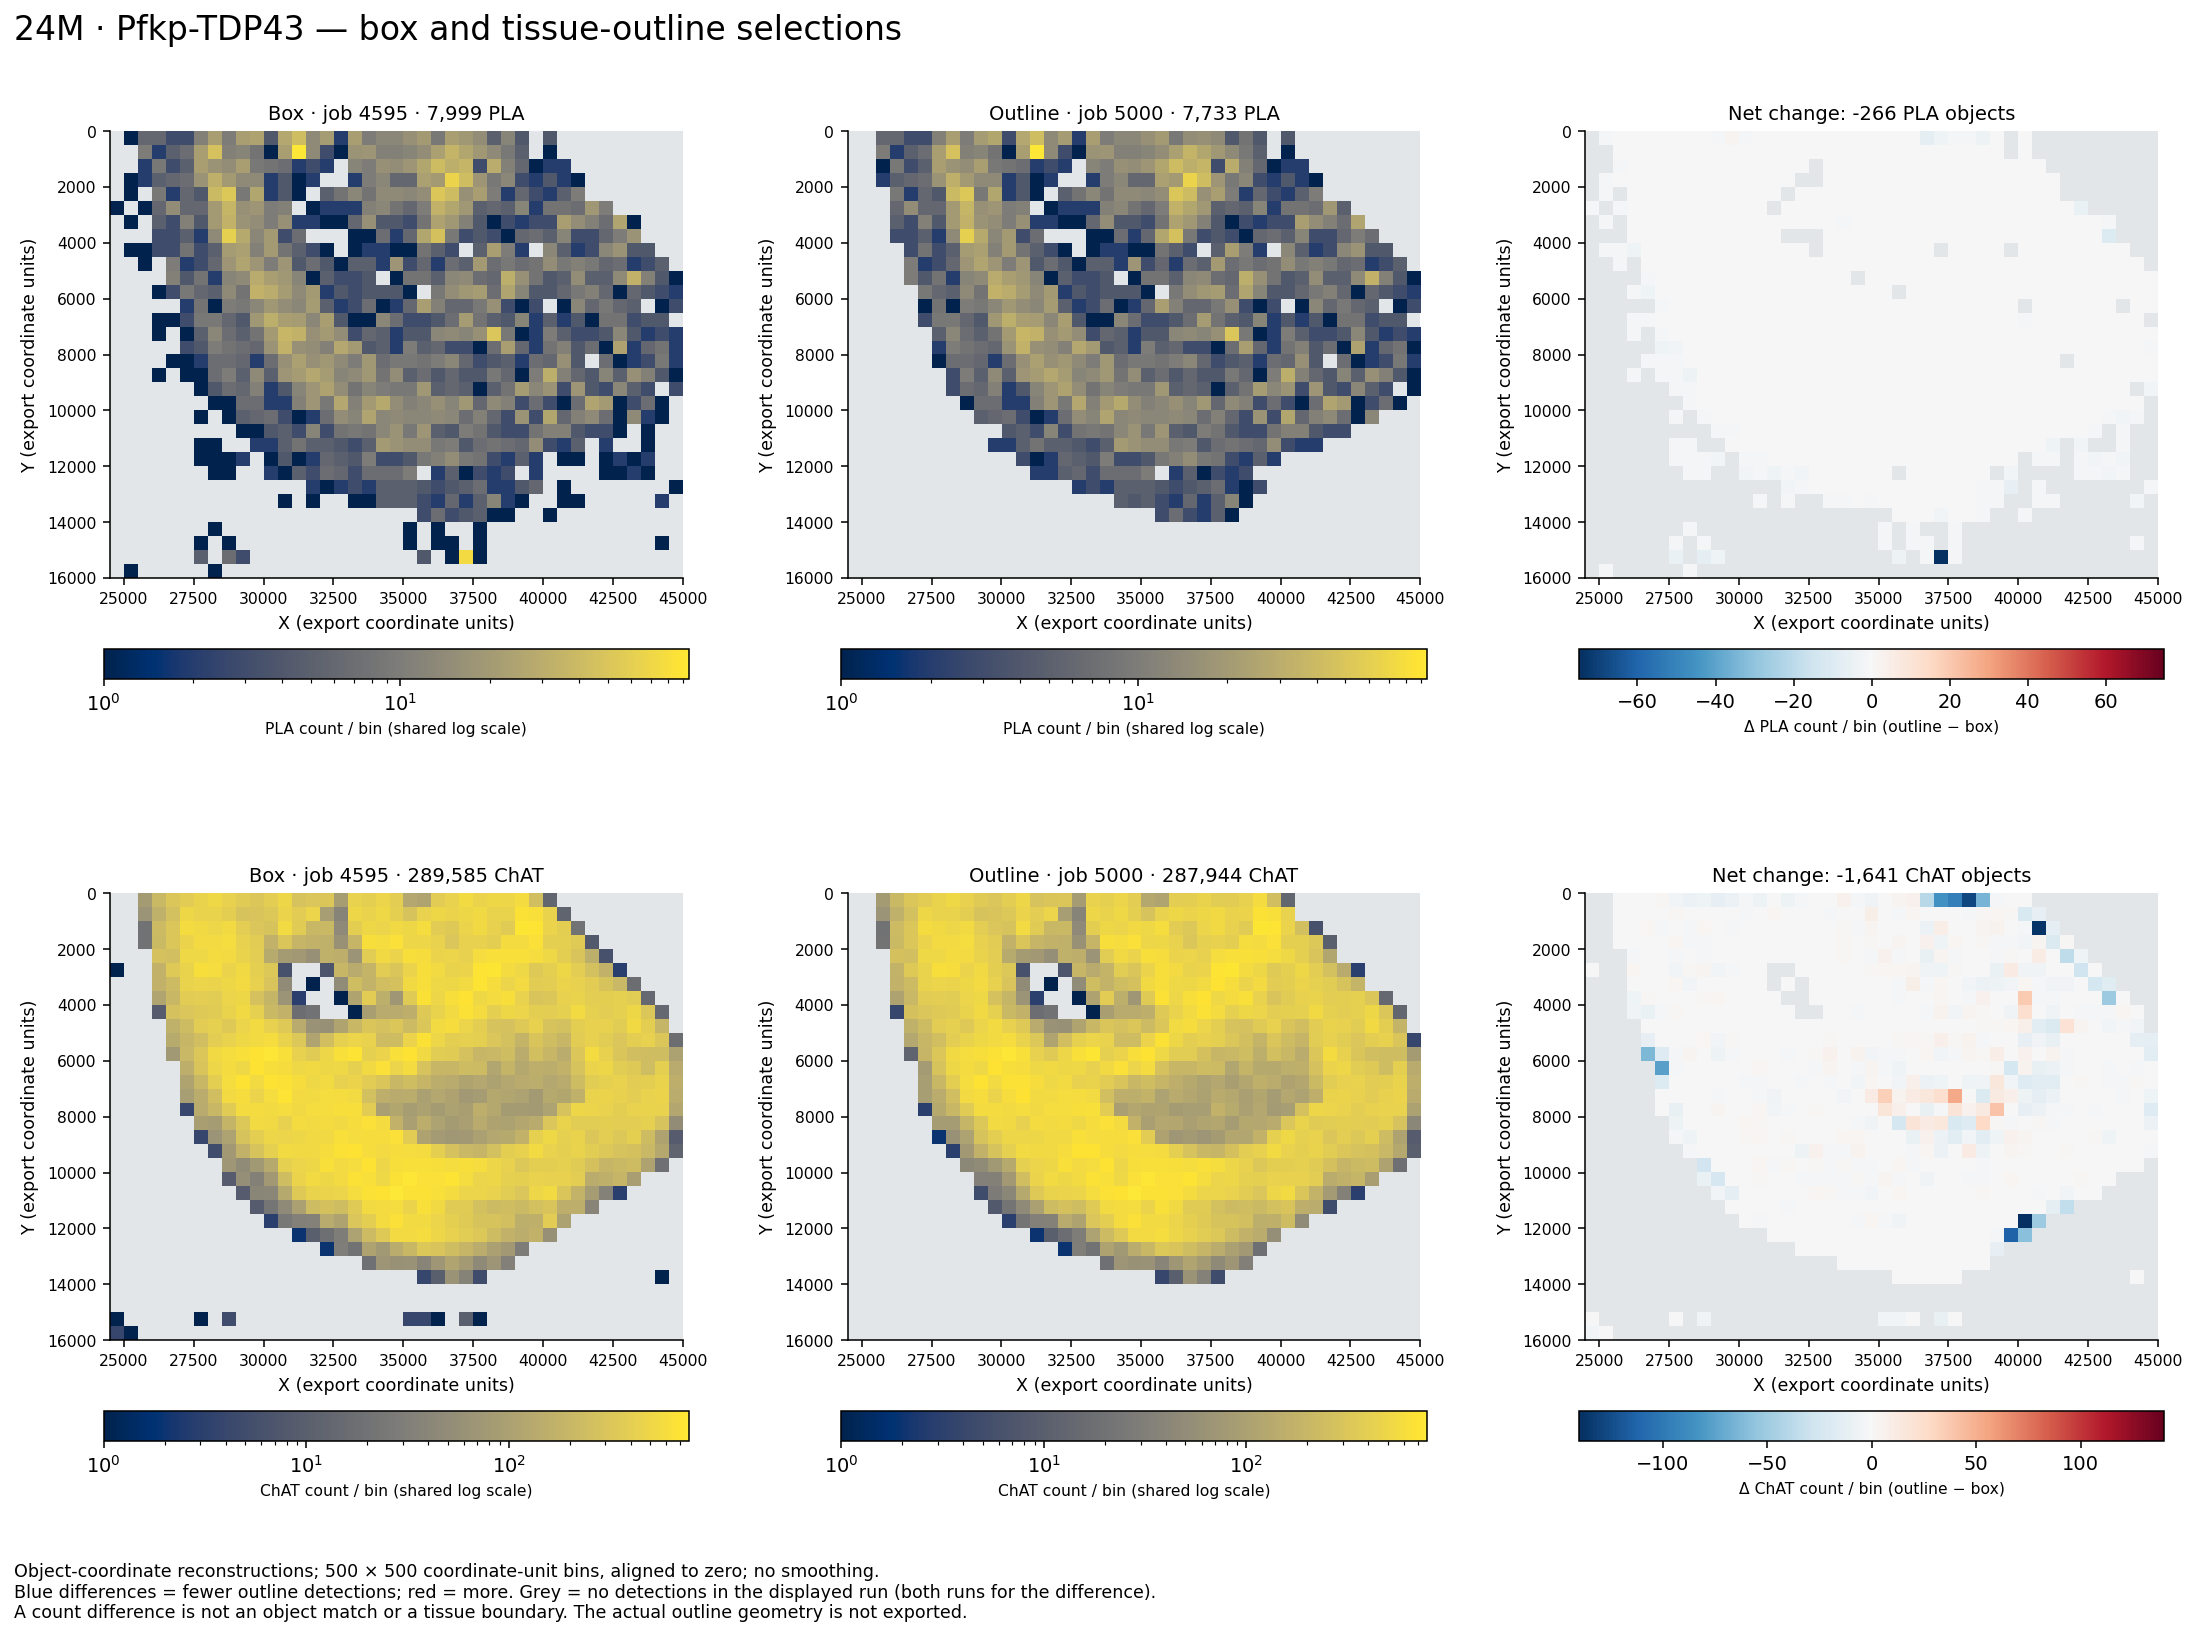

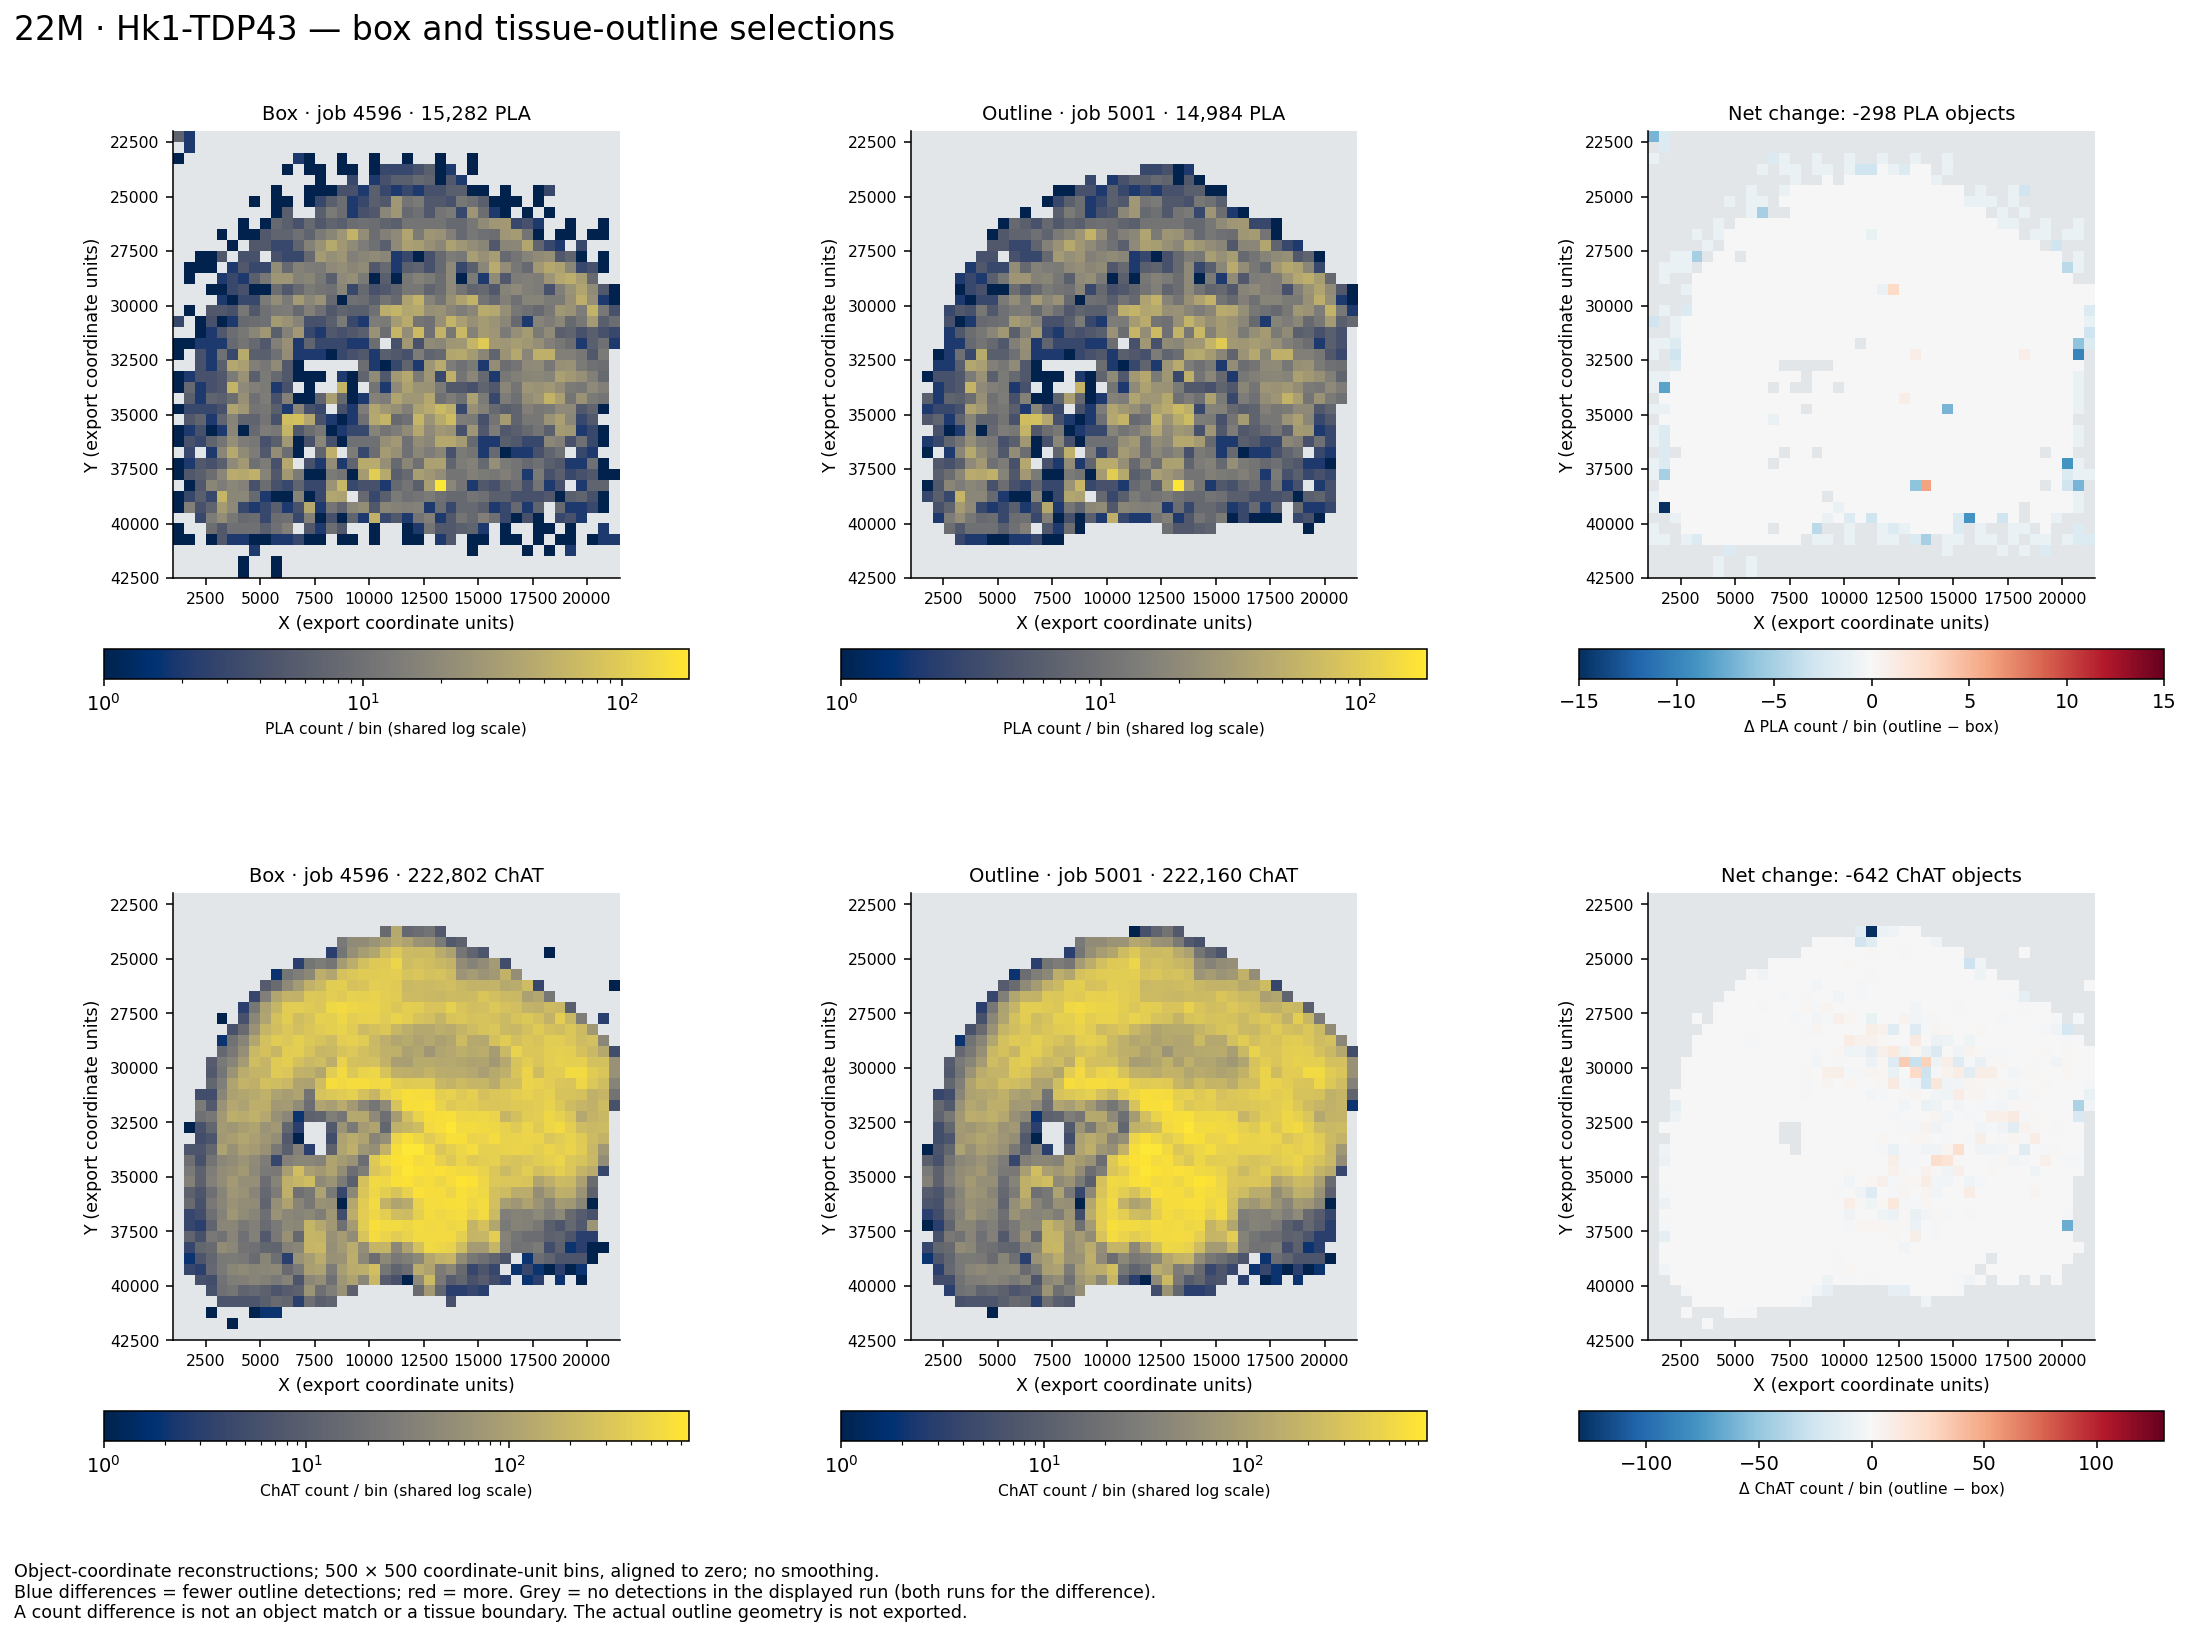

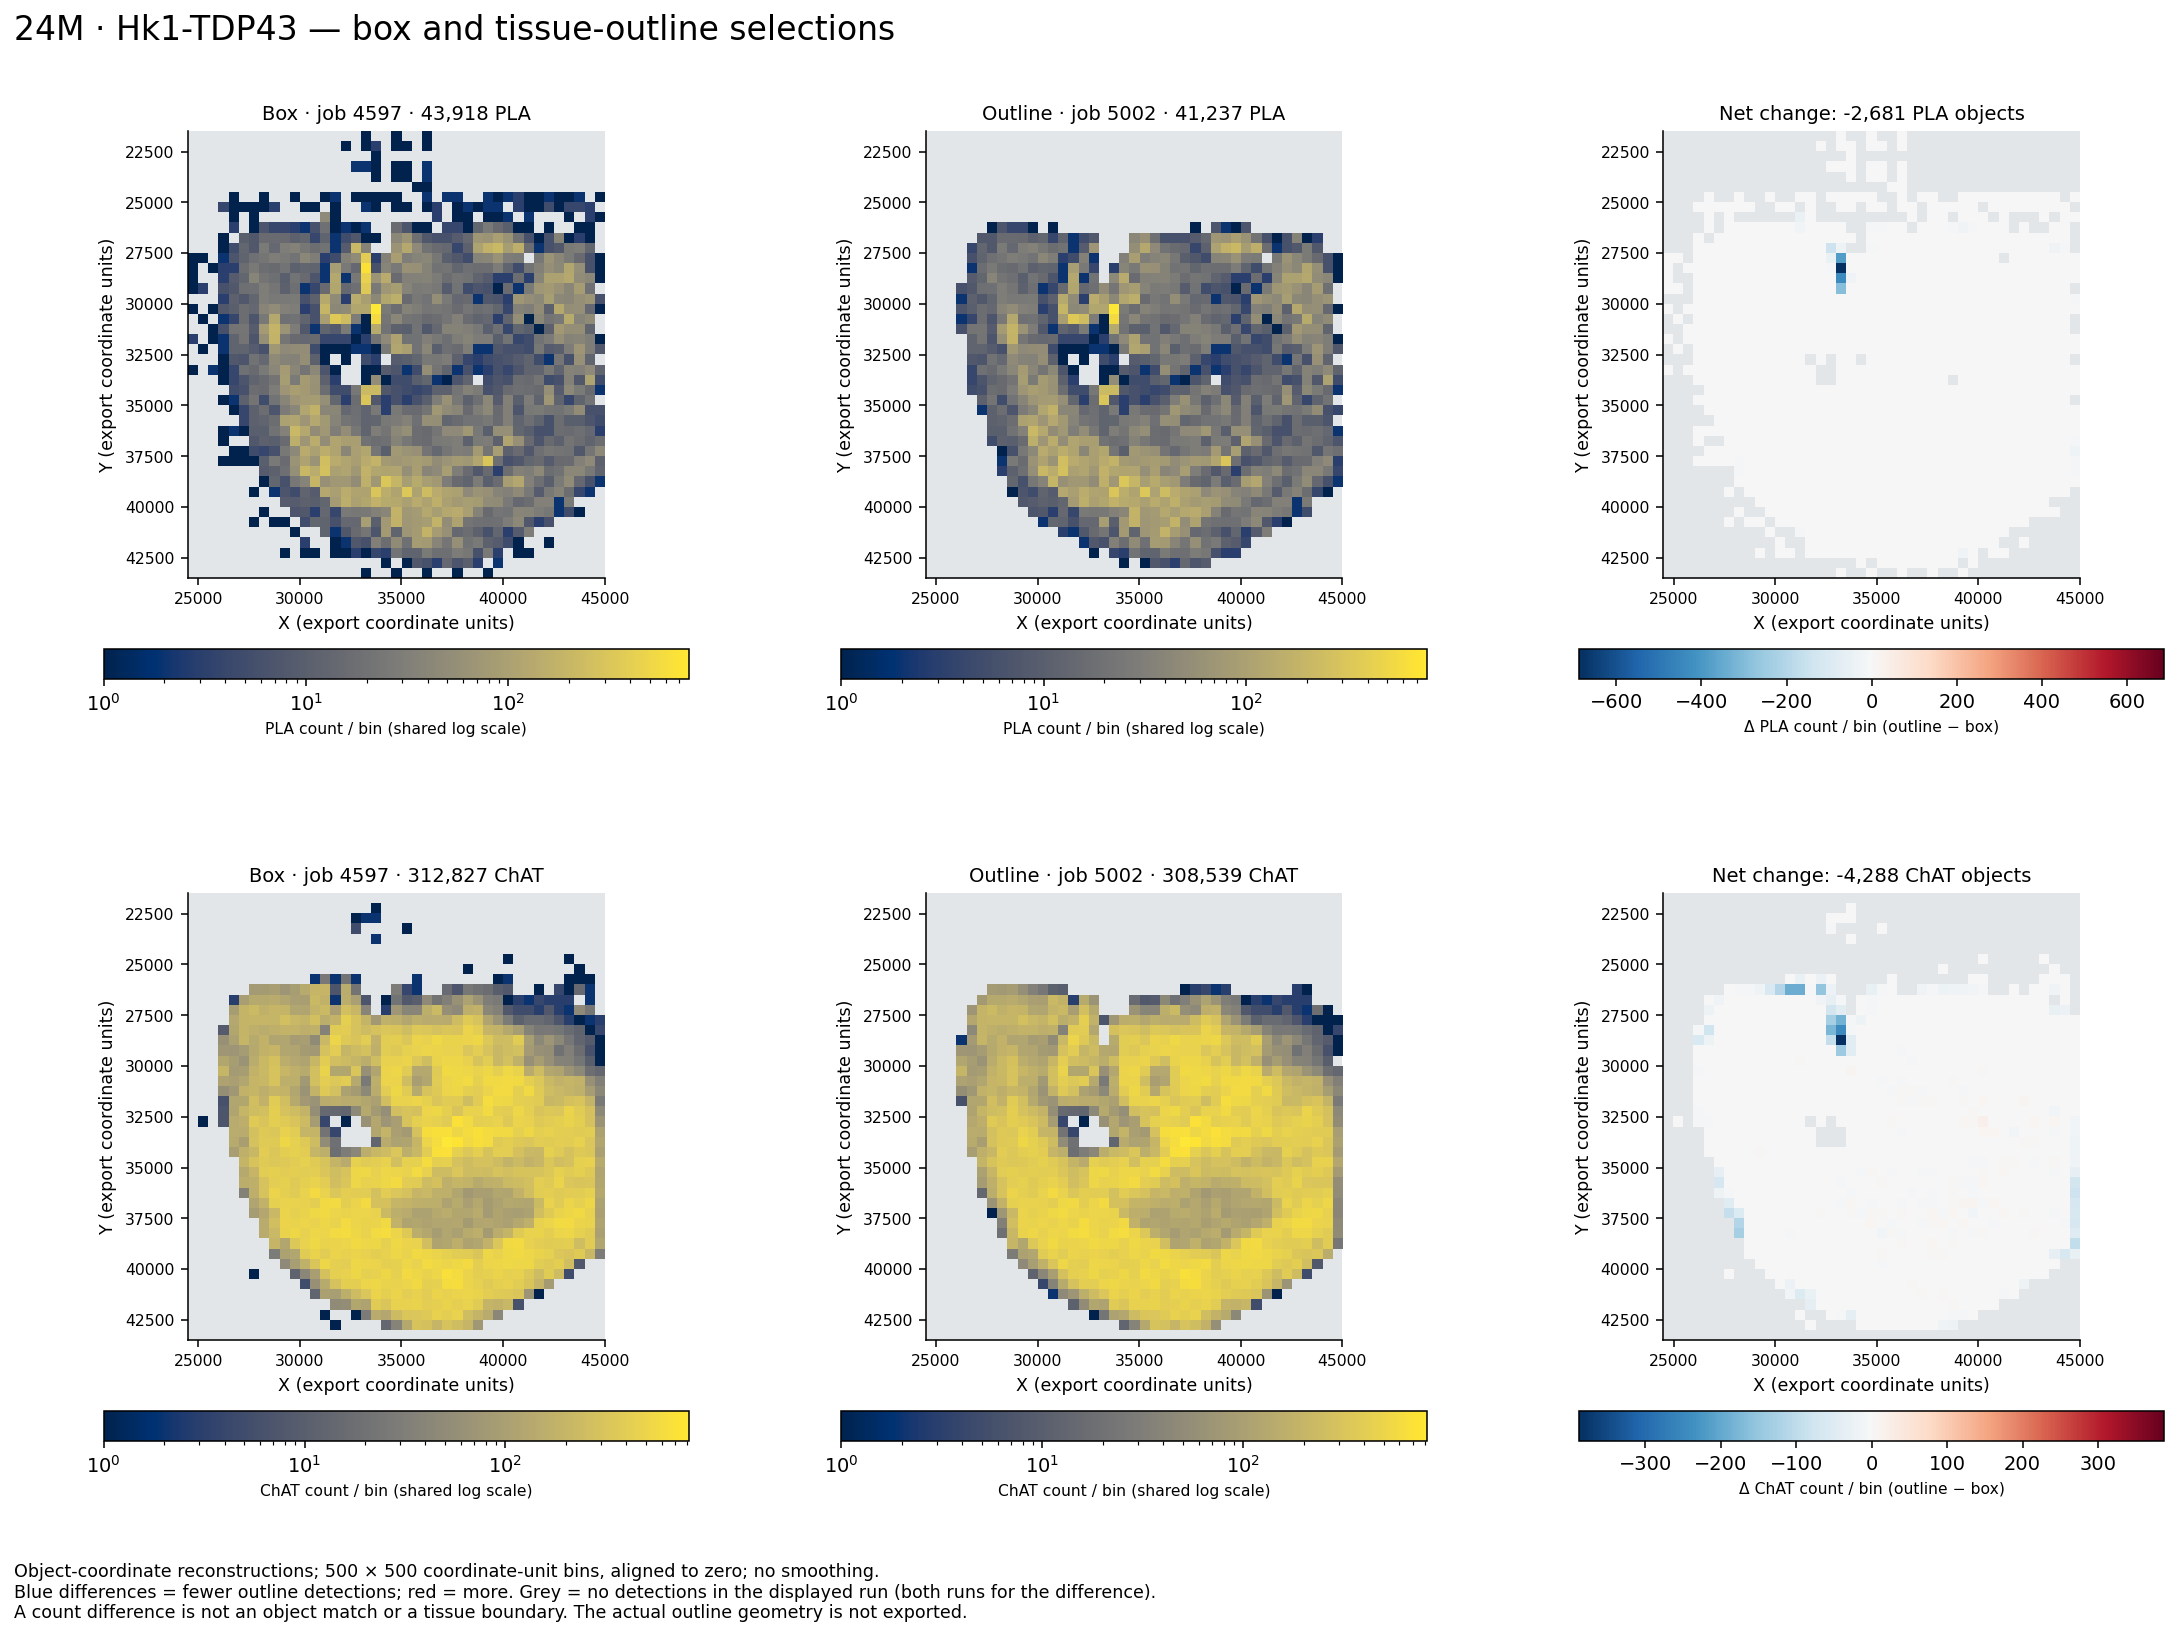

In [5]:
paired_grid = paired_grid_data(all_objects, bin_width=500)
for pair_id in paired_grid.pair_id.unique():
    fig_pair = paired_spatial_figure(paired_grid, pair_id)
    display(fig_pair)
    save_figure(fig_pair, f'02_paired_spatial_{pair_id}', OUTPUT_ROOT / 'roi_comparison')

## 3. Quantity: counts and three overlap denominators

The overview answers how many objects were exported and why the denominator changes the conclusion. For PLA objects, report: (1) the fraction with ChAT present, (2) mean object overlap, and (3) area-weighted overlap. These are complementary summaries, not interchangeable colocalization measures.

**Current interpretation:** regional descriptive differences are visible in the exports. They do not establish that one target pair binds more strongly, that a 22M/24M label is an age effect, or that the result replicates across animals. Inspect distributions and selection comparisons before proposing a biological mechanism.

,job,region,label,pla_objects,chat_objects,pla_with_chat,pla_without_chat,pla_object_fraction_pct,pla_mean_overlap_pct,pla_area_weighted_overlap_pct
0,4999,22M_TDP43-Pfkp_tight,22M · Pfkp-TDP43,8412,176272,4893,3519,58.166904,44.528091,44.183562
1,5000,24M_TDP43-Pfkp_tight,24M · Pfkp-TDP43,7733,287944,5470,2263,70.735808,57.399379,50.671891
2,5001,22M_TDP43-Hk1_tight,22M · Hk1-TDP43,14984,222160,6402,8582,42.725574,30.859149,37.408429
3,5002,24M_TDP43-Hk1_tight,24M · Hk1-TDP43,41237,308539,22710,18527,55.071901,44.974086,43.153573


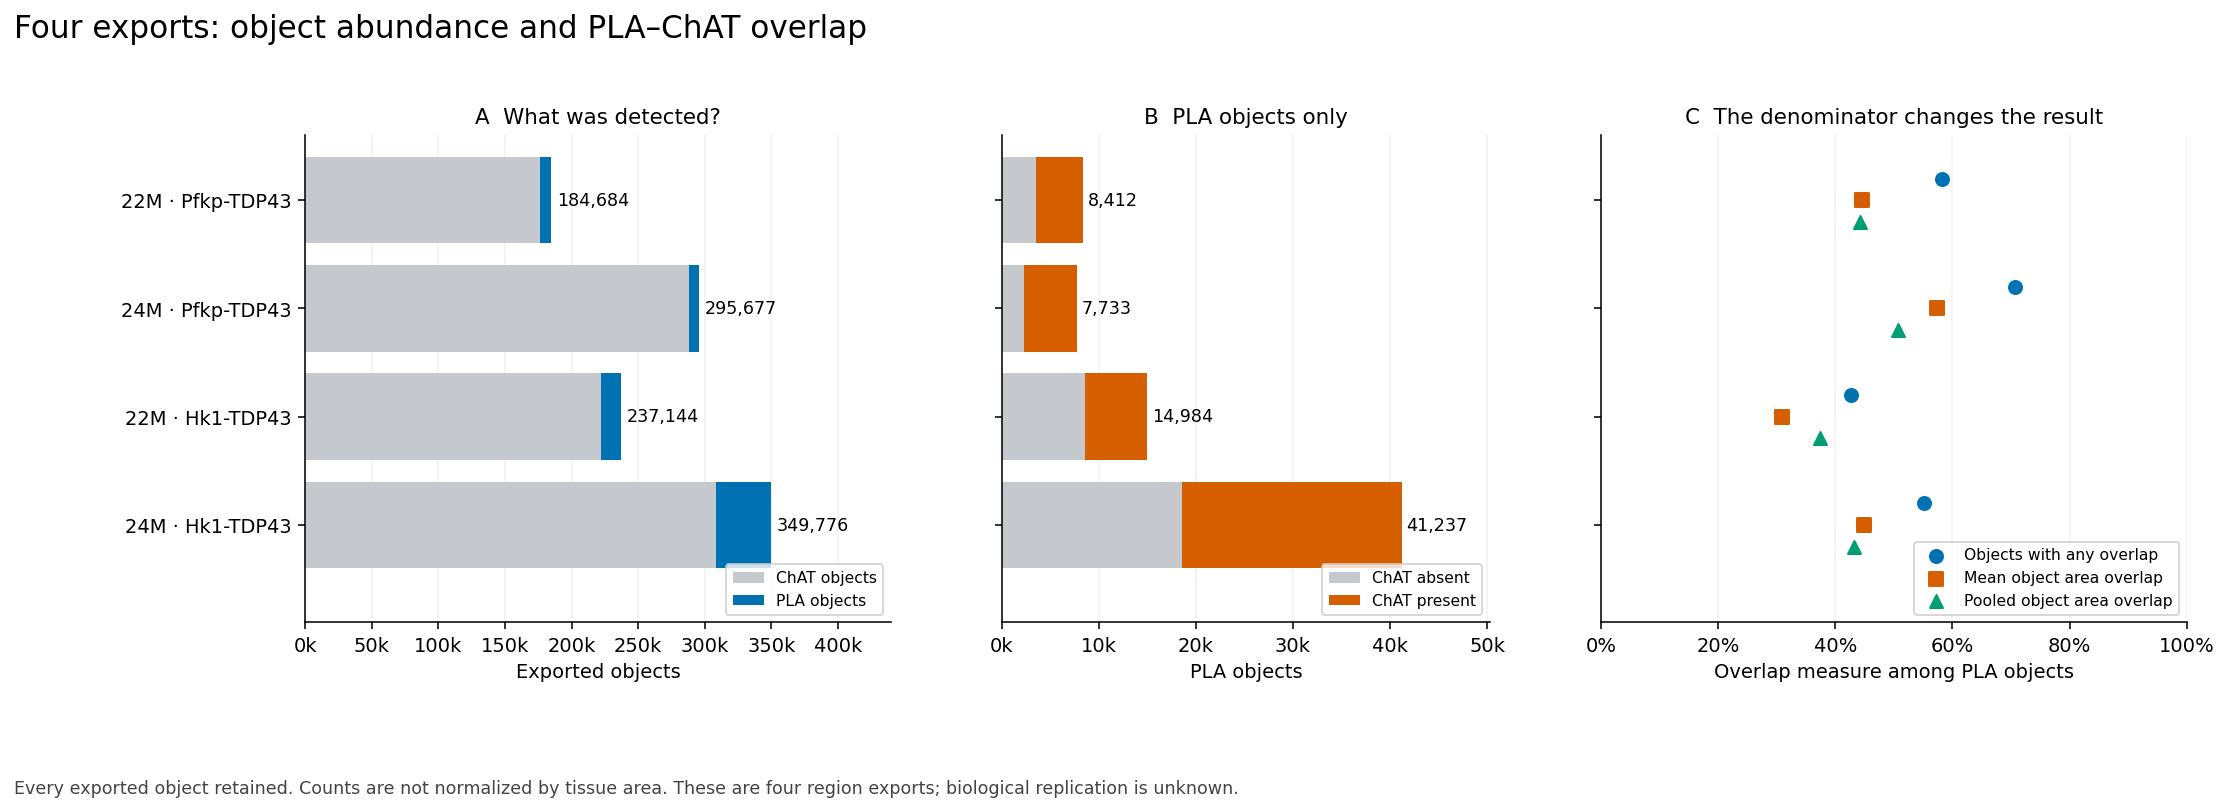

[PosixPath('/Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/scientific_notebook/outline/figures/03_overview_denominators.png'),
 PosixPath('/Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/scientific_notebook/outline/figures/03_overview_denominators.pdf')]

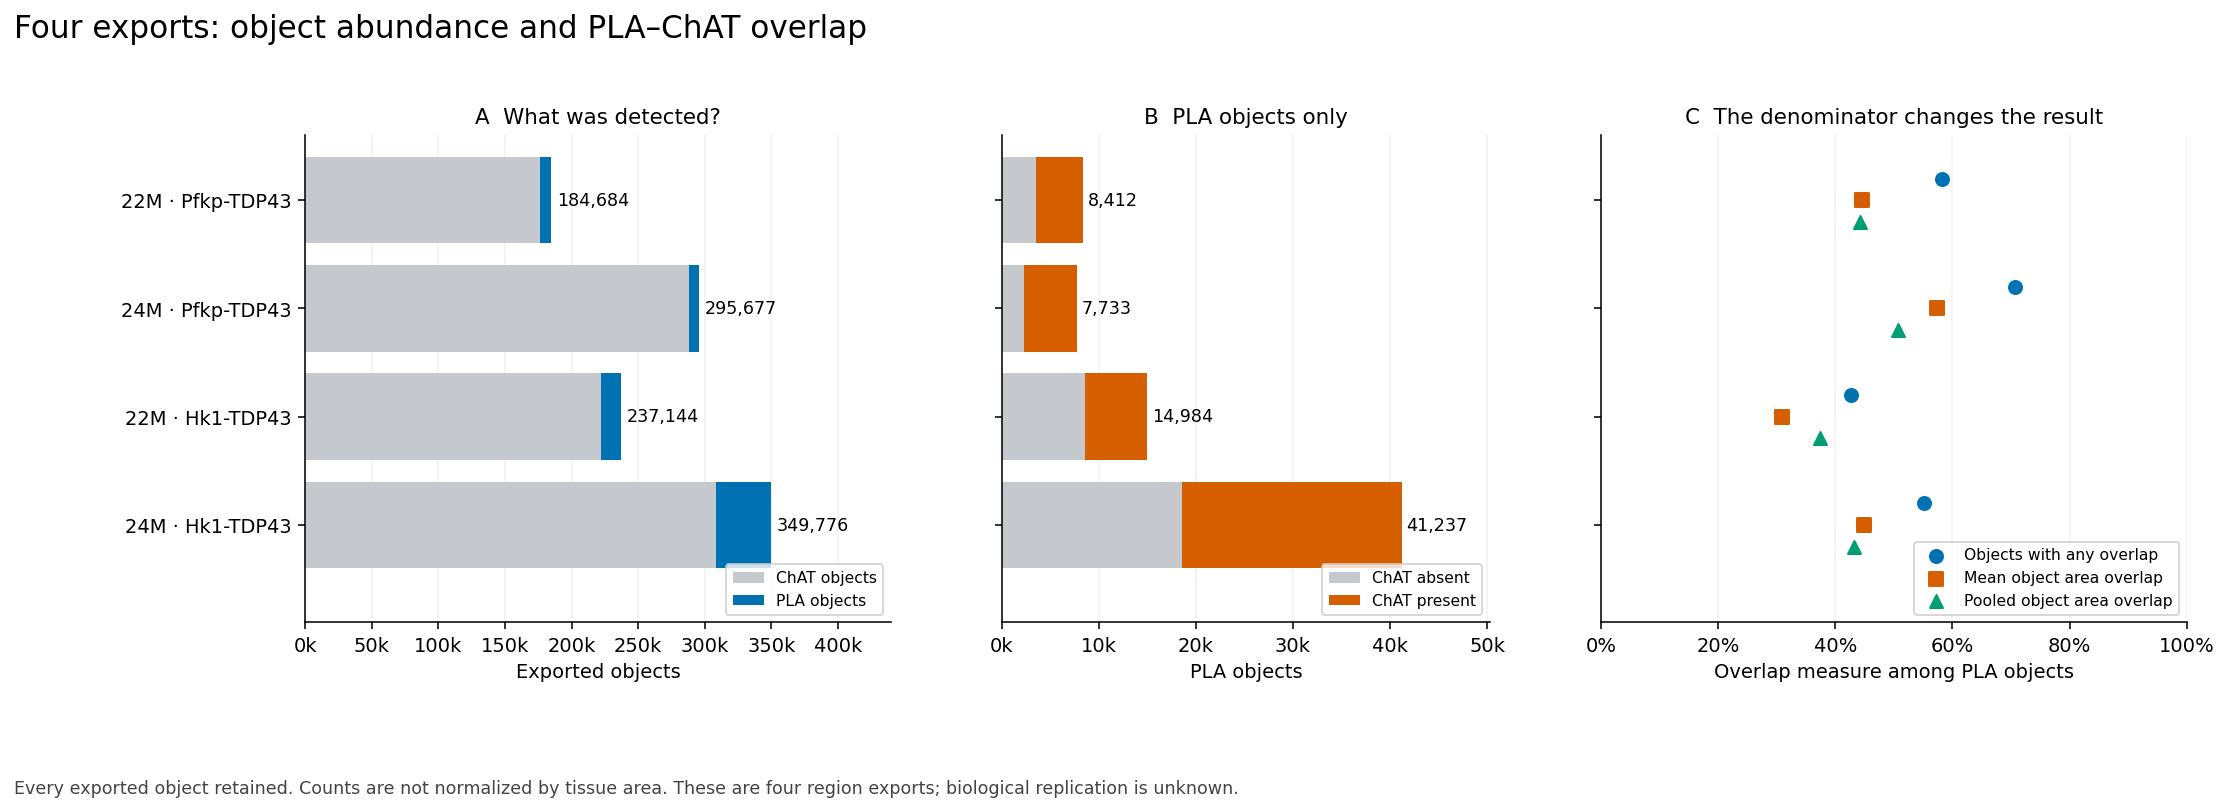

In [6]:
fig_overview, overview_table = overview(objects)
display(overview_table)
display(fig_overview)
save_figure(fig_overview, '03_overview_denominators', OUTPUT_ROOT / ROI_MODE)

## 4. Location: reconstructed spatial atlas

Count maps use fine bins; fraction and mean-overlap maps use coarser bins and require a minimum raw PLA denominator. For a supported bin, the fraction is `100 x PLA objects with ChAT present / PLA objects`. The support threshold is a visibility rule, not a significance cutoff.

Read fraction maps together with count/support maps. A bright fraction in a sparse bin is not equivalent to a bright count hotspot. Blank space does not establish tissue absence, and ChAT-object coverage is not a tissue mask.

**Action:** use hotspots to select image-review fields. Do not call them tissue enrichment until the analyzed tissue mask, physical calibration, and observation window are available. Keep unsmoothed maps as the quantitative reference.

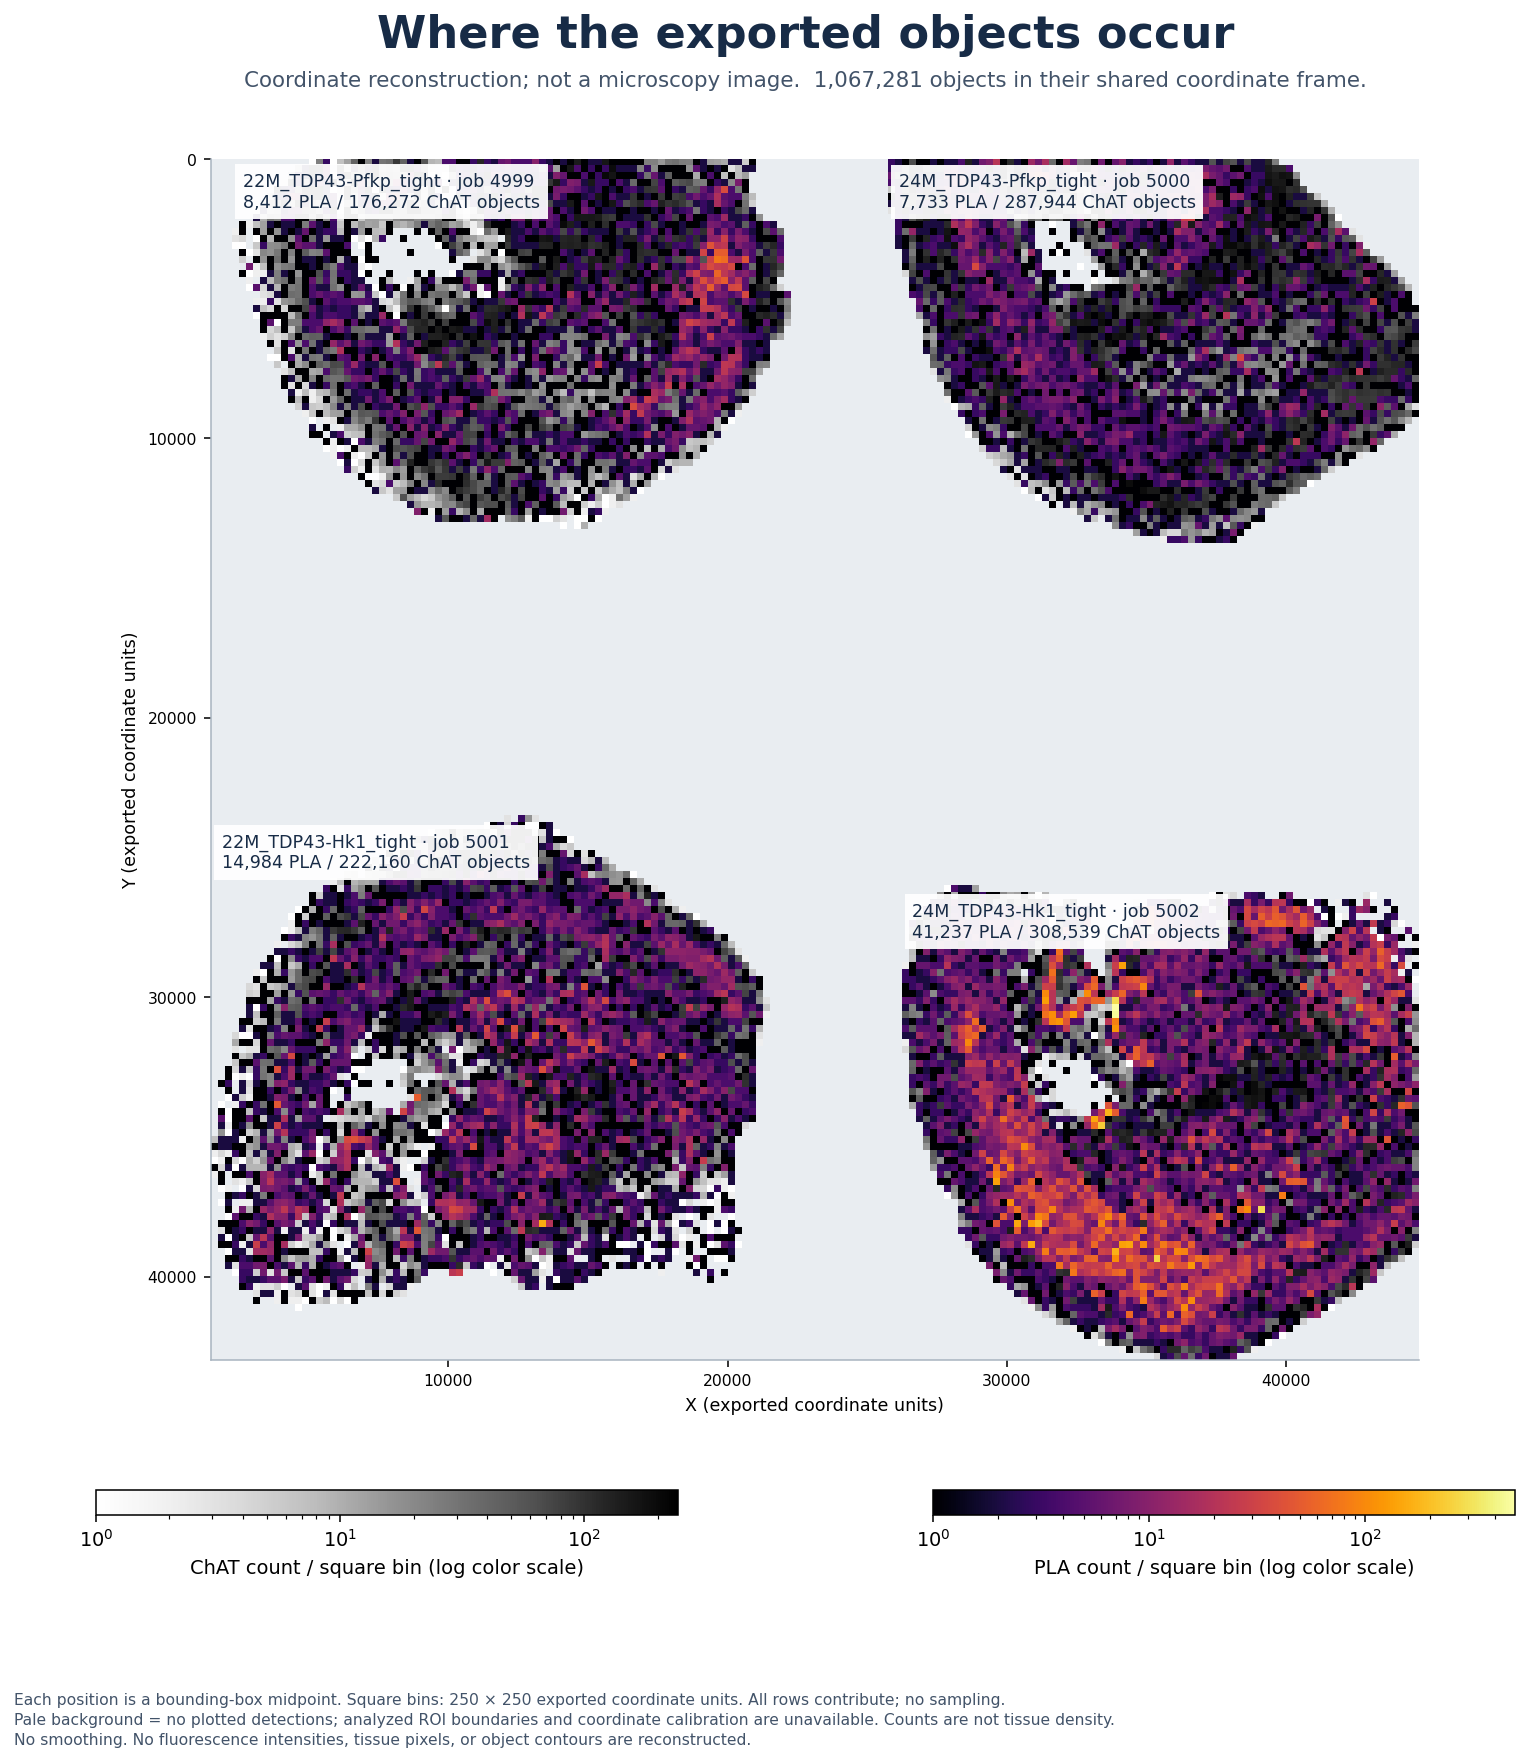

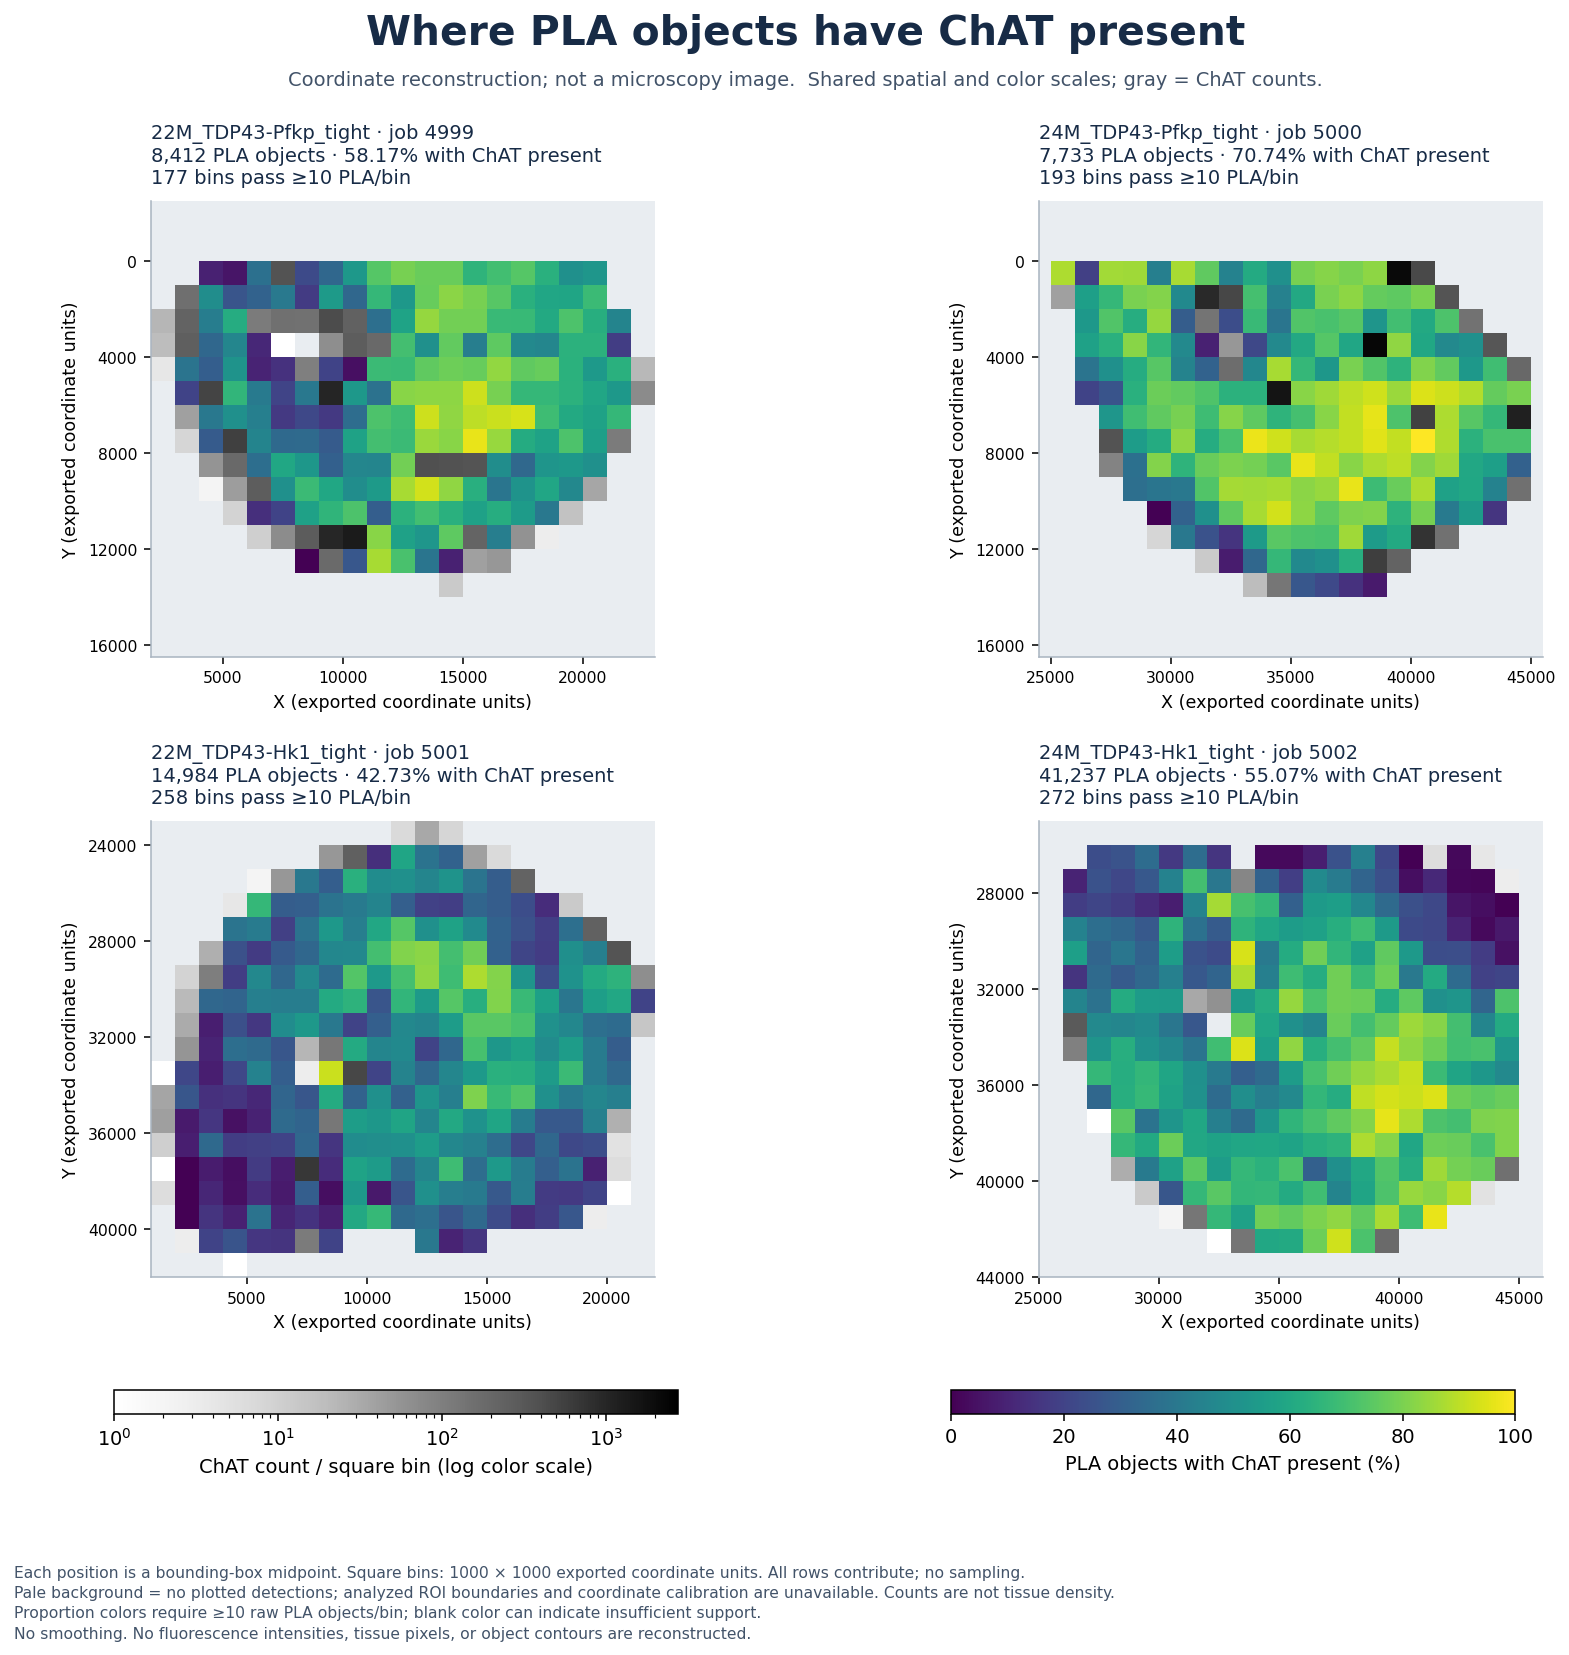

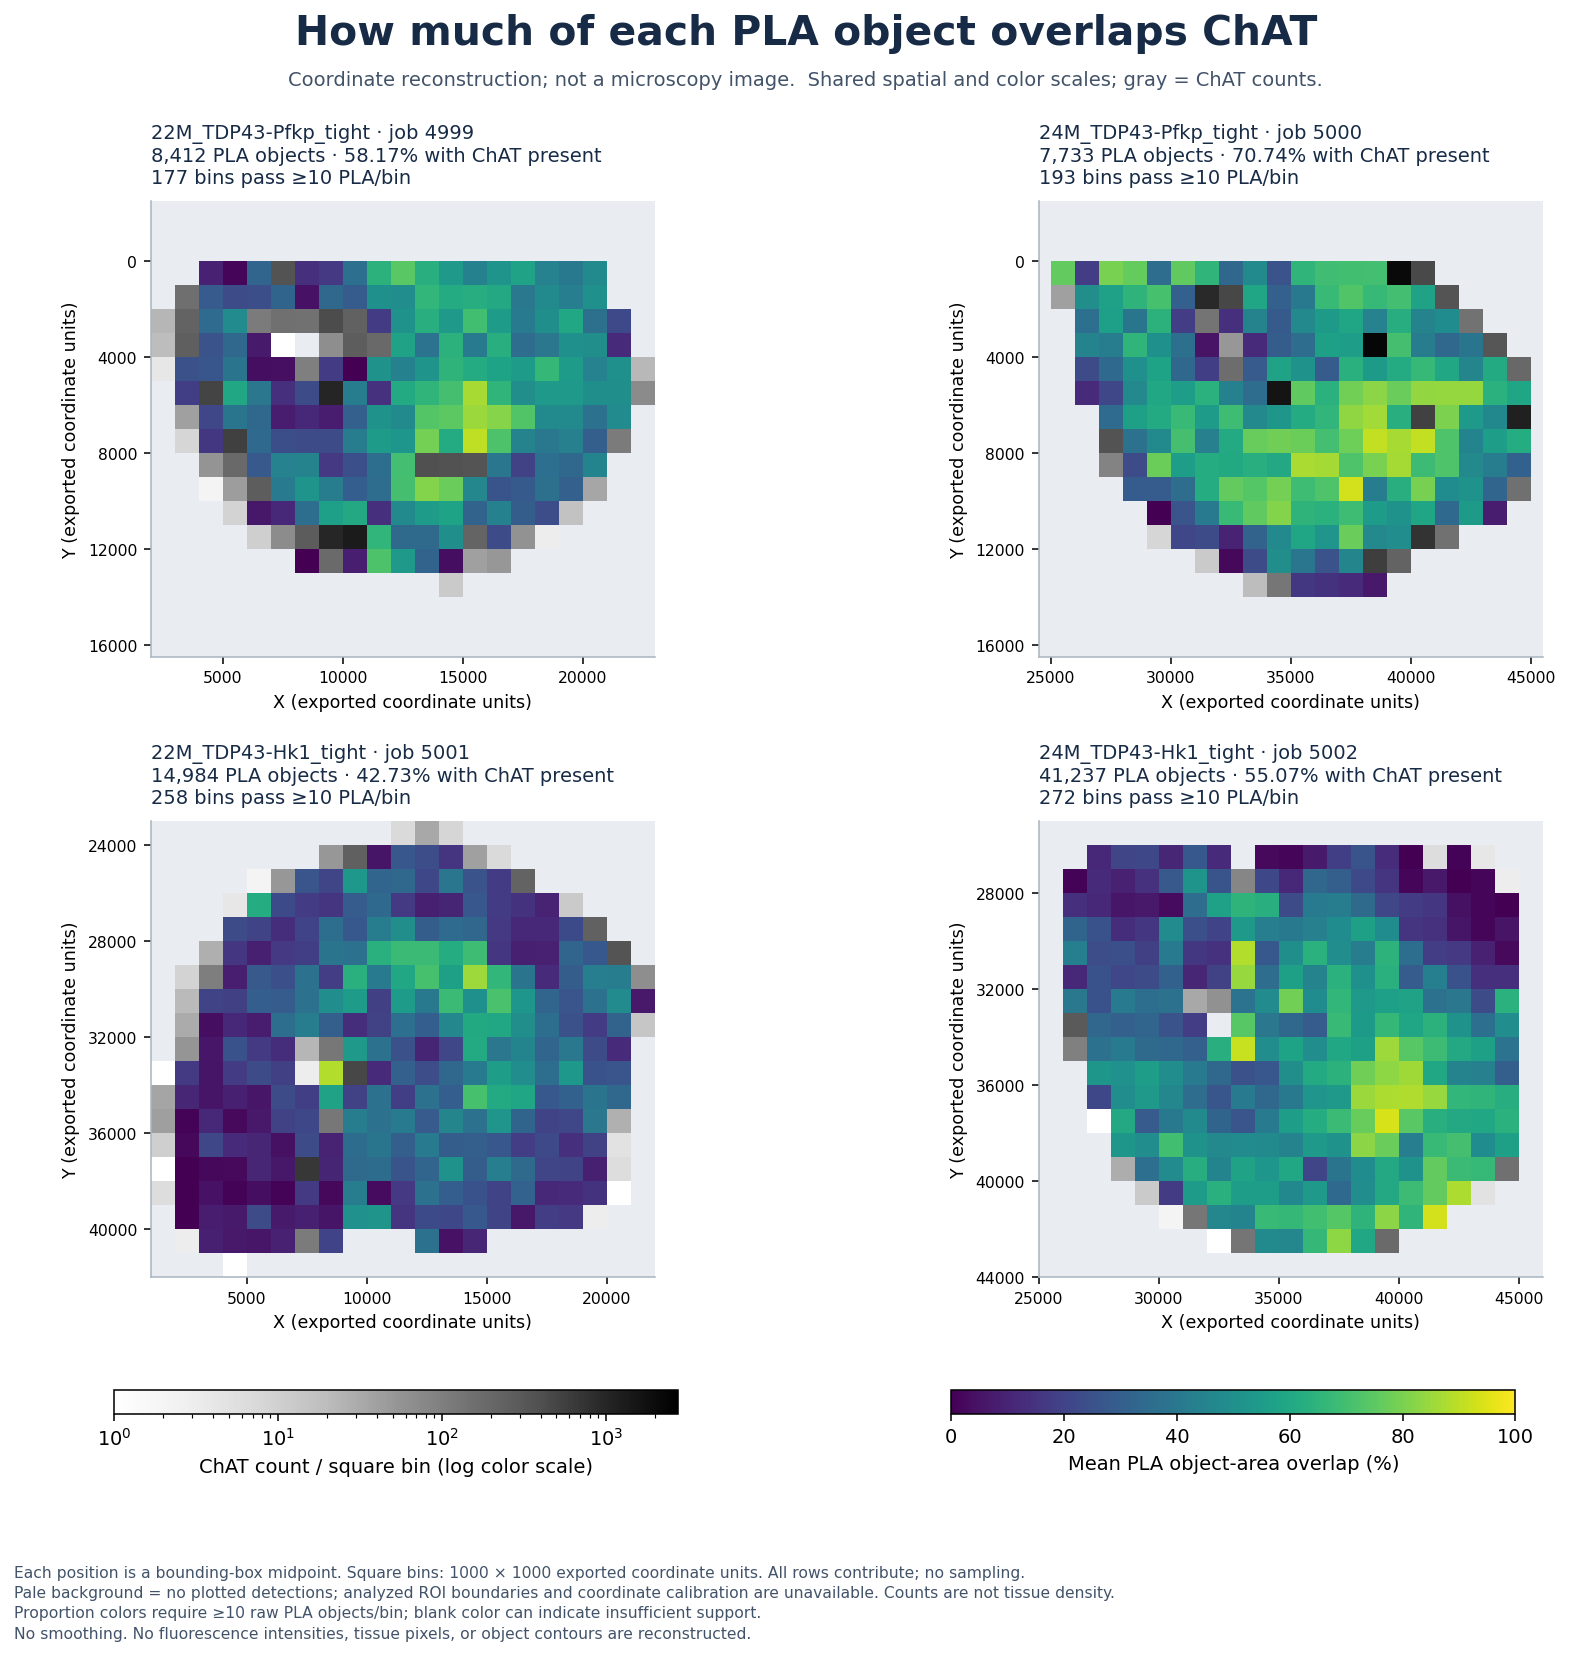

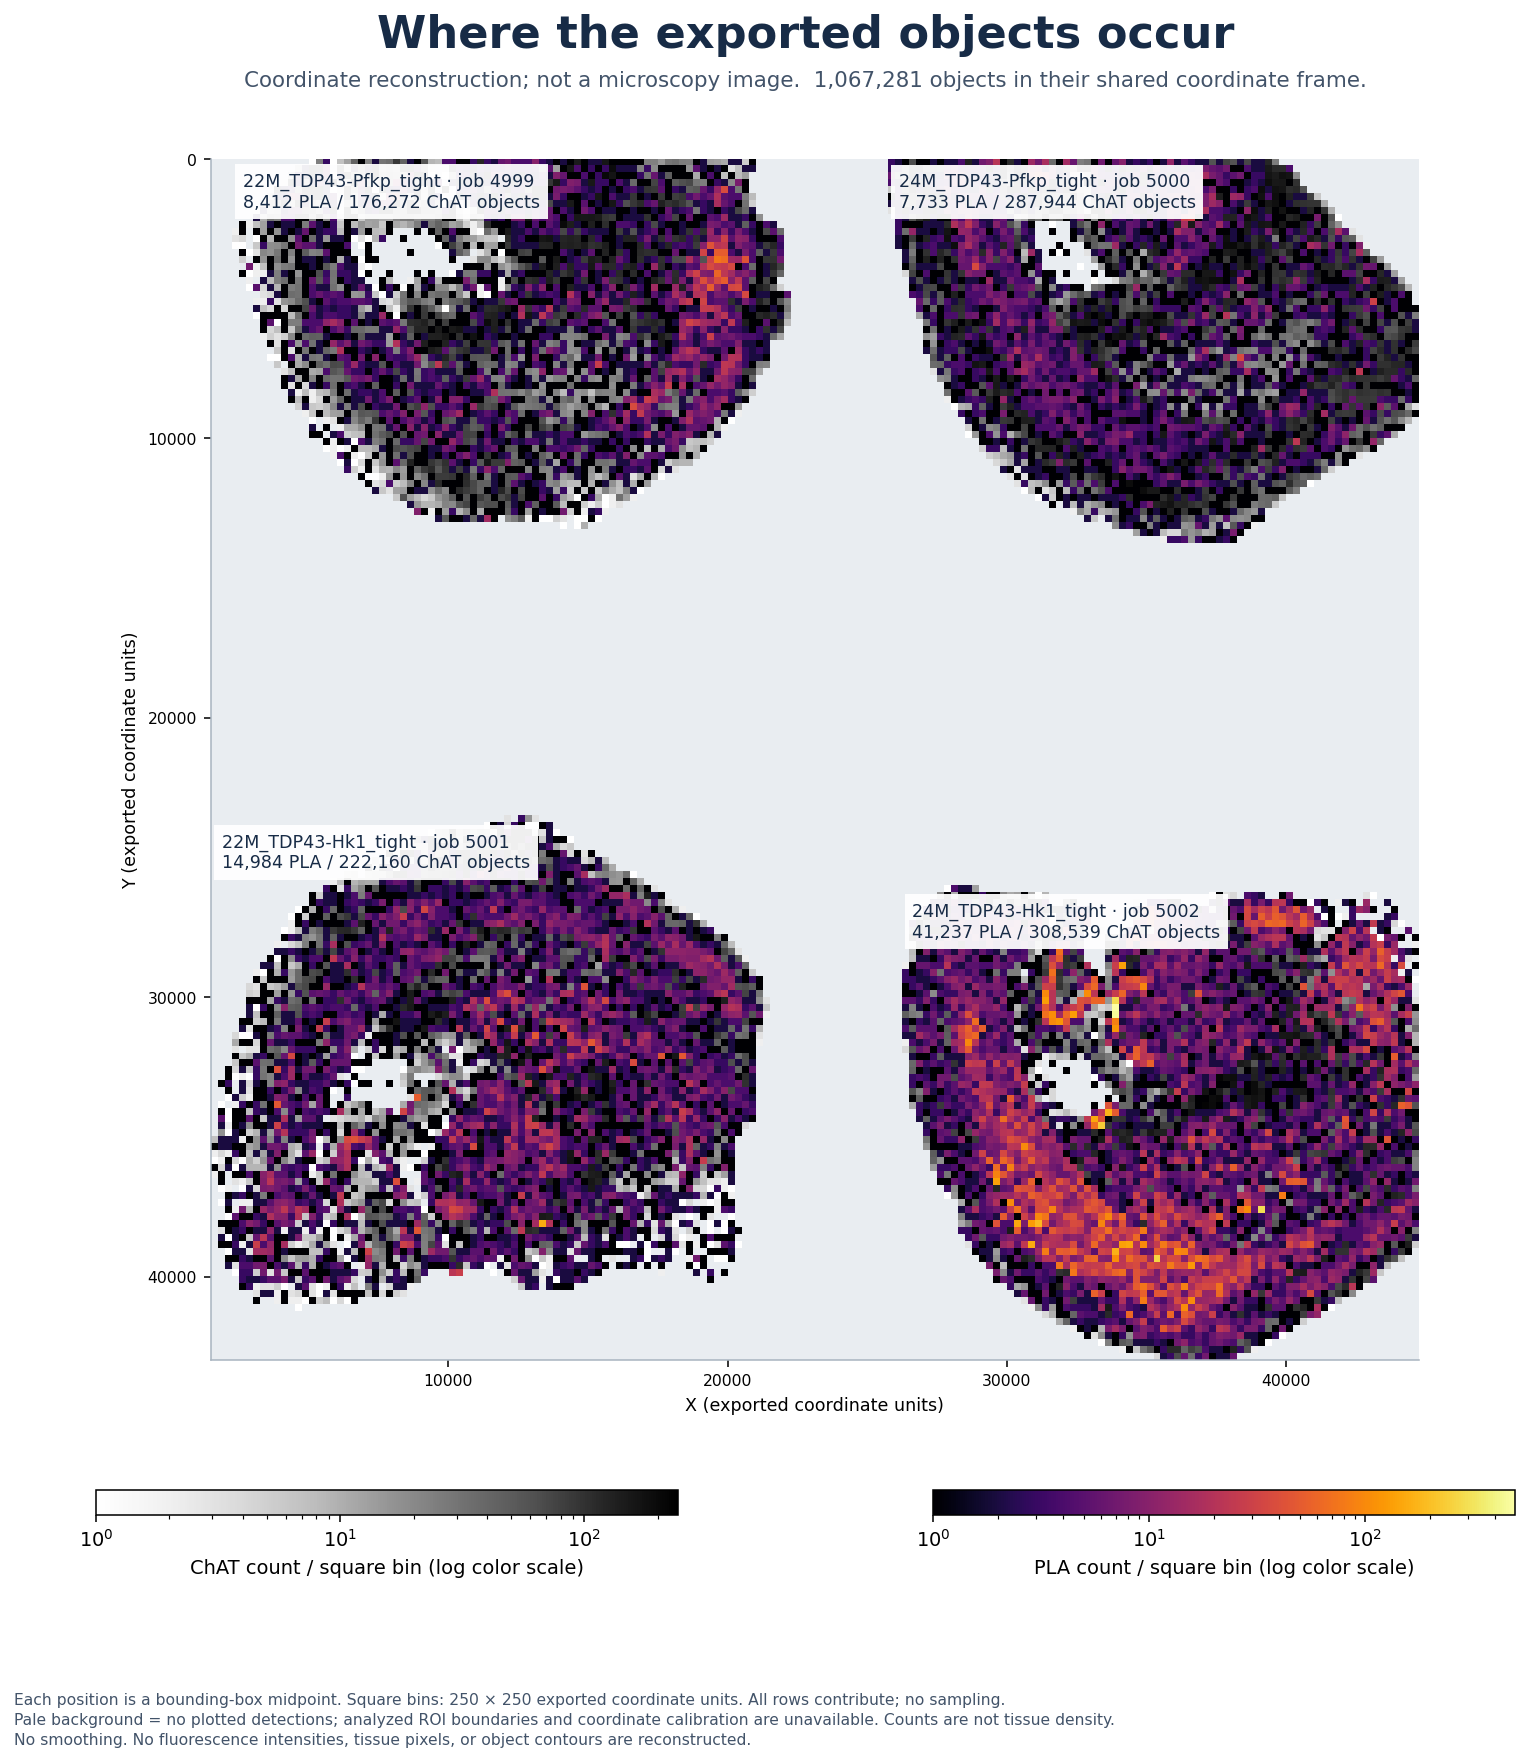

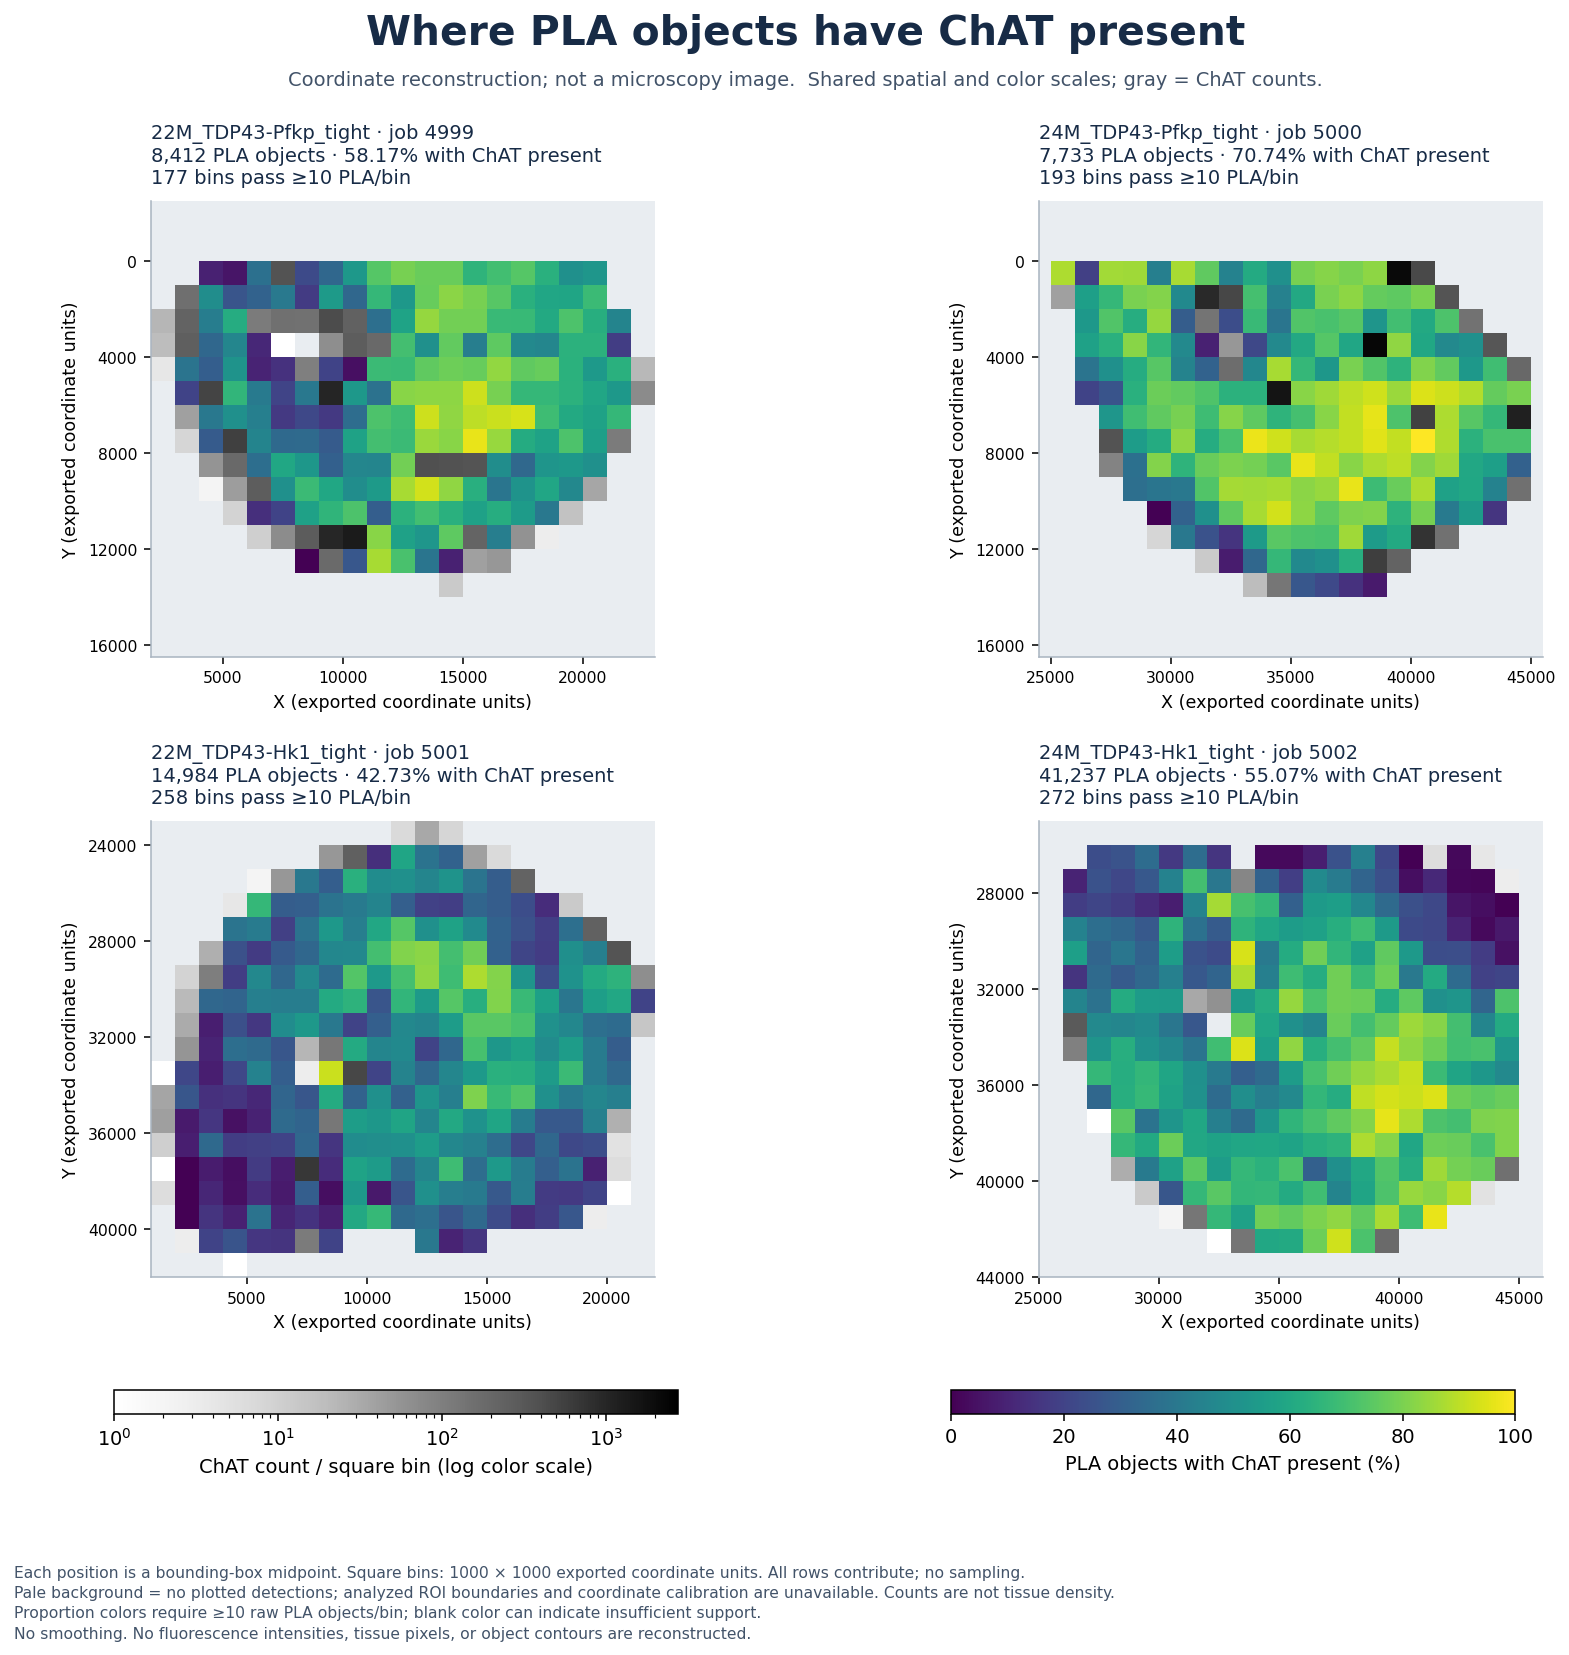

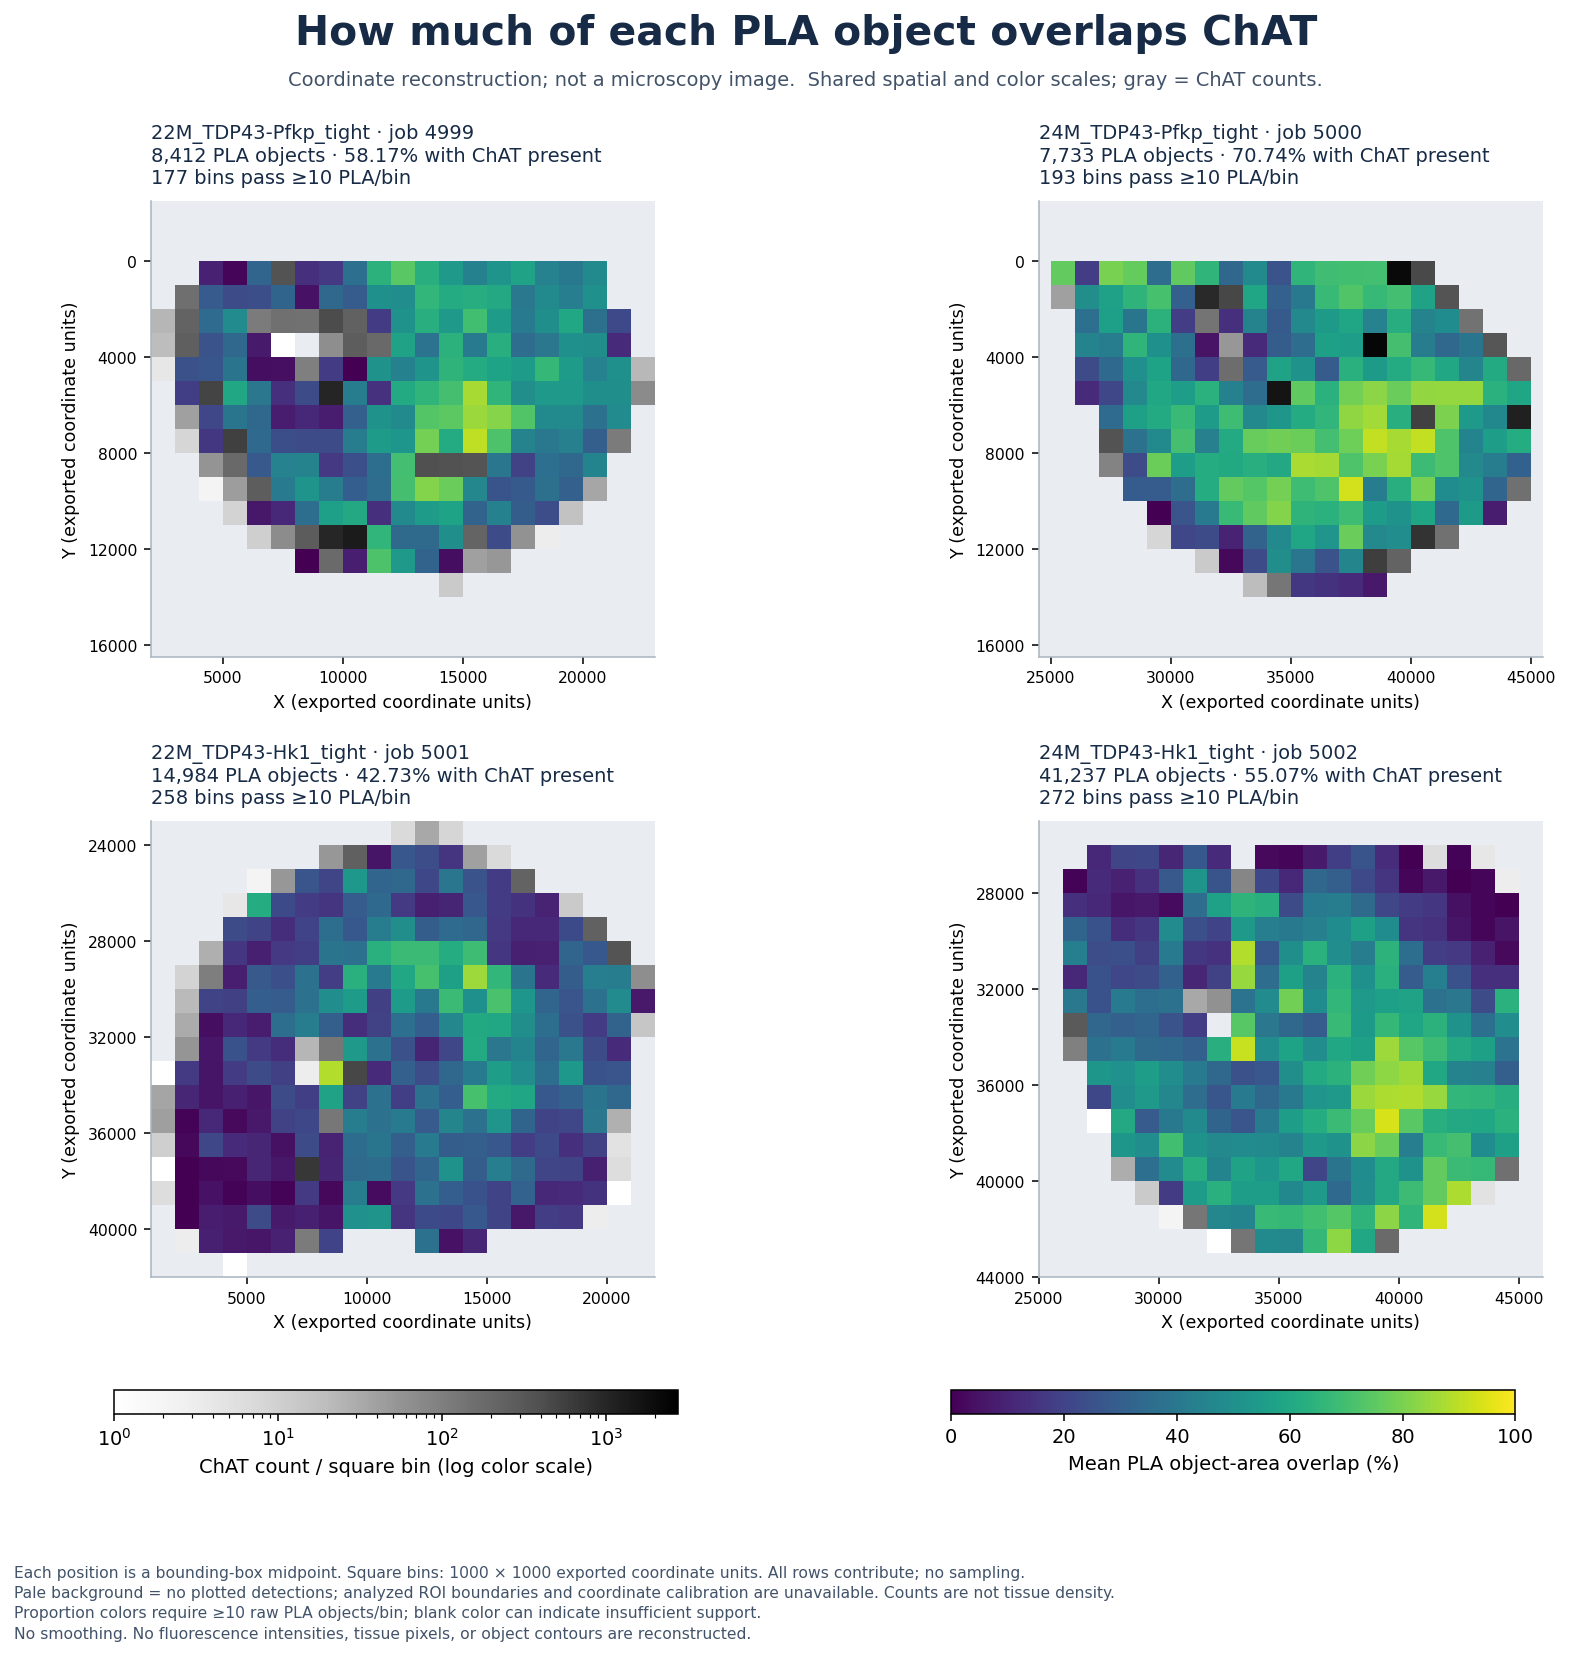

In [7]:
fig_count, count_table = coordinate_overview(objects, bin_width=COUNT_BIN_WIDTH)
display(fig_count)
save_figure(fig_count, '04_coordinate_reconstruction', OUTPUT_ROOT / ROI_MODE)
spatial_tables = {'coordinate_overview': count_table}
for metric, name in [('pla_fraction', '05_PLA_fraction_with_ChAT'), ('mean_overlap', '06_mean_PLA_overlap')]:
    fig, table = spatial_atlas(objects, metric=metric, bin_width=FRACTION_BIN_WIDTH, min_support=MIN_PLA_SUPPORT, smoothing=SPATIAL_SMOOTHING)
    display(fig)
    save_figure(fig, name, OUTPUT_ROOT / ROI_MODE)
    spatial_tables[metric + '_atlas'] = table

## 5. Field review: detailed overlay and exported boxes

This is the closest image-like view available from the tables: a selected PLA-derived metric over a grayscale ChAT-count layer, paired with its raw PLA denominator. Hatching marks nonempty bins that do not meet the support threshold. The bounding-box close-up helps assess whether apparent clusters are plausible objects or coordinate/segmentation artifacts.

**Action:** review dense, sparse, unusually bright, extreme-size, and boundary-adjacent fields against the original image. Compare the same fields between box and outline modes where possible. Do not treat rectangles as cell outlines or the grayscale layer as a tissue mask.

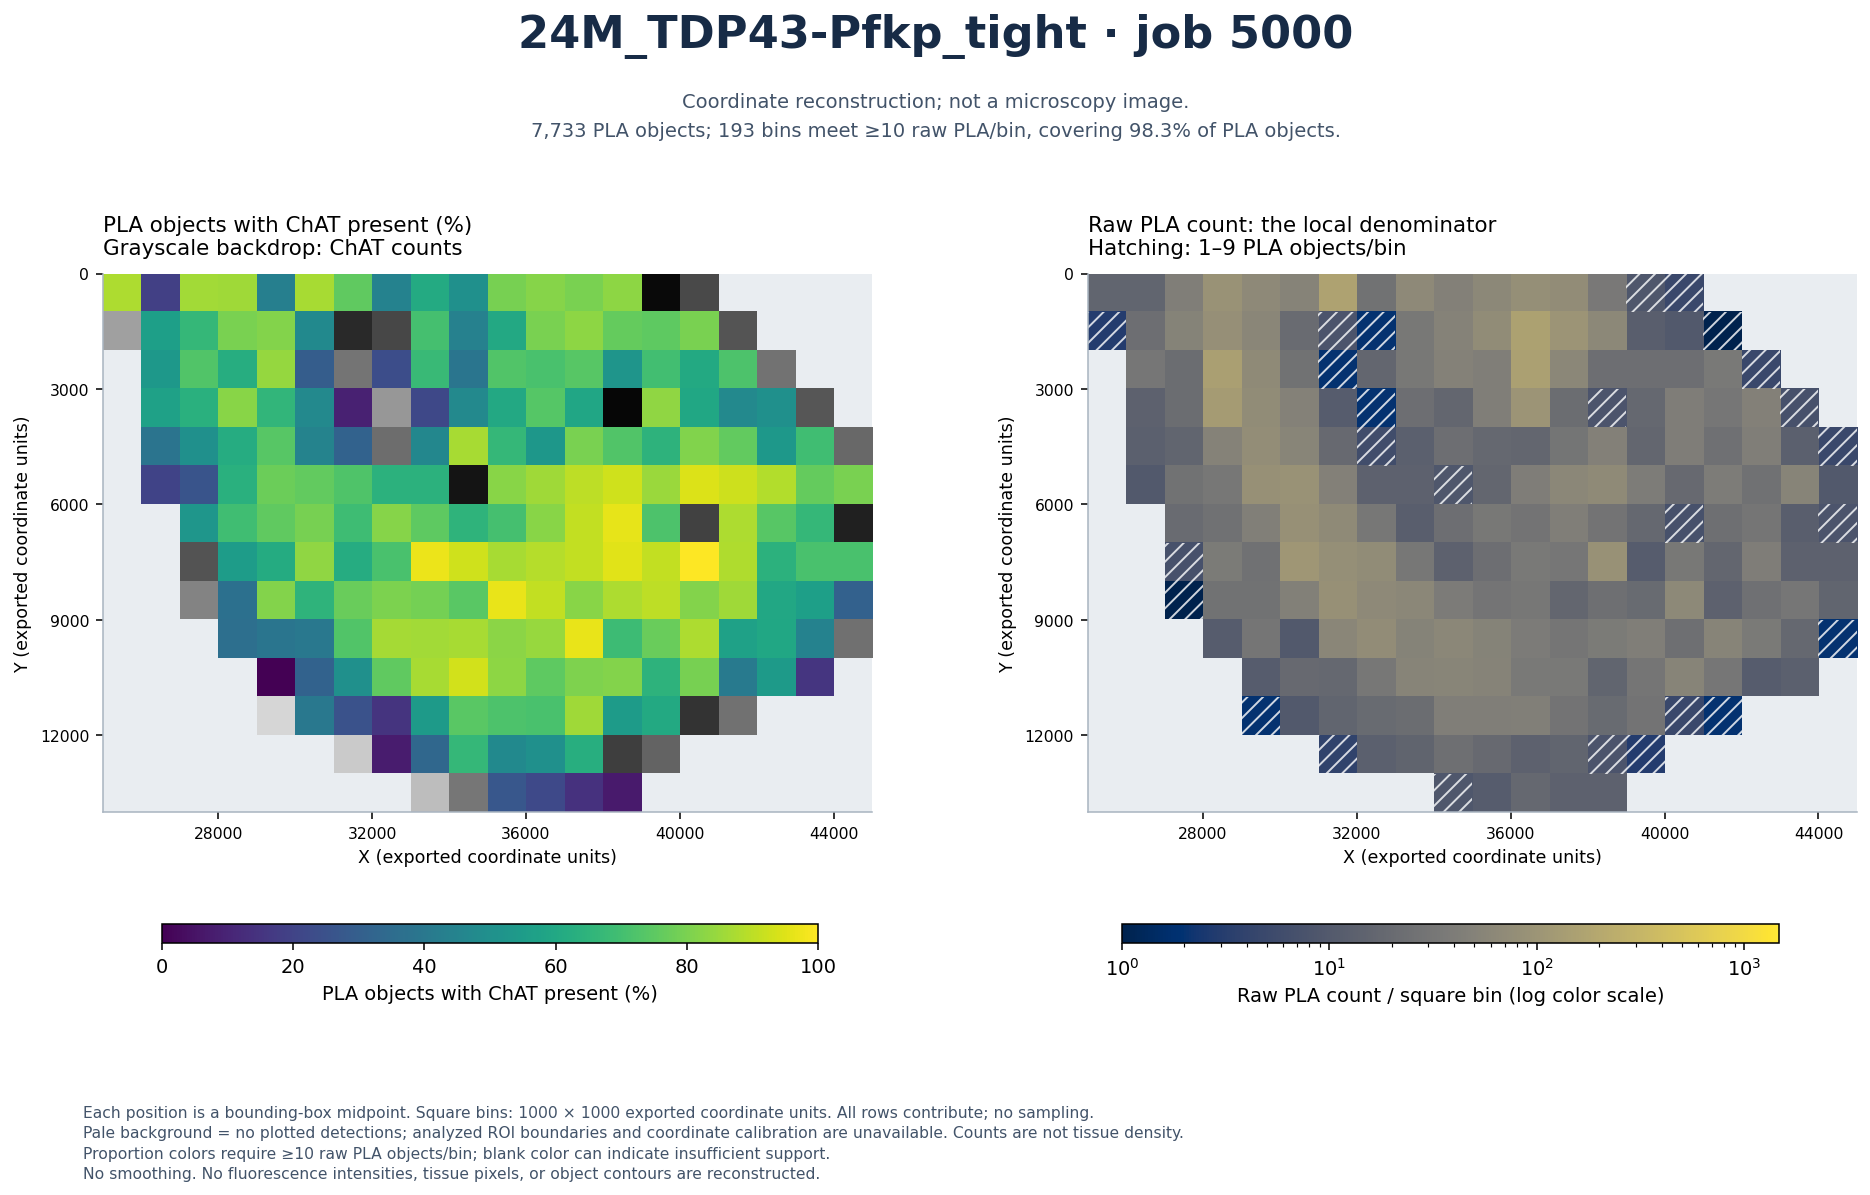

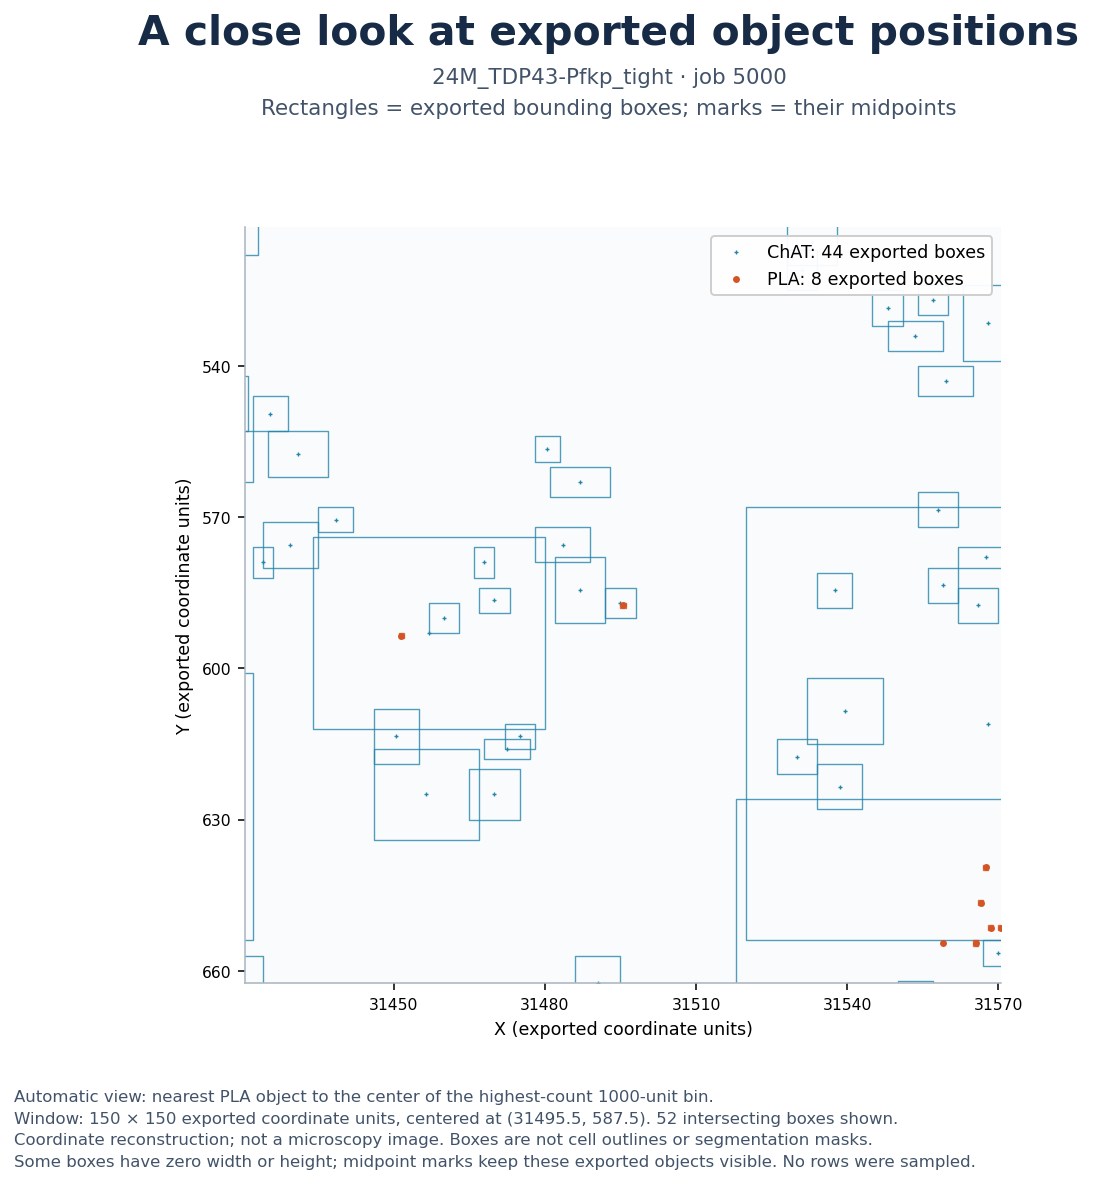

[PosixPath('/Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/scientific_notebook/outline/figures/08_exported_boxes_5000.png'),
 PosixPath('/Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/scientific_notebook/outline/figures/08_exported_boxes_5000.pdf')]

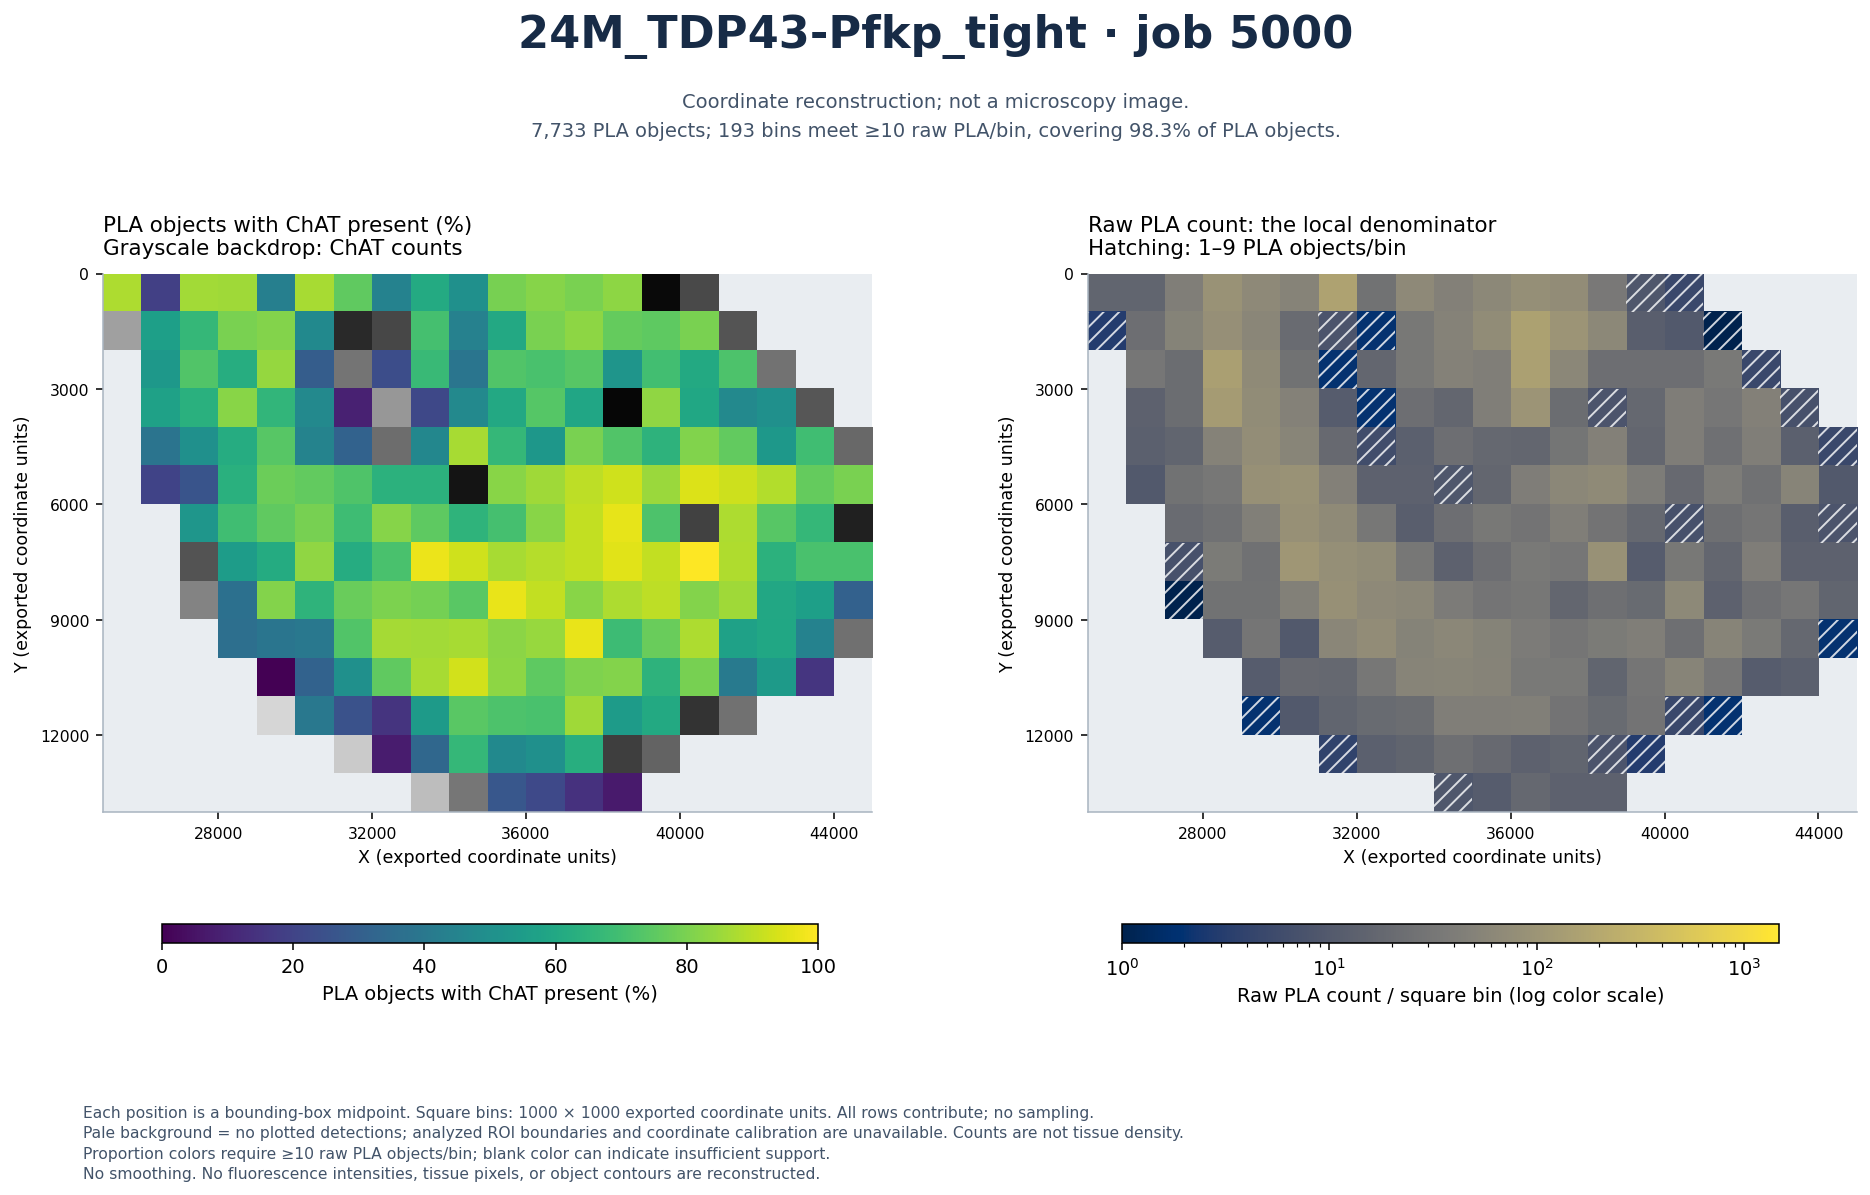

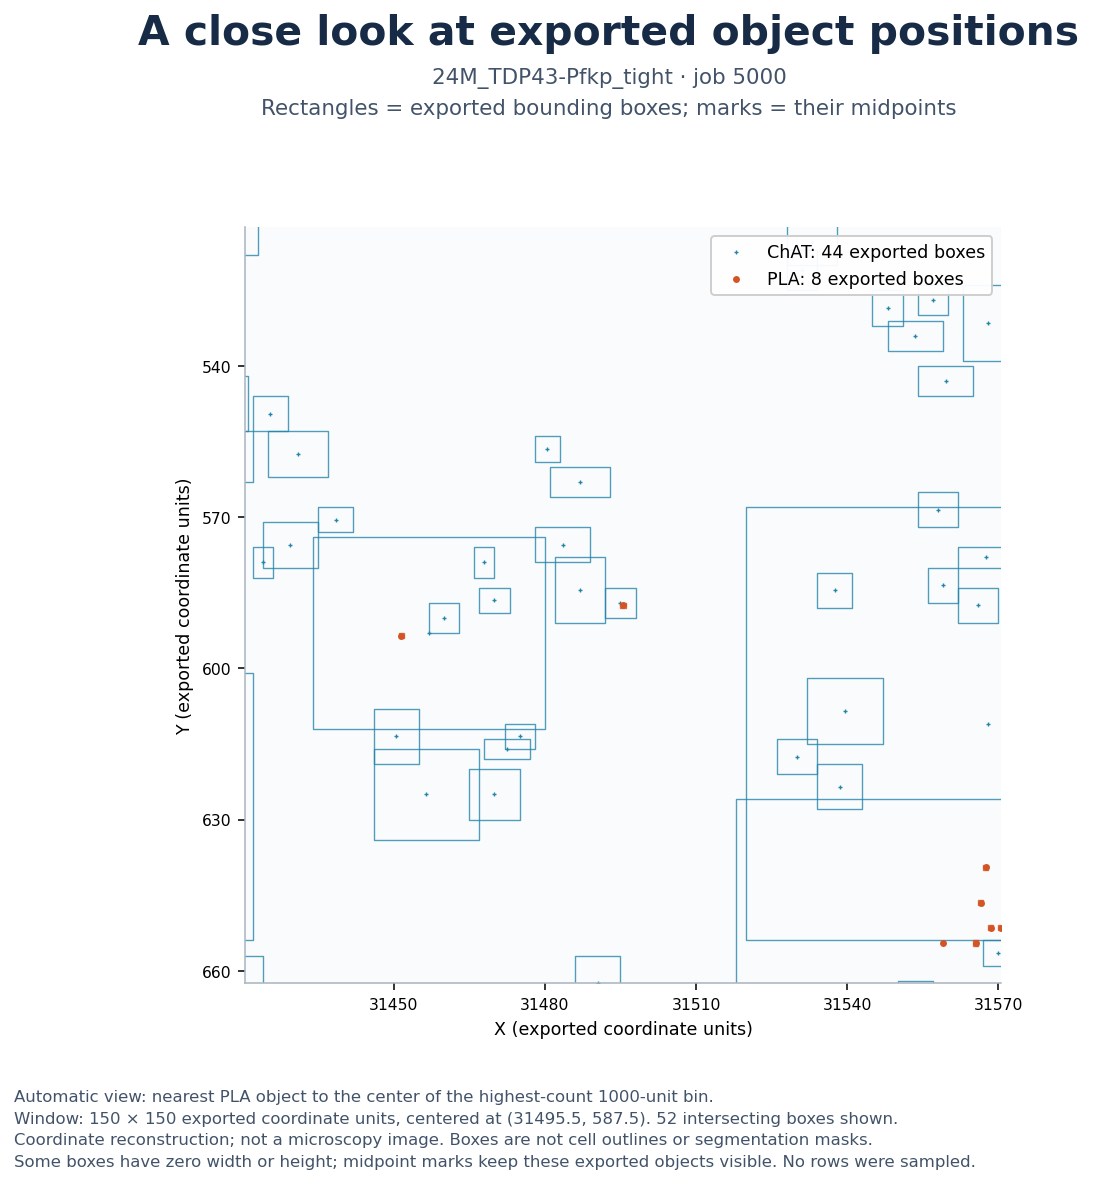

In [8]:
fig_focus, focus_table = region_heatmap(objects, FOCUS_JOB, metric='pla_fraction', bin_width=FRACTION_BIN_WIDTH, min_support=MIN_PLA_SUPPORT, smoothing=SPATIAL_SMOOTHING)
display(fig_focus)
save_figure(fig_focus, f'07_detailed_overlay_{FOCUS_JOB}', OUTPUT_ROOT / ROI_MODE)
fig_boxes = bounding_box_zoom(objects, FOCUS_JOB, window=FOCUS_WINDOW)
display(fig_boxes)
save_figure(fig_boxes, f'08_exported_boxes_{FOCUS_JOB}', OUTPUT_ROOT / ROI_MODE)

## 6. Distribution and tail review

ECDFs preserve the full distribution and ties. The overlap composition preserves exact 0% and 100% endpoint masses. Two-dimensional bins show object counts across area and overlap; they are measurement bins, not image pixels.

Use distributions to distinguish a broad shift from a result driven by a small upper tail. If a regional difference disappears after reviewing the largest objects or geometry features, treat it as a measurement-review issue rather than evidence of mechanism.

**Action:** do not remove small or large objects because a plot looks inconvenient. Document any rule, apply it consistently to both ROI modes, and report retained counts plus the change in association.

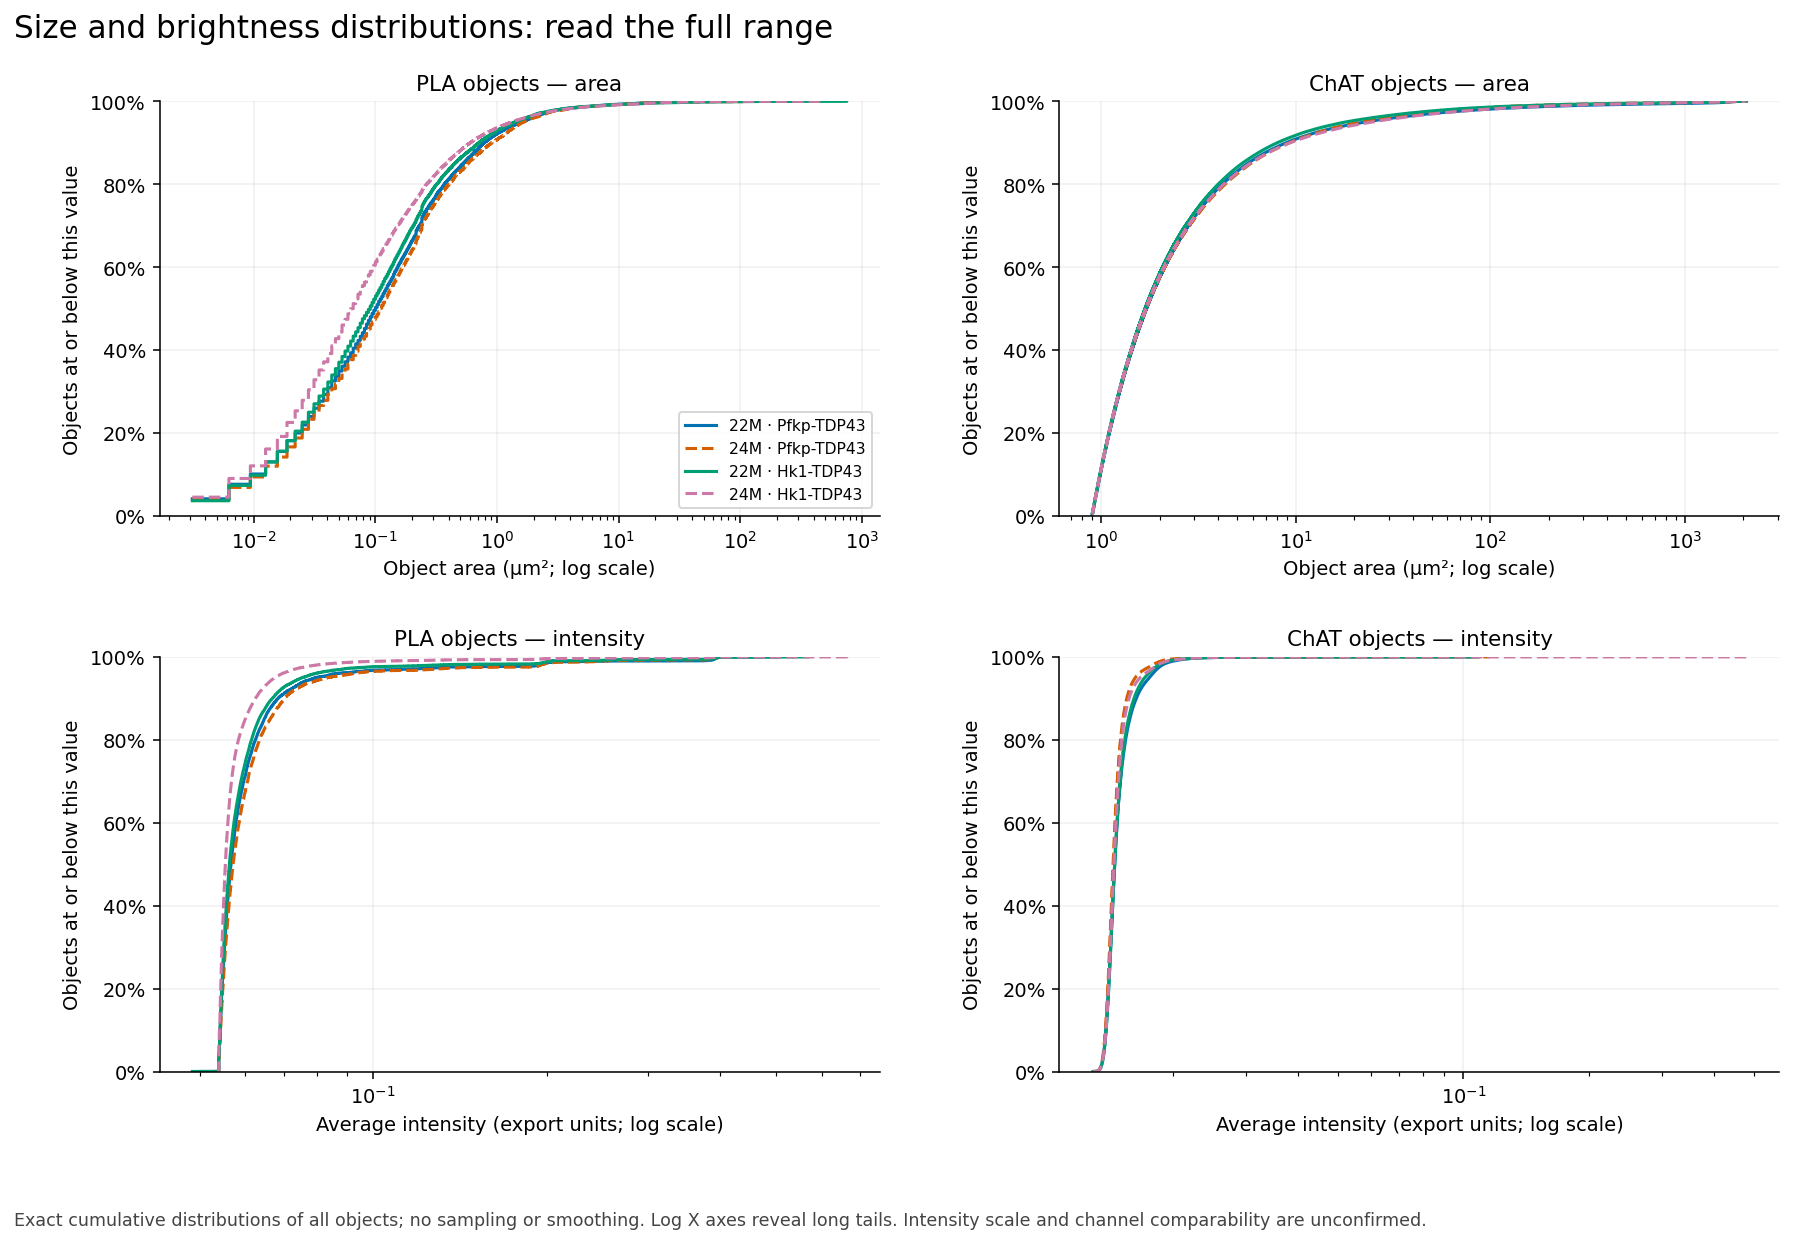

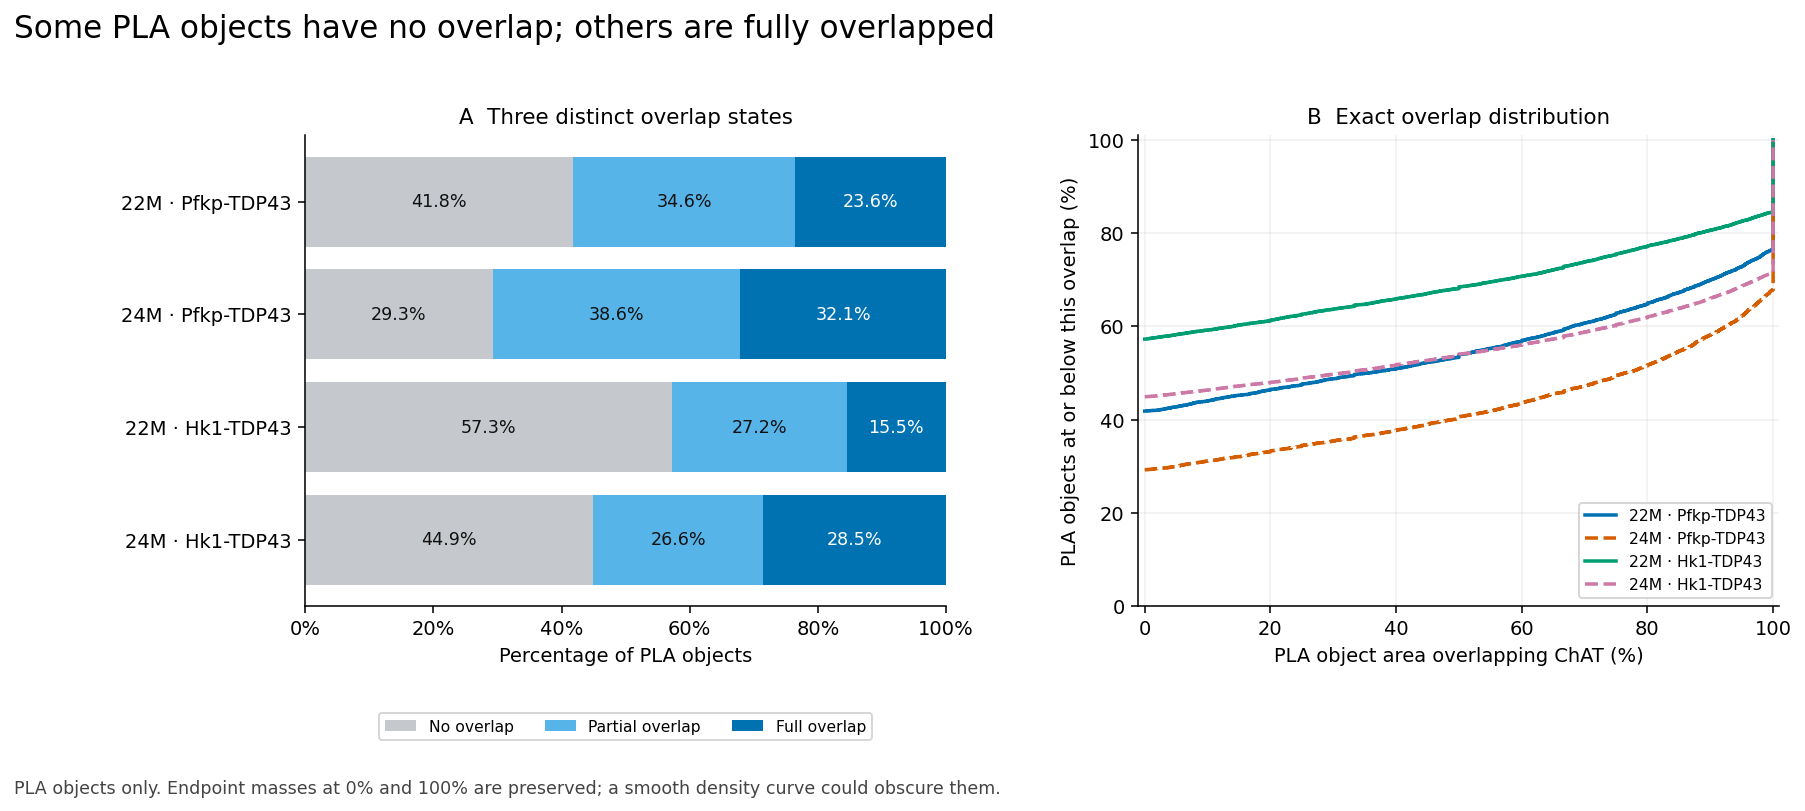

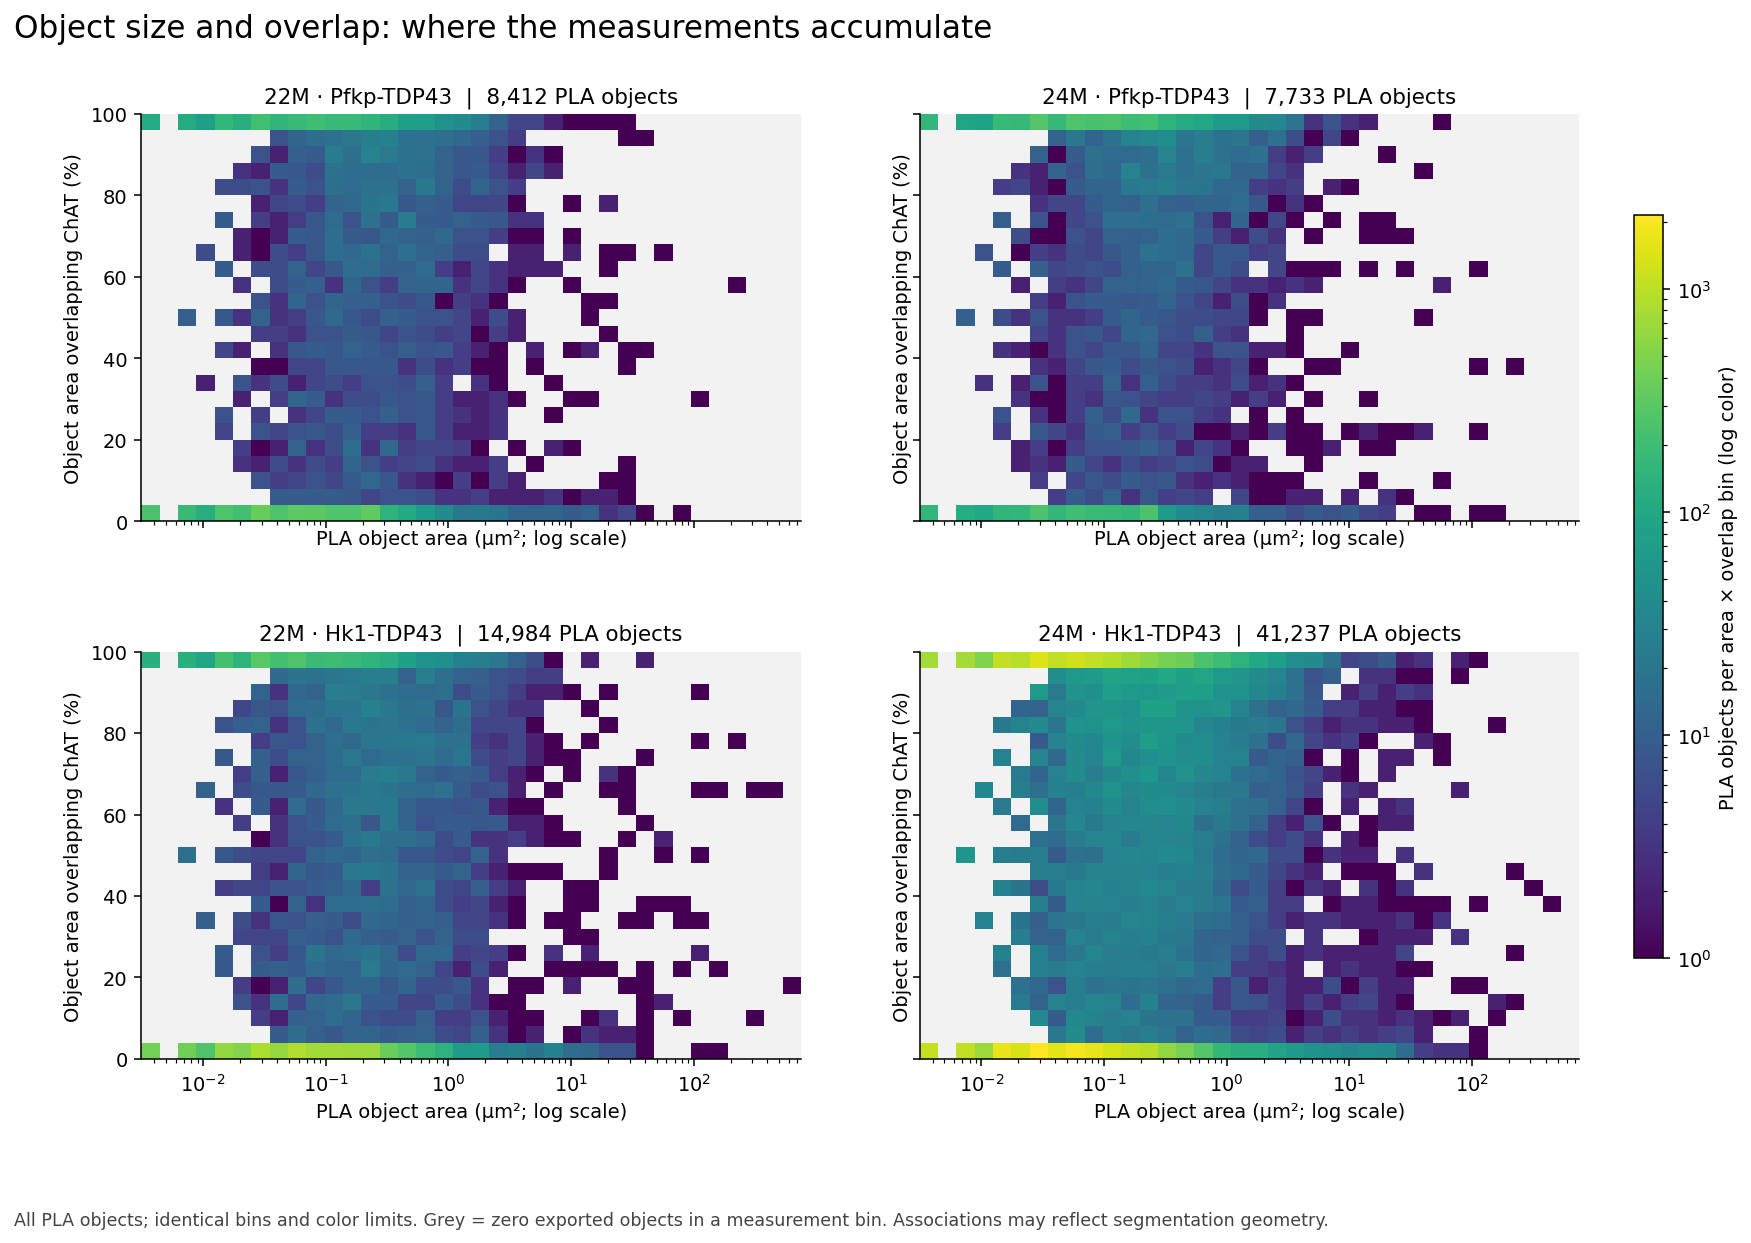

[PosixPath('/Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/scientific_notebook/outline/figures/11_size_overlap_bins.png'),
 PosixPath('/Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/scientific_notebook/outline/figures/11_size_overlap_bins.pdf')]

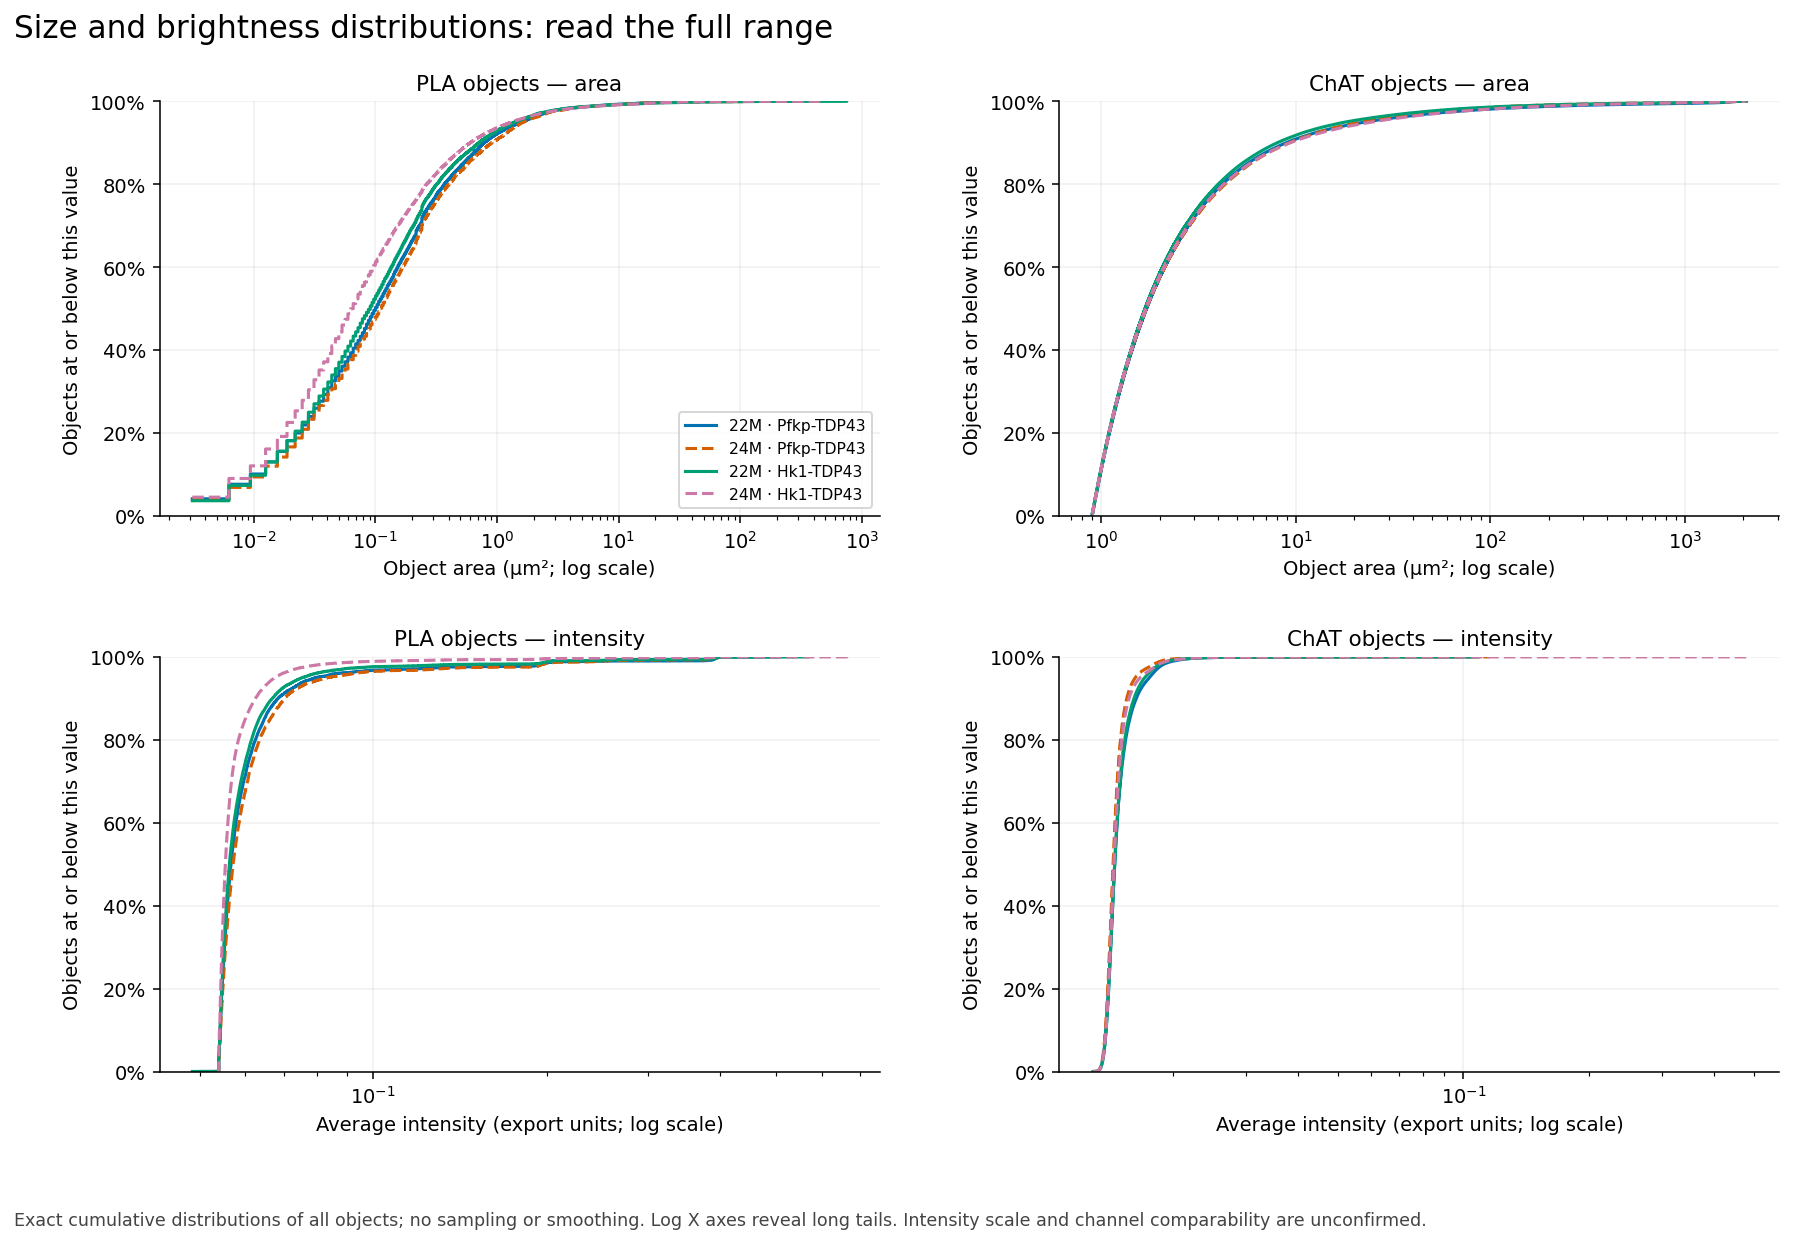

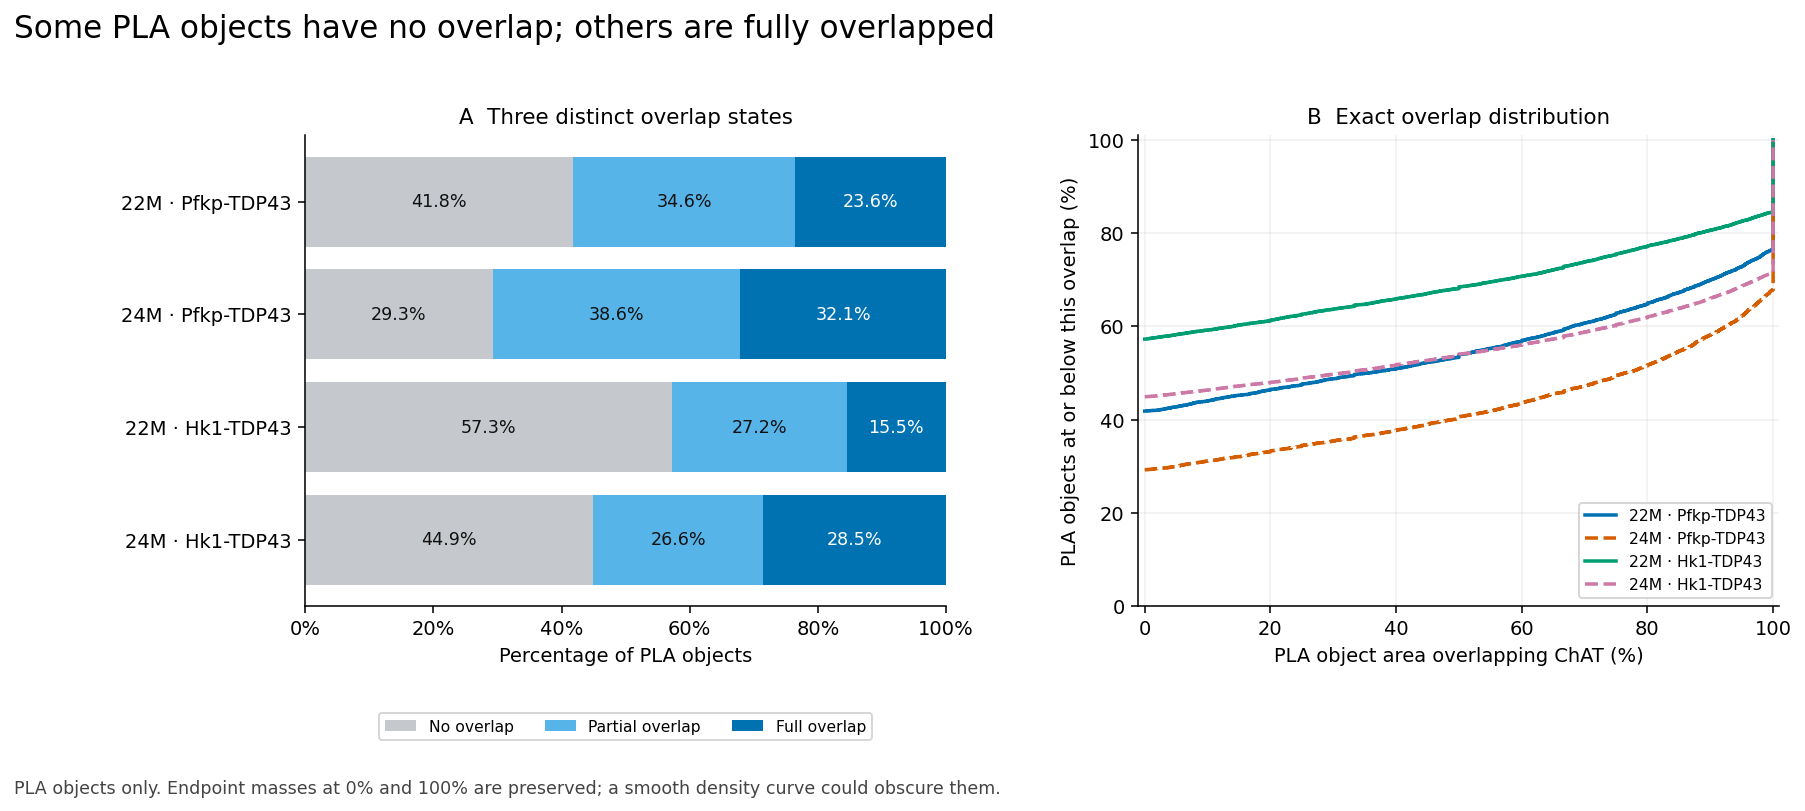

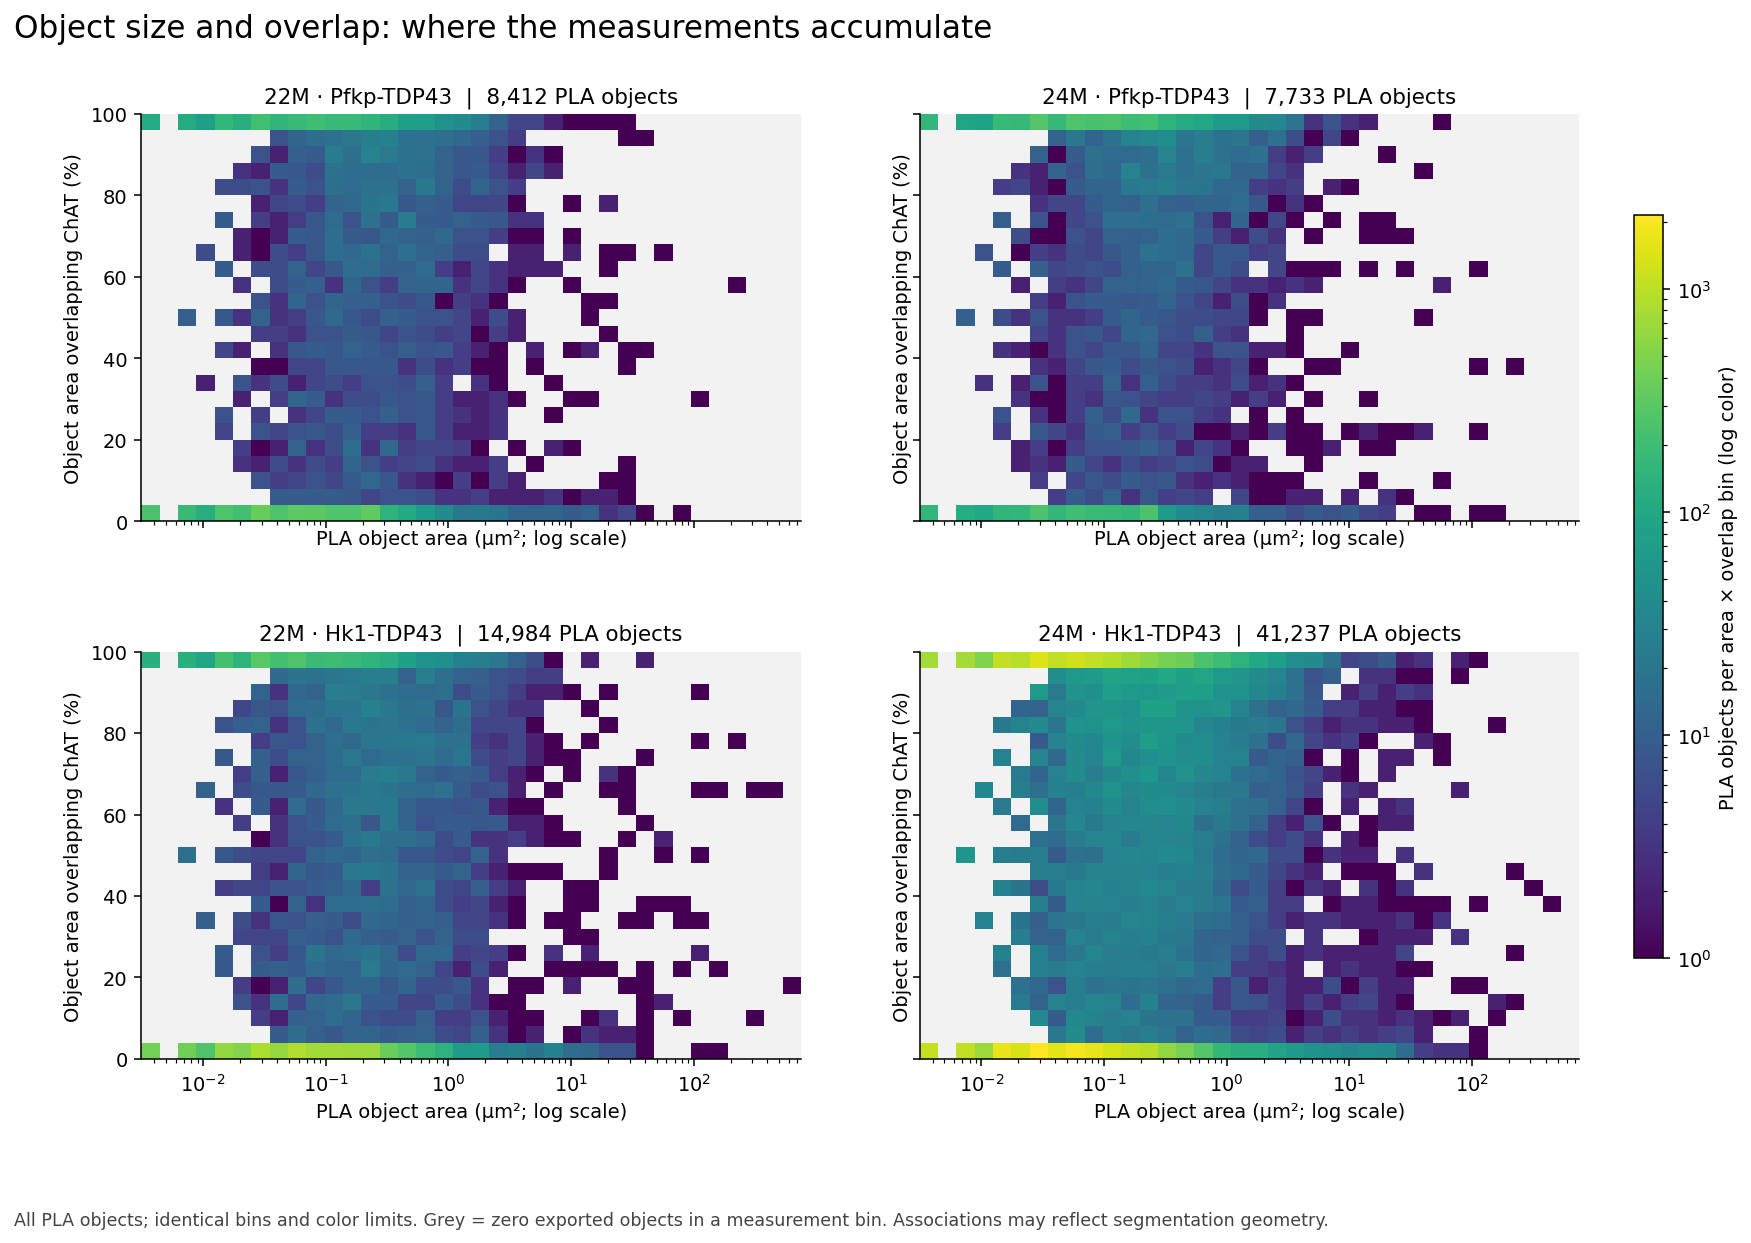

In [9]:
fig_ecdf, ecdf_table = ecdf_figures(objects)
display(fig_ecdf)
save_figure(fig_ecdf, '09_size_intensity_ecdfs', OUTPUT_ROOT / ROI_MODE)
fig_overlap, overlap_table = overlap_composition(objects)
display(fig_overlap)
save_figure(fig_overlap, '10_overlap_composition', OUTPUT_ROOT / ROI_MODE)
fig_size_overlap, size_overlap_table = size_overlap(objects)
display(fig_size_overlap)
save_figure(fig_size_overlap, '11_size_overlap_bins', OUTPUT_ROOT / ROI_MODE)

## 7. Quality review and sensitivity analysis

These views are prompts for image and parameter review, not automatic artifact calls. The quality map shows exported geometry features; area sensitivity shows how hypothetical thresholds change retained PLA objects and association; area concentration shows whether a small number of large objects dominate area-weighted summaries.

**Action:** inspect original pixels, antibody controls, acquisition settings, HALO thresholds, and representative objects before filtering. Preserve the unfiltered analysis as the primary descriptive result.

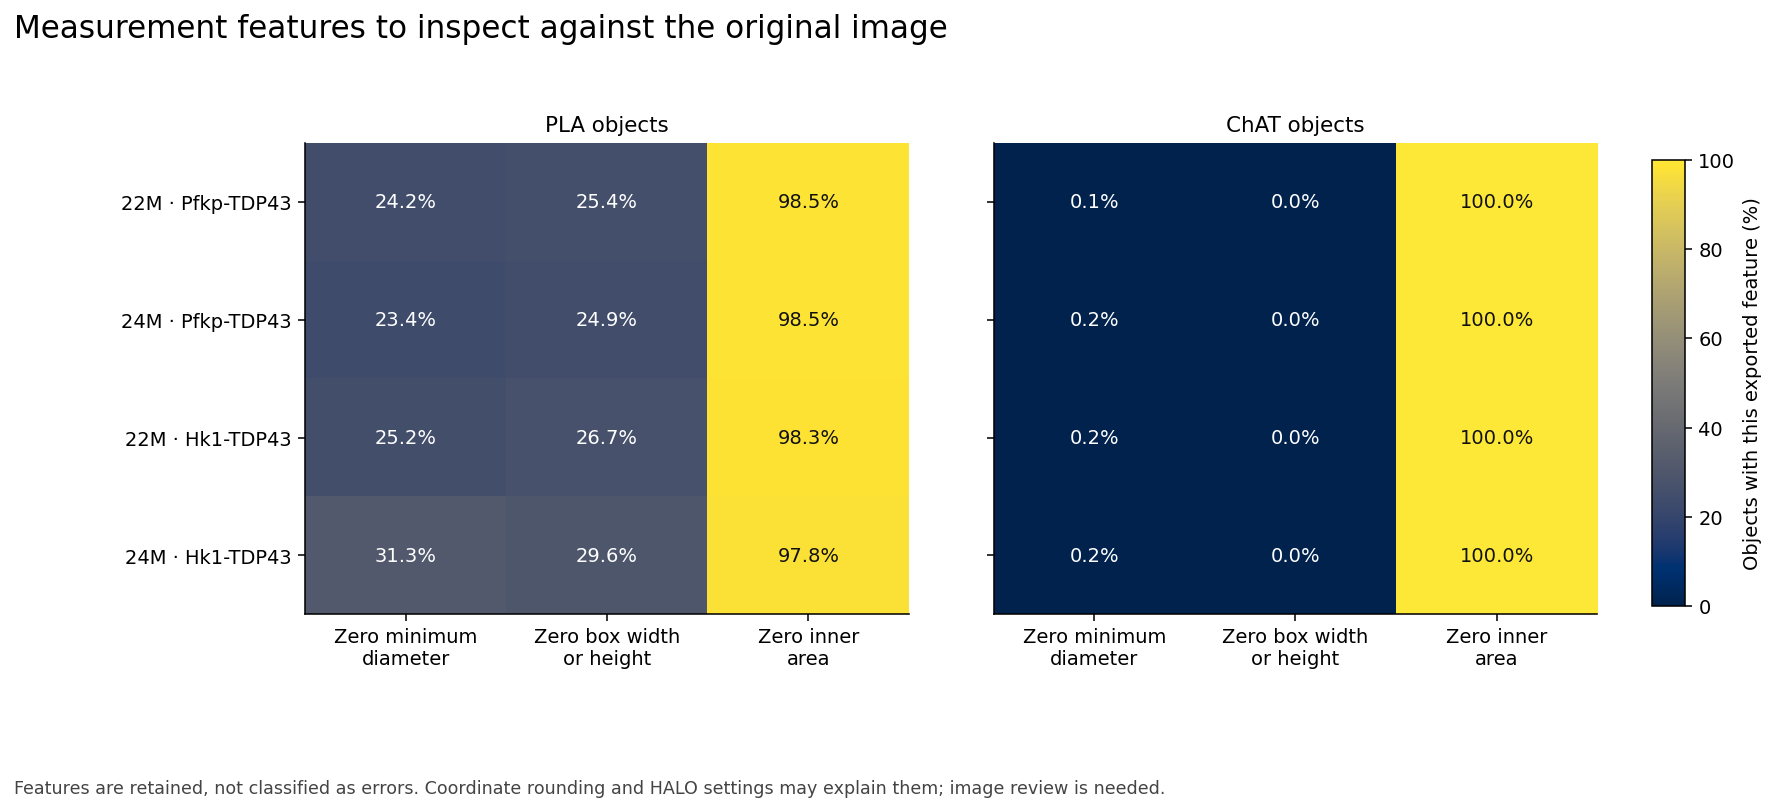

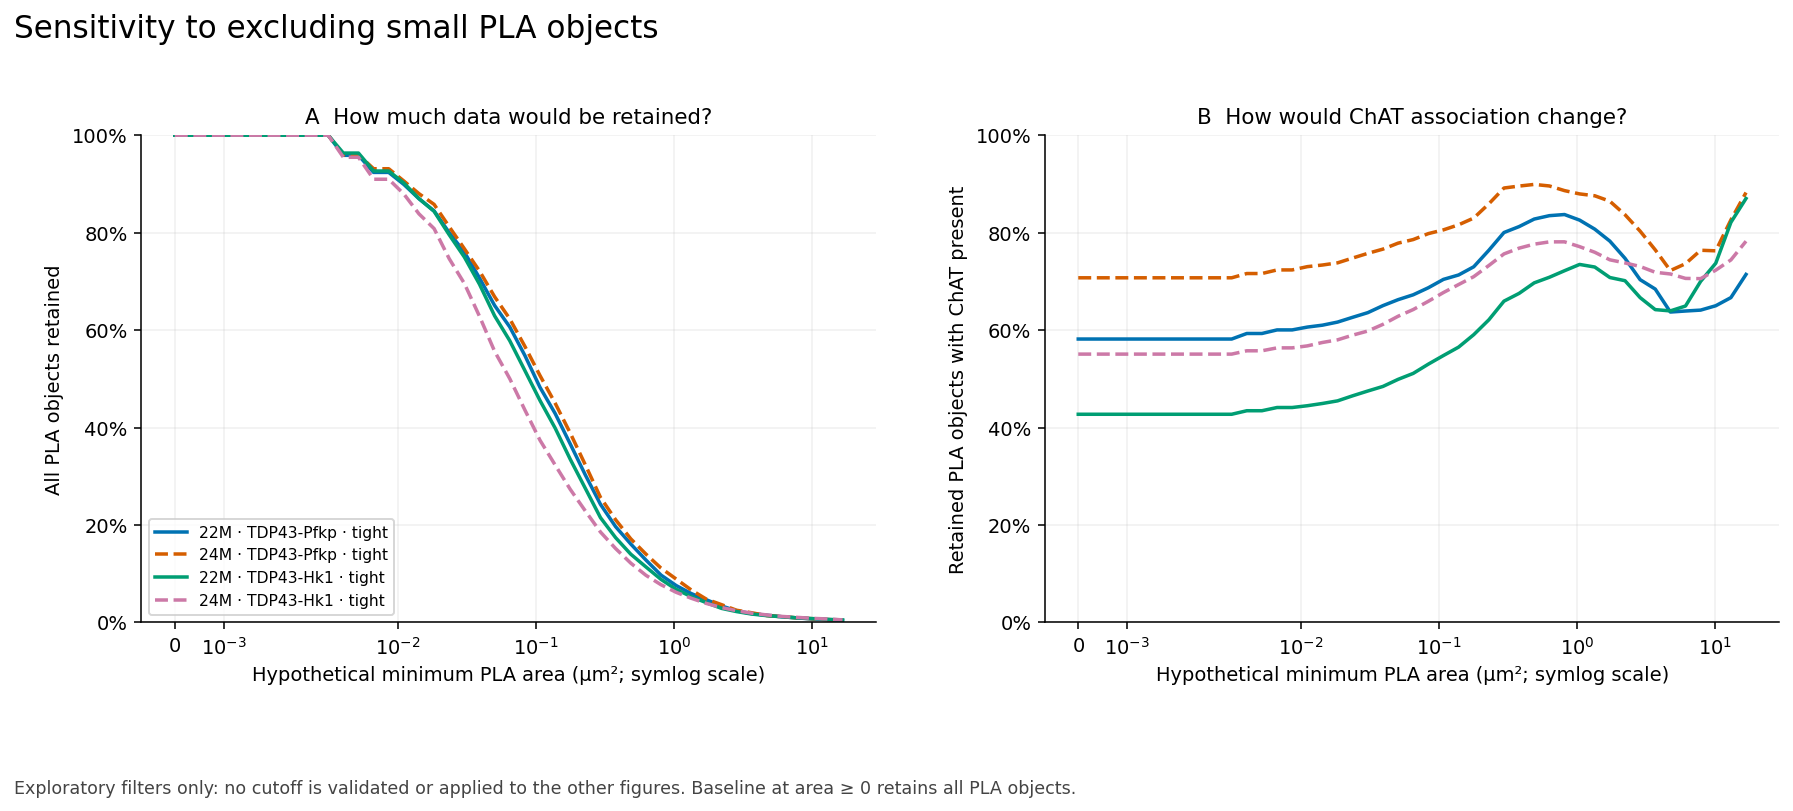

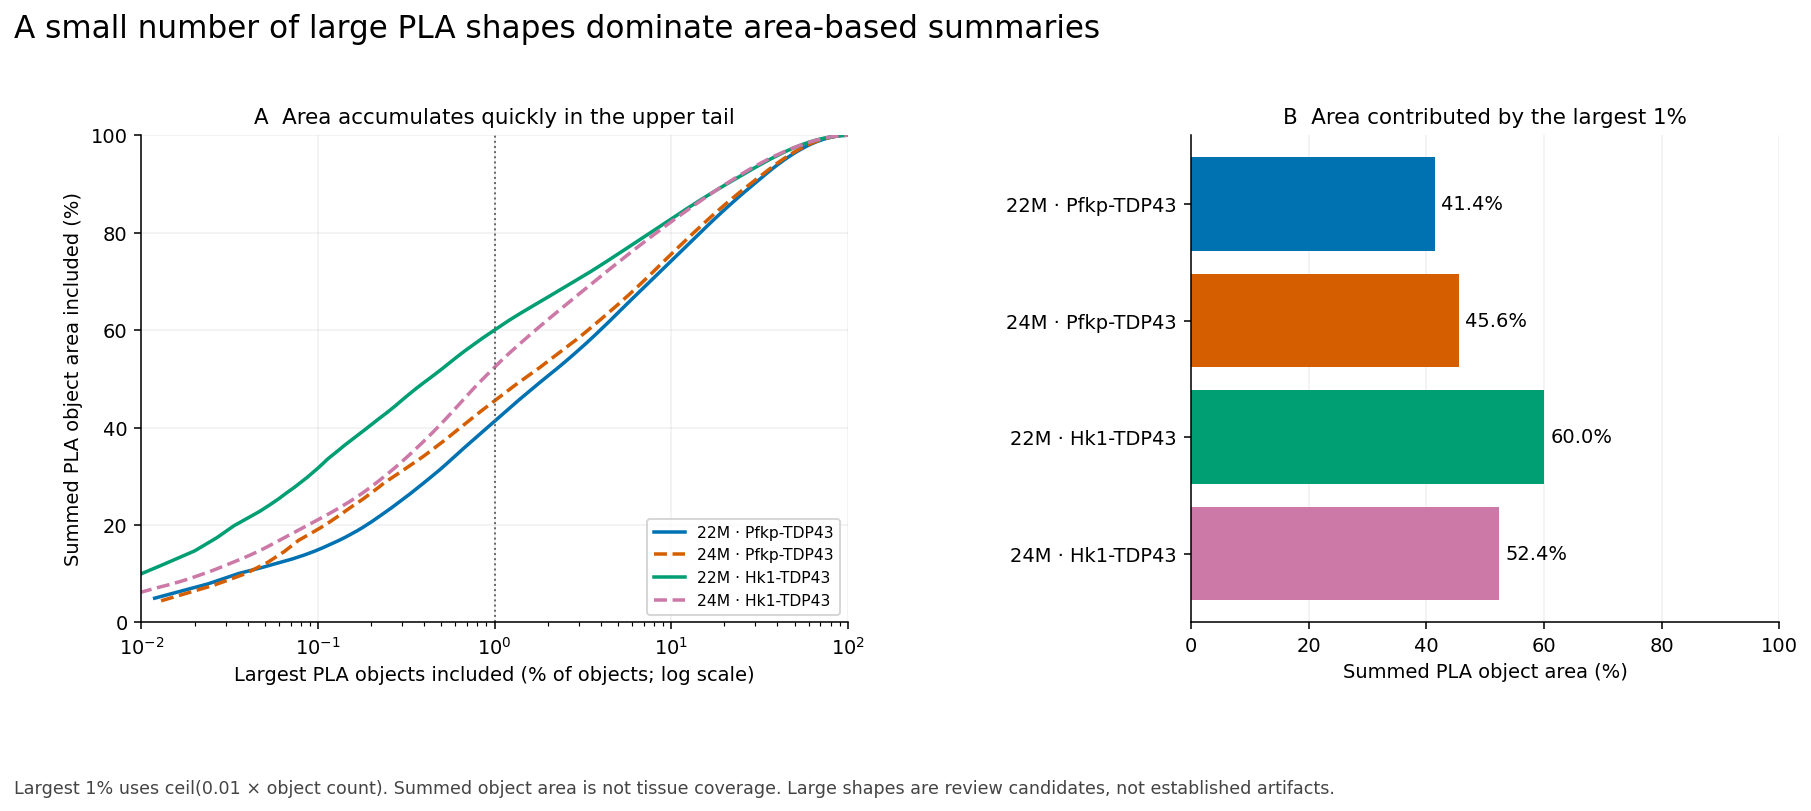

,job,region,object_type,object_id,area,overlap_pct,x,y
0,4999,22M_TDP43-Pfkp_tight,ChAT,130534,2079.45970,0.000000,14290.0,6960.0
1,4999,22M_TDP43-Pfkp_tight,ChAT,157381,2062.58500,0.075869,13330.0,9200.0
2,4999,22M_TDP43-Pfkp_tight,ChAT,128105,2003.37720,0.000000,14610.0,6800.0
3,4999,22M_TDP43-Pfkp_tight,ChAT,125378,1977.78430,0.000000,13650.0,6640.0
4,4999,22M_TDP43-Pfkp_tight,ChAT,145322,1976.85290,0.009360,13170.0,8080.0
...,...,...,...,...,...,...,...,...
75,5002,24M_TDP43-Hk1_tight,PLA,289539,159.60672,12.773356,42427.5,39439.5
76,5002,24M_TDP43-Hk1_tight,PLA,54601,151.25241,15.295142,40886.5,30145.0
77,5002,24M_TDP43-Hk1_tight,PLA,104635,146.27559,8.794271,41575.0,32227.5
78,5002,24M_TDP43-Hk1_tight,PLA,299933,139.39833,83.750650,43043.0,39743.5


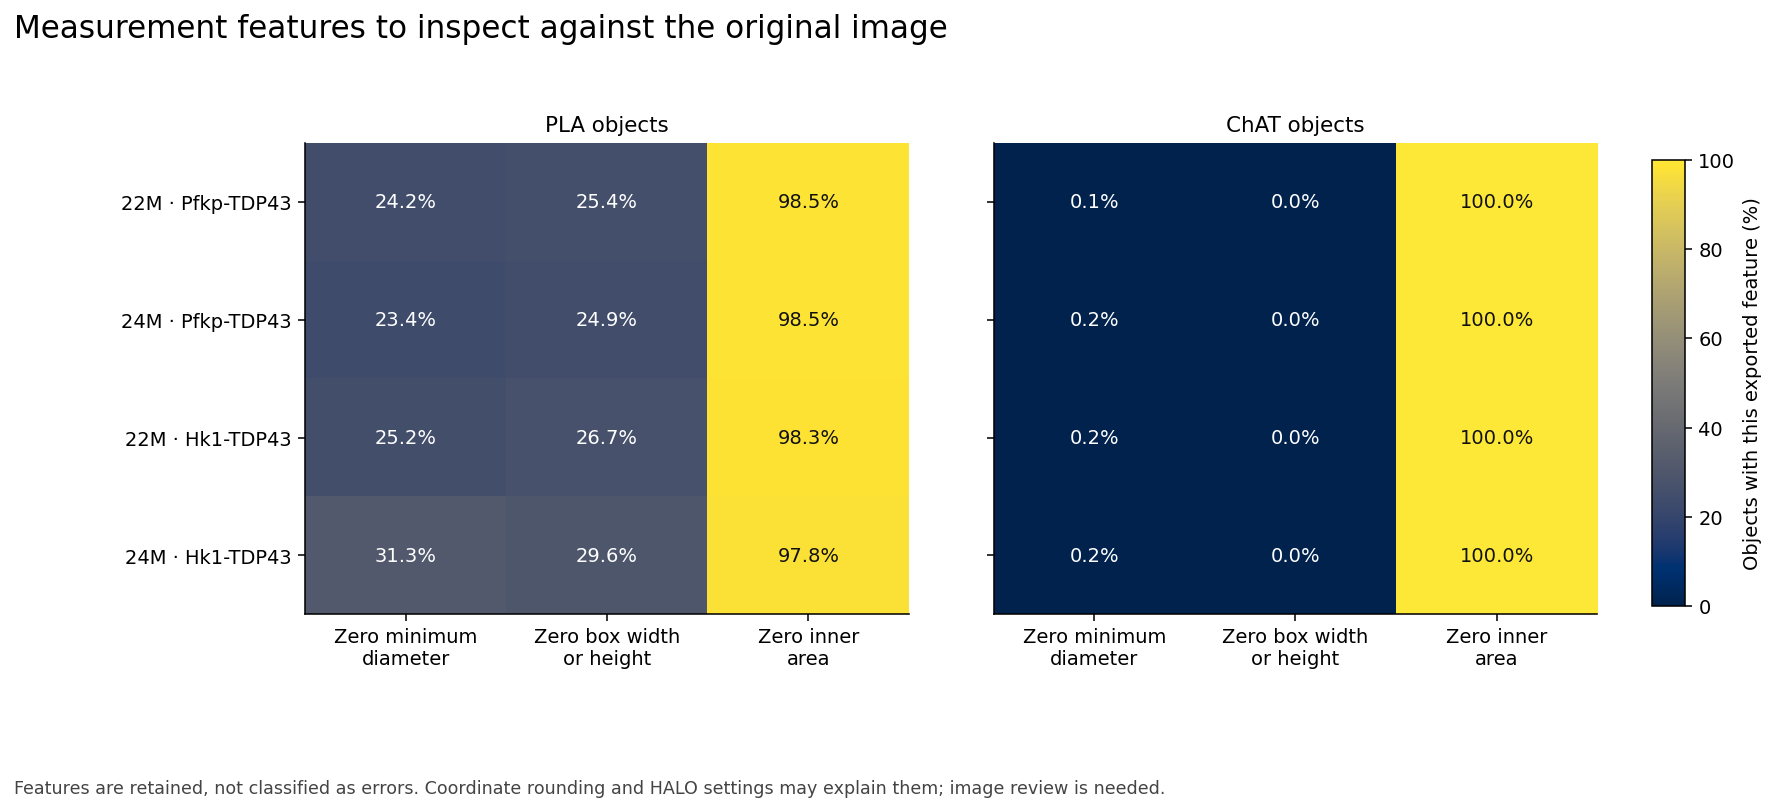

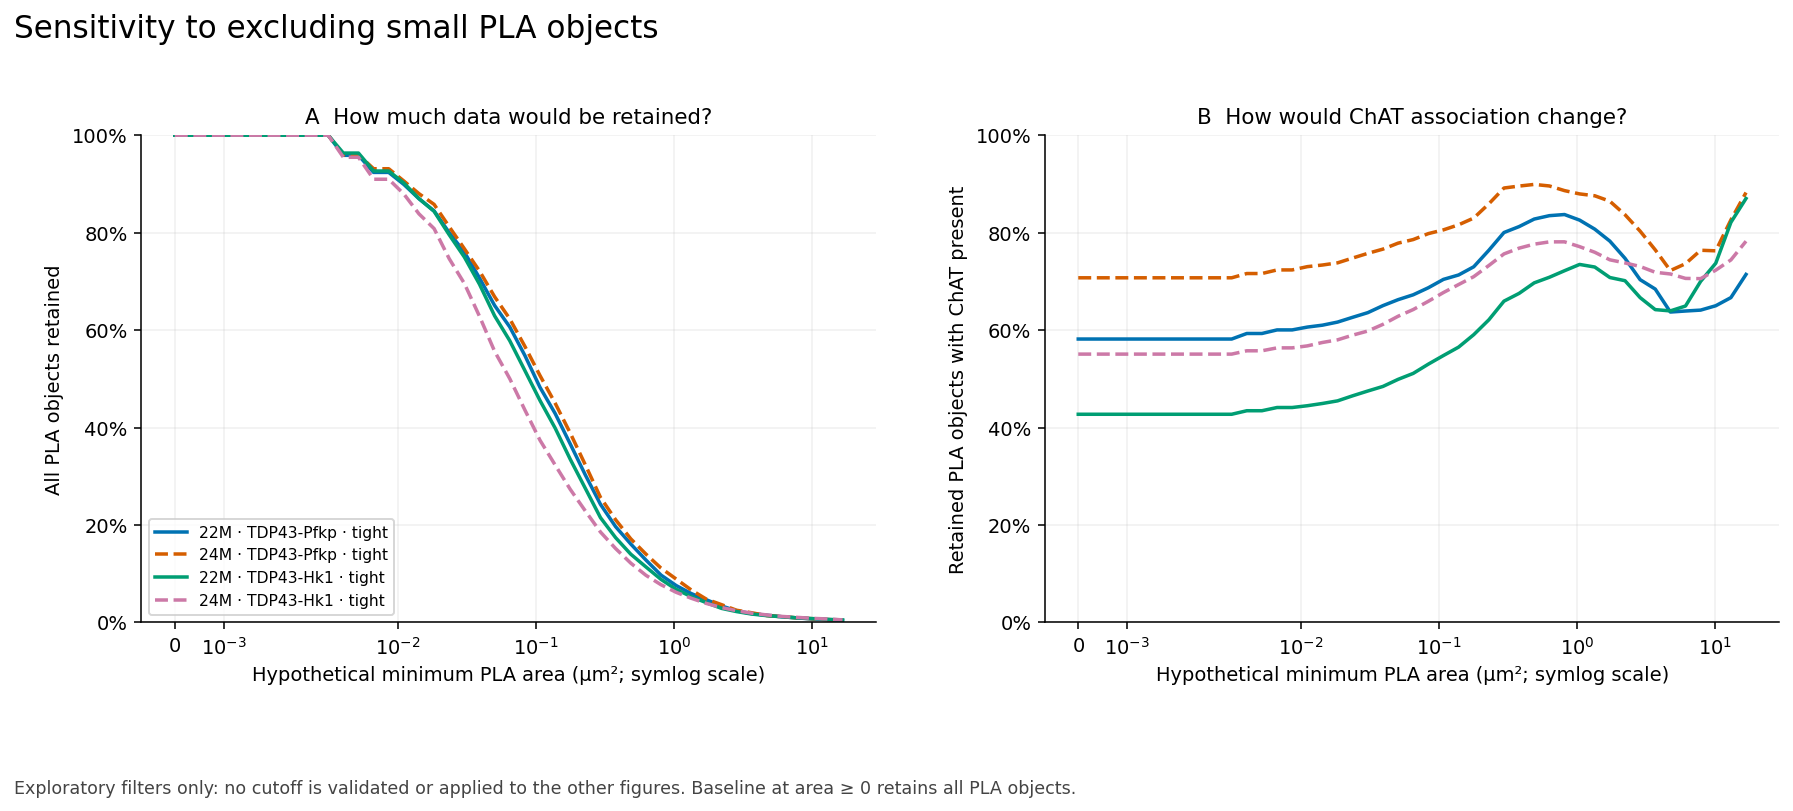

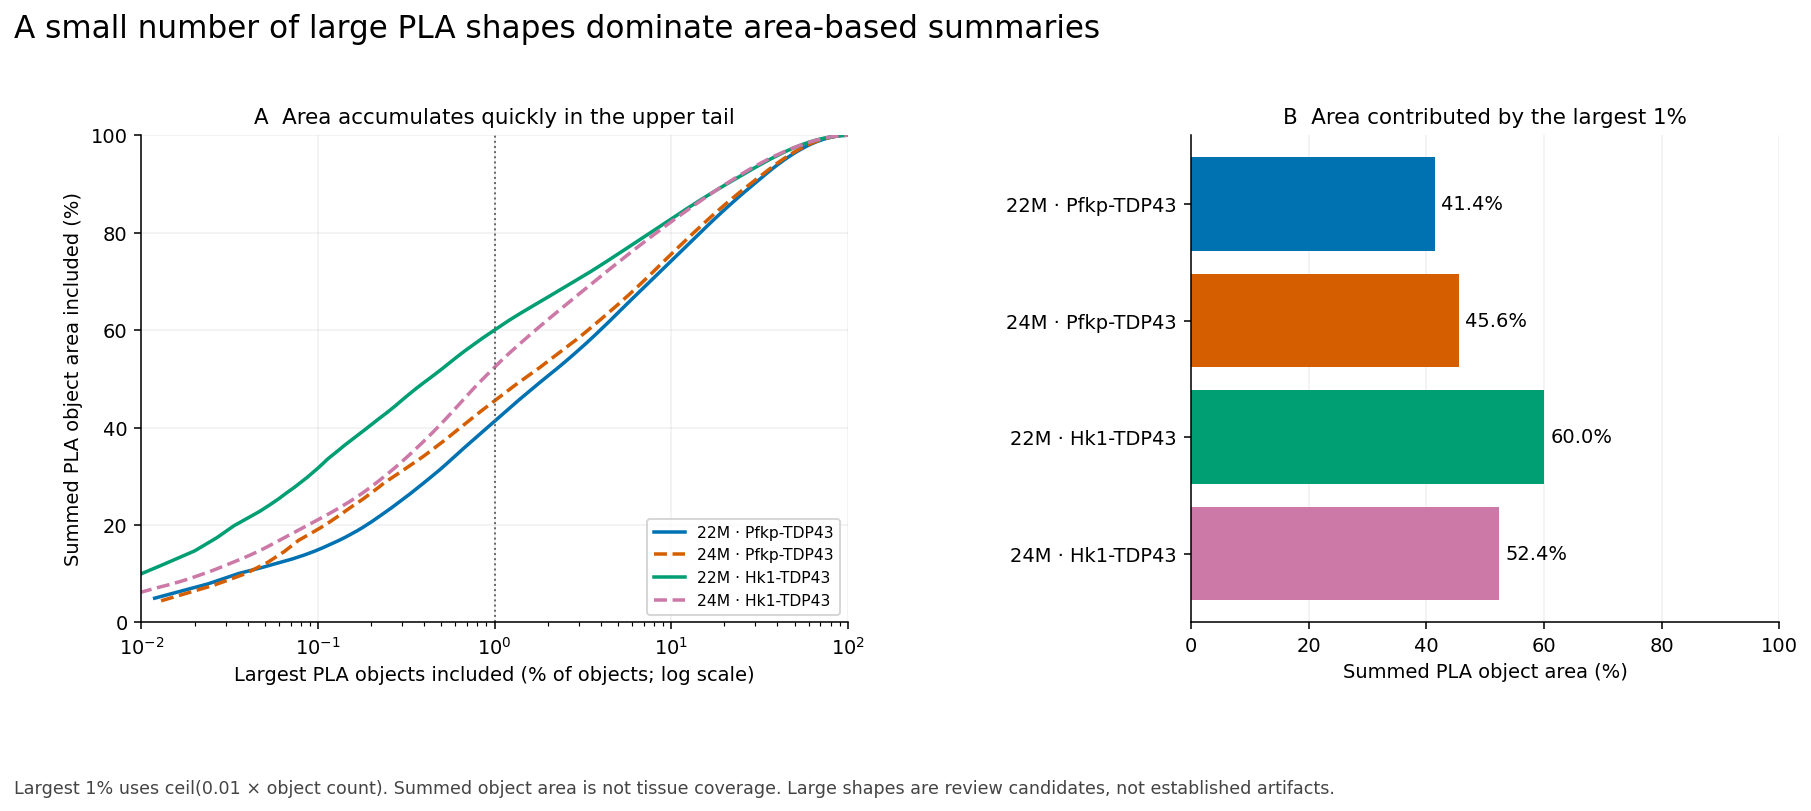

In [10]:
fig_qc, qc_table = measurement_qc(objects)
display(fig_qc)
save_figure(fig_qc, '12_measurement_quality', OUTPUT_ROOT / ROI_MODE)
fig_sensitivity, sensitivity_table = area_sensitivity(objects)
display(fig_sensitivity)
save_figure(fig_sensitivity, '13_area_sensitivity', OUTPUT_ROOT / ROI_MODE)
fig_concentration, concentration_tables = area_concentration(objects)
display(fig_concentration)
save_figure(fig_concentration, '14_area_concentration', OUTPUT_ROOT / ROI_MODE)
display(top_objects(objects, n=10)[['job', 'region', 'object_type', 'object_id', 'area', 'overlap_pct', 'x', 'y']])

## 8. Action guide for scientists

This guide separates **what the notebook shows** from **what should happen next**. Each recommendation is linked to the notebook output that provides the relevant evidence.

| Evidence observed in this notebook | Where to verify it | Immediate scientific action | Evidence needed to resolve it |
| --- | --- | --- | --- |
| Structural QC failure: missing values, invalid flags, overlap arithmetic mismatch, or duplicate IDs | **Section 1**, QC table and `quality_control.csv.gz` | Stop interpretation and inspect or correct the export | Corrected HALO export and saved analysis settings |
| Box-versus-outline counts differ, or paired difference maps show localized changes | **Section 2**, comparison table, `01_box_vs_outline_summary`, and `02_paired_spatial_*` | Review boundary and interior fields in the original image; do not call the difference a biological effect | ROI polygon or binary mask, image registration, analyzed area, and image review |
| A high local PLA-ChAT fraction appears in bins with weak raw PLA support or many hatched bins | **Section 4**, supported fraction map and raw-denominator panel; `pla_fraction_atlas.csv.gz` | Increase the support threshold or label the pattern exploratory; do not treat the color as statistical significance | More observations or a prespecified spatial model with a valid observation window |
| Area-weighted overlap differs materially from the associated-object fraction or mean overlap | **Section 3**, denominator comparison; **Section 6**, size-overlap and area-concentration figures | Inspect large-object morphology, segmentation, and the upper tail before explaining the result biologically | Original pixels, object masks, and validated size or segmentation criteria |
| Zero diameters or collapsed boxes occur at appreciable rates | **Section 1** QC table and **Section 7** measurement-quality figure; `measurement_qc.csv.gz` | Check coordinate rounding, export conventions, and HALO detection rules; do not automatically delete rows | HALO configuration and representative image fields |
| A regional difference persists after structural QC and both ROI modes | **Sections 2-4**, paired summary, overview, and spatial figures | Summarize at the animal or section level rather than at the object-row level | Sample-sheet hierarchy and independent biological replicates |
| A proposed claim concerns binding, neuronal identity, or glycolytic function | **Sections 3-9**, especially the denominator, overlap, and interpretation sections | Treat the current result as image-derived proximity or overlap evidence and add orthogonal validation | Original images, assay controls, biochemical measurements, or functional measurements |

The current paired comparison provides a concrete example. Relative PLA count changes from box to tissue-outline selection are:

- `22M_Pfkp-TDP43`: `-7.68%`
- `24M_Pfkp-TDP43`: `-3.33%`
- `22M_Hk1-TDP43`: `-1.95%`
- `24M_Hk1-TDP43`: `-6.10%`

PLA-object ChAT association changes by:

- `22M_Pfkp-TDP43`: `-0.88` percentage points
- `24M_Pfkp-TDP43`: `+1.83` percentage points
- `22M_Hk1-TDP43`: `+0.29` percentage points
- `24M_Hk1-TDP43`: `-0.38` percentage points

The largest area-weighted overlap change is `+5.43` percentage points for `24M_Pfkp-TDP43`. These values come from the paired comparison table and represent descriptive reanalysis differences, not biological effects.

Use measurement-specific results language:

> The tissue-outline reanalysis changed the number of exported PLA objects by X% and changed the PLA-object ChAT-association fraction by Y percentage points.

When reporting a value, name the ROI mode, denominator, spatial support threshold, bin width, and whether overlap is object-weighted or area-weighted. Do not describe these exports as proving direct binding, neuronal identity, glycolytic activity, or an age- or disease-related effect.

## 9. Current findings and scientific boundary

### Findings directly supported by the exports

- The dataset contains two paired analyses of the same four named regions: original box selections and tissue-outline selections. These are not eight independent biological samples.
- Tissue-outline selections contain fewer exported detections overall than the original box selections.
- PLA-object ChAT association changes by less than two percentage points in each paired region.
- The `24M_Pfkp-TDP43` pair shows a larger change in area-weighted overlap than in the associated-object fraction. This indicates that the selection change affects area-weighted summaries more strongly than simple object-count association in that region.
- Structural QC shows zero overlap-formula mismatches and zero marker-presence mismatches in the reviewed exports.
- Zero diameters and collapsed bounding boxes are present as measurement features. Their presence requires review but does not, by itself, prove that the corresponding objects are artifacts.
- Most outline PLA rows have an identical measurement signature in the box run. Unmatched rows cannot be called lost or new physical puncta because object IDs restart and no cross-run object correspondence or source-image pixels are available.
- Spatial heat maps identify coordinate regions for image review. They do not establish molecular enrichment, cell identity, tissue density, or a protein interaction.

### Scientific boundary

PLA is a proximity assay, while ChAT overlap is an image-segmentation relationship. Neither field alone proves direct protein binding, neuronal identity, mitochondrial localization, glycolytic activity, or an age- or disease-related effect.

Biological inference requires the original images and metadata, ROI geometry and analyzed area, HALO settings, sample-sheet hierarchy, assay controls, and independent biological replicates. Object rows should not be treated as independent animals or cells for inferential statistics.

The workflow is grounded in [Söderberg et al. on in situ PLA](https://pubmed.ncbi.nlm.nih.gov/17072308/), [Lagache et al. on object-based spatial statistics and ROI boundaries](https://www.nature.com/articles/s41467-018-03053-x), [Montero Llopis et al. on reproducible fluorescence microscopy reporting](https://www.nature.com/articles/s41592-021-01156-w), [Lord et al. on SuperPlots and biological replication](https://rupress.org/jcb/article/219/6/e202001064/151717/SuperPlots-Communicating-reproducibility-and), and [Crameri et al. on scientific color use](https://www.nature.com/articles/s41467-020-19160-7).

These sources support the analysis and reporting design. They do not establish a biological effect in this dataset.

In [11]:
tables = {
    'manifest': manifest,
    'summary': summary,
    'quality_control': qc,
    'overview': overview_table,
    'ecdf': ecdf_table,
    'overlap_composition': overlap_table,
    'size_overlap_bins': size_overlap_table,
    'area_sensitivity': sensitivity_table,
    'measurement_qc': qc_table,
    'area_concentration': concentration_tables['area_concentration'],
    'largest_one_percent': concentration_tables['largest_one_percent'],
    'comparison_summary': comparison_table,
    'signature_comparison': exact_signature_comparison(all_objects),
    **spatial_tables,
}
tables = {name: frame for name, frame in tables.items() if frame is not None and not frame.empty}
xlsx_path = export_tables(tables, OUTPUT_ROOT, sources=manifest)
metadata_path = write_run_metadata(OUTPUT_ROOT, {
    'roi_mode': ROI_MODE,
    'count_bin_width': COUNT_BIN_WIDTH,
    'fraction_bin_width': FRACTION_BIN_WIDTH,
    'minimum_raw_PLA_support': MIN_PLA_SUPPORT,
    'spatial_smoothing_sigma_bins': SPATIAL_SMOOTHING,
    'focus_job': FOCUS_JOB,
    'source_image_available': False,
}, manifest)
print(f"Figures: {OUTPUT_ROOT / ROI_MODE / 'figures'}")
print(f"Supporting tables: {xlsx_path}")
print(f"Run metadata: {metadata_path}")

Figures: /Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/scientific_notebook/outline/figures
Supporting tables: /Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/scientific_notebook/visualization_data.xlsx
Run metadata: /Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/scientific_notebook/run_metadata.json


## References and repository methods

See [Scientific methods](docs/research_methods.md) for the extended rationale and sources, and [Tissue outline review](docs/tissue_outline_review.md) for the paired eight-export audit. The generated `run_metadata.json` records input hashes, package versions, display parameters, and the absence of source image pixels and physical tissue-area metadata.